In [ ]:
%load_ext autoreload
%autoreload 2

import os
import numpy as np
from scipy.integrate import quad

from crc_scripts.io.gizmo import *
from crc_scripts import config
from crc_scripts.observations import dust_obs as obs
from crc_scripts.observations.obs_data import Observational_Data
import crc_scripts.utils.math_utils as math_utils
import crc_scripts.utils.snap_utils as snap_utils
import crc_scripts.utils.data_calc_utils as calc
import crc_scripts.utils.grain_size.grain_size_utils as grain_size_utils
from crc_scripts.utils.SKIRT.SKIRT_utils import create_SKIRT_particle_files
import crc_scripts.analytical_models.grain_size_evo as gse
from crc_scripts.figure import Figure,Projection
from crc_scripts.analysis.data_reduction import MultiSnapDataIO
import crc_scripts.utils.plot_utils as plt_set
import matplotlib.lines as mlines

import crc_scripts.analytical_models.grain_size_evo as gse_models

# First setup directory for all the plots
plot_dir = os.path.join(os.environ['BIGRED'],'dust_size_evo/')
os.makedirs(plot_dir, exist_ok=True)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Extinction Calculations

In [48]:
optical_properties = grain_size_utils.get_dust_optical_properties('silicates')

# Code Testing
Testing for small simulation runs restricted to a single dust process under specific ISM conditions to make sure the each routine works.

### Testing Accretion

In [10]:
# Name prefix for all saved images. Useful if you run this for multiple sims.
prefix=['size_evolution_dev']

main_dirc = '/N/u/cchoban/BigRed200/'
# Names of simulation directories
sim_names = np.array(['size_evolution_dev'])

# Snapshot to check
snap_nums = [0,2,4,10]

# Main sim directories and their snap and halo directories
# Default sim layout is assumed
# Note you need to specify the dtype or else you get numpy strings which annoying to deal with
main_dirs = np.array([main_dirc+name+'/' for name in sim_names], dtype=object)
snap_dirs = np.array([main_dirc+name+'/FIRE3_accretion_coulomb_output/' for name in sim_names], dtype=object)
hdirs = np.array([main_dirc+name+'/halo/ahf/output/' for name in sim_names], dtype=object)
# We only look at the main halos
halo_histories = np.array([main_dirc+name+'/halo/ahf/history/halo_main.dat' for name in sim_names], dtype=object)

In [11]:
snaps = [[]]*len(snap_dirs)

for i,snap_dir in enumerate(snap_dirs):
    print("Snap Dirc: ",snap_dir)
    name = sim_names[i]
    hdir = hdirs[i]

    for j, snap_num in enumerate(snap_nums):
        print("Snap Num:",snap_num)
        sp = load_snap(snap_dir, snap_num, cosmological=0)
        snaps[i] += [sp]


Snap Dirc:  /N/u/cchoban/BigRed200/size_evolution_dev/FIRE3_accretion_coulomb_output/
Snap Num: 0
This snap has grain size bins!
Snap Num: 2
This snap has grain size bins!
Snap Num: 4
This snap has grain size bins!
Snap Num: 10
This snap has grain size bins!


snapshot time 0.0
init depletion 0.5
init spec mass 30829146.0
Predicted dadt (um/Gyr): [1.13273231 1.13273231 1.13273231 1.13273231 1.13273231 1.13273231
 1.13273231 1.13273231 1.13273231 1.13273231 1.13273231 1.13273231
 1.13273231 1.13273231 1.13273231 1.13273231 1.13273231 1.13273231
 1.13273231 1.13273231 1.13273231 0.05702572 0.05702572 0.05702572
 0.05702572 0.05702572 0.05702572 0.05702572 0.05702572 0.05702572
 0.05702572 0.05702572 0.05702572 0.05702572 0.05702572 0.05702572
 0.05702572 0.05702572 0.05702572 0.05702572 0.05702572 0.05702572
 0.05702572 0.05702572 0.05702572 0.05702572 0.05702572 0.05702572
 0.05702572 0.05702572 0.05702572 0.05702572 0.05702572 0.05702572
 0.05702572 0.05702572 0.05702572 0.05702572 0.05702572 0.05702572
 0.05702572 0.05702572 0.05702572 0.05702572]
Min bin width used for subcyling 0.00011397385999480242
Total cycles needed 1 Subcycle timestep 0.0
Change in total grain number 1.0
Change in total grain mass 1.0102316410183854
Initial and final

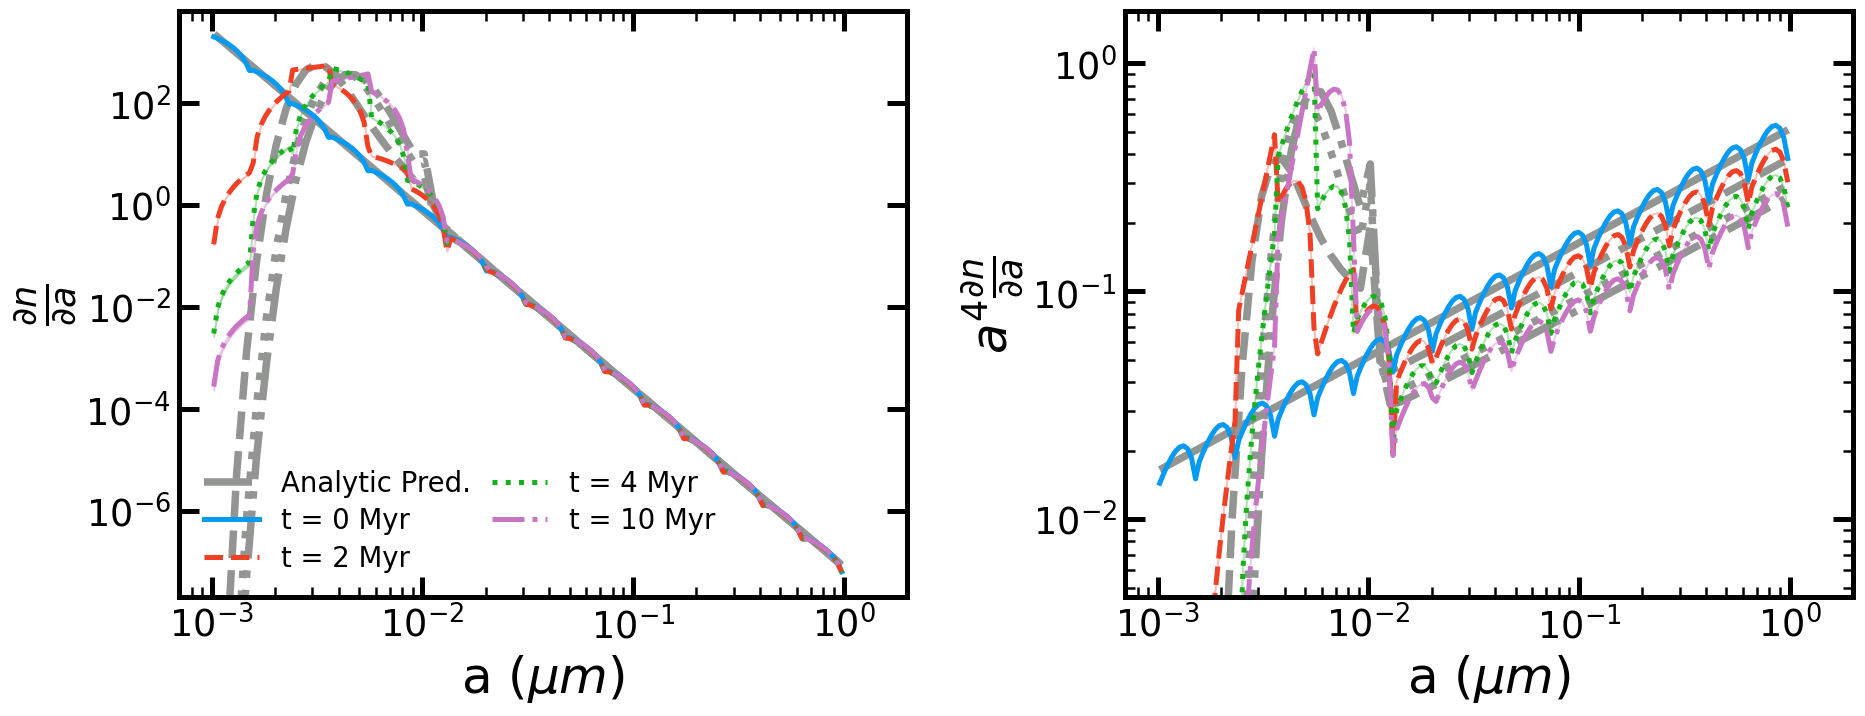

In [12]:
# Restrict to one species
species='silicates'
spec_ind = 1

# number of points per bin
# Any points_per_bin > 1 will follow the slopes in each bin so it can look odd
points_per_bin=10

for i,sim_snaps in enumerate(snaps):

    foutname = plot_dir+'accretion_FIRE3_test.pdf'
    num_snaps = len(sim_snaps)
    fig = Figure(2,ncols=2)
    colors = config.LINE_COLORS[:num_snaps]
    linestyles = config.LINE_STYLES[:num_snaps]
    linewidth = 2*config.BASE_LINEWIDTH

    init_depl = 0

    for j,sp in enumerate(sim_snaps):
        print('snapshot time',sp.time)
        G=sp.loadpart(0)
        if j == 0:
            init_depl=np.sum(G.get_property('dust_Z')[:,7])/np.sum(G.get_property('Z_all')[:,7])
            init_spec_mass = np.sum(G.get_property('M_dust'))
            init_N_total = np.sum(G.get_property('N_grain_total'))
            print('init depletion',init_depl)
            print('init spec mass',init_spec_mass)
        else:
            final_spec_mass = np.sum(G.get_property('M_spec')[:,spec_ind])
            final_N_total = np.sum(G.get_property('N_grain_total')[:,spec_ind])
            print('snapshot change in spec mass',final_spec_mass/init_spec_mass)
            print('snapshot change in total N grains',final_N_total/init_N_total)
        
        dt_Gyr = sp.time
        amin = sp.Grain_Size_Min
        amax = sp.Grain_Size_Max
        bin_num = sp.Flag_GrainSizeBins*4
        init_dnda = gse.MRN_dnda
        a_bins, final_dnda, final_dmda = gse.change_in_grain_distribution_from_acc_sput(dt_Gyr, amin=amin,amax=amax,bin_num=bin_num, init_dnda=init_dnda, depl_frac=init_depl, ISM_phase='CNM', species=species, subcycle_constraints='min_bin')

        mask = G.get_property('dust_spec')[:,spec_ind]>0
        mask = G.get_property('temperature')<1E4

        print('num start')
        dnda_bin_points, dnda_means, dnda_stds  =  gse.get_grain_size_dist(sp, species=species, mask=mask, mass=False,points_per_bin=points_per_bin)
        print('num done')
        dmda_bin_points, dmda_means, dmda_stds =  gse.get_grain_size_dist(sp, species=species, mask=mask, mass=True,points_per_bin=points_per_bin)

        if j == 0:
            fig.set_axis(0, 'grain_size', 'dn/da',y_lim=[np.power(10,-0.5)*np.min(dnda_means[dnda_means>0]),np.power(10,0.5)*np.max(dnda_means)])
            fig.set_axis(1, 'grain_size', 'dm/da',y_lim=[np.power(10,-0.5)*np.min(dmda_means),np.power(10,0.5)*np.max(dmda_means)])

        fig.plot_line_data(0,a_bins,final_dnda(a_bins), color='xkcd:grey',linestyle=linestyles[j], linewidth=1.5*config.BASE_LINEWIDTH ,label="Analytic Pred.", zorder=-2)
        fig.plot_line_data(0,dnda_bin_points,dnda_means, color=colors[j],linestyle=linestyles[j],label="t = %.0f Myr"%snap_nums[j])
        fig.plot_shaded_region(0,dnda_bin_points,dnda_stds[:,0],dnda_stds[:,1], color=colors[j])


        fig.plot_line_data(1,a_bins,final_dmda(a_bins)*a_bins, color='xkcd:grey',linestyle=linestyles[j], linewidth=1.5*config.BASE_LINEWIDTH ,label="Analytic Pred.", zorder=-2)
        fig.plot_line_data(1,dmda_bin_points,dmda_means, color=colors[j],linestyle=linestyles[j])
        fig.plot_shaded_region(1,dmda_bin_points,dmda_stds[:,0],dmda_stds[:,1], color=colors[j])

    fig.set_all_legends(max_cols=2,rescale_font=0.75)
    fig.save(foutname)

### Testing Sputtering

In [ ]:
# Name prefix for all saved images. Useful if you run this for multiple sims.
prefix=['size_evolution_dev']

main_dirc = '/N/u/cchoban/BigRed200/'
# Names of simulation directories
sim_names = np.array(['size_evolution_dev'])

# Snapshot to check
snap_nums = [0,2,4,6]

# Main sim directories and their snap and halo directories
# Default sim layout is assumed
# Note you need to specify the dtype or else you get numpy strings which annoying to deal with
main_dirs = np.array([main_dirc+name+'/' for name in sim_names], dtype=object)
snap_dirs = np.array([main_dirc+name+'/output/' for name in sim_names], dtype=object)
hdirs = np.array([main_dirc+name+'/halo/ahf/output/' for name in sim_names], dtype=object)
# We only look at the main halos
halo_histories = np.array([main_dirc+name+'/halo/ahf/history/halo_main.dat' for name in sim_names], dtype=object)

In [ ]:
snaps = [[]]*len(snap_dirs)

for i,snap_dir in enumerate(snap_dirs):
    print("Snap Dirc: ",snap_dir)
    name = sim_names[i]
    hdir = hdirs[i]

    for j, snap_num in enumerate(snap_nums):
        print("Snap Num:",snap_num)
        sp = load_snap(snap_dir, snap_num, cosmological=0)
        snaps[i] += [sp]


Snap Dirc:  /N/u/cchoban/BigRed200/size_evolution_dev/output/
Snap Num: 0
This snap has grain size bins!
Snap Num: 2
This snap has grain size bins!
Snap Num: 4
This snap has grain size bins!
Snap Num: 6
This snap has grain size bins!


snapshot time 0.0
init depletion 0.5
init spec mass 32825534.0
Predicted dadt (um/Gyr): -39.99458668299783
Min bin width used for subcyling 0.00024093776075171964
Total cycles needed 0.0 Subcycle timestep nan
Change in total grain number 1.0
Change in total grain mass 1.0
Initial and final depletion fraction 0.5 0.5


/geode2/home/u020/cchoban/BigRed200/codes/crc_scripts/src/crc_scripts/analytical_models/grain_size_evo.py:286: RuntimeWarning: invalid value encountered in scalar divide
  elif subcycle_constraints == 'size':


change in spec mass 1.0
change in total N grains 1.0
snapshot time 0.002
Predicted dadt (um/Gyr): -39.99458668299783
Min bin width used for subcyling 0.00024093776075171964
Total cycles needed 1107.0 Subcycle timestep 1.8066847335140018e-06
Change in total grain number 2.7027122177048783e-05
Change in total grain mass 0.43616810371183407
Initial and final depletion fraction 0.5 0.21808405185591662
change in spec mass 0.41179362
change in total N grains 4.715252022063718e-05
snapshot time 0.004
Predicted dadt (um/Gyr): -39.99458668299783
Min bin width used for subcyling 0.00024093776075171964
Total cycles needed 2214.0 Subcycle timestep 1.8066847335140018e-06
Change in total grain number 4.835869491529472e-06
Change in total grain mass 0.2724122204297616
Initial and final depletion fraction 0.5 0.1362061102148803
change in spec mass 0.25283977
change in total N grains 8.455059701792639e-06
snapshot time 0.006
Predicted dadt (um/Gyr): -39.99458668299783
Min bin width used for subcyling 0

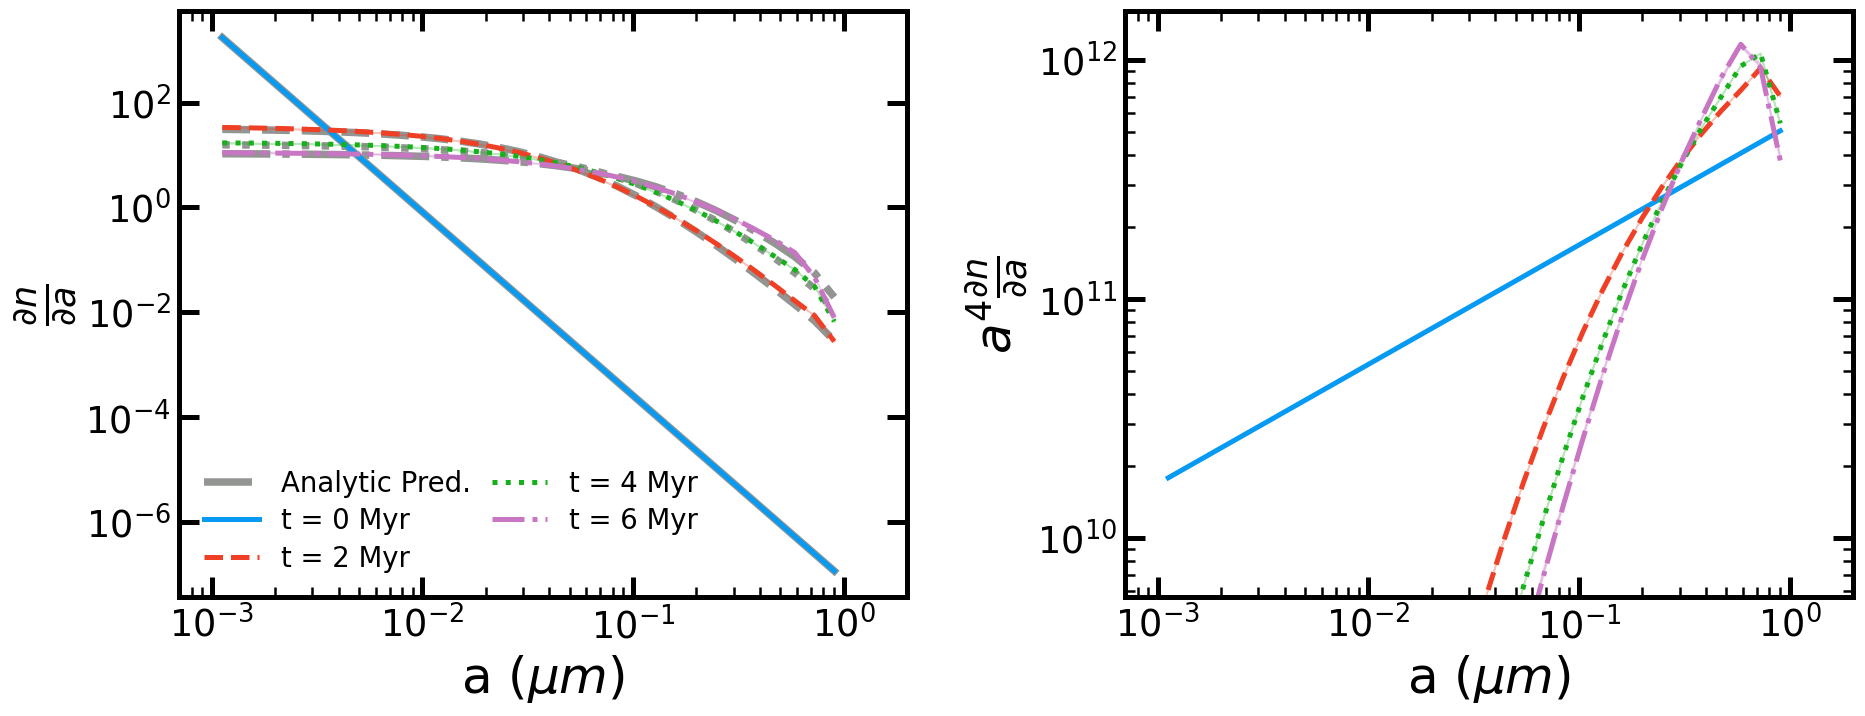

In [ ]:


for i,sim_snaps in enumerate(snaps):

    foutname = plot_dir+'sputtering_FIRE3_test.pdf'
    num_snaps = len(sim_snaps)
    fig = Figure(2,ncols=2)
    colors = config.LINE_COLORS[:num_snaps]
    linestyles = config.LINE_STYLES[:num_snaps]
    linewidth = 2*config.BASE_LINEWIDTH

    init_depl = 0

    for j,sp in enumerate(sim_snaps):
        print('snapshot time',sp.time)
        G=sp.loadpart(0)
        if j == 0:
            init_depl=np.sum(G.get_property('dust_Z')[:,7])/np.sum(G.get_property('Z_all')[:,7])
            init_spec_mass = np.sum(G.get_property('M_dust'))
            init_N_total = np.sum(G.get_property('N_grain_total'))
            print('init depletion',init_depl)
            print('init spec mass',init_spec_mass)
        
        dt_Gyr = sp.time
        amin = sp.Grain_Size_Min*config.cm_to_um
        amax = sp.Grain_Size_Max*config.cm_to_um
        bin_num = sp.Flag_GrainSizeBins
        init_dnda = gse.MRN_dnda
        a_bins, final_dnda, final_dmda = gse.change_in_grain_distribution_from_acc_sput(dt_Gyr, amin=amin,amax=amax,bin_num=bin_num, init_dnda=init_dnda, depl_frac=init_depl, ISM_phase='HIM', species='silicates', subcycle_constraints='min_bin')

        spec_ind = 0
        mask = G.get_property('dust_spec')[:,spec_ind]>0
        #mask = calc.get_particle_mask(0, sp, mask_criteria='cold')

        dnda_bin_points, dnda_means, dnda_stds  =  gse.get_grain_size_dist(sp, spec_ind, mask=mask, mass=False,points_per_bin=1)
        dmda_bin_points, dmda_means, dmda_stds =  gse.get_grain_size_dist(sp, spec_ind, mask=mask, mass=True,points_per_bin=1)

        print('snapshot change in spec mass',np.sum(G.get_property('M_dust'))/init_spec_mass)
        print('snapshot change in total N grains',np.sum(G.get_property('N_grain_total'))/init_N_total)

        if j == 0:
            fig.set_axis(0, 'grain_size', 'dn/da',y_lim=[np.power(10,-0.5)*np.min(dnda_means[dnda_means>0]),np.power(10,0.5)*np.max(dnda_means)])
            fig.set_axis(1, 'grain_size', 'dm/da',y_lim=[np.power(10,-0.5)*np.min(dmda_means),np.power(10,0.5)*np.max(dmda_means)])

        fig.plot_line_data(0,dnda_bin_points,final_dnda(dnda_bin_points), color='xkcd:grey',linestyle=linestyles[j], linewidth=1.5*config.BASE_LINEWIDTH ,label="Analytic Pred.", zorder=-2)
        fig.plot_line_data(0,dnda_bin_points,dnda_means, color=colors[j],linestyle=linestyles[j],label="t = %.0f Myr"%snap_nums[j])
        fig.plot_shaded_region(0,dnda_bin_points,dnda_stds[:,0],dnda_stds[:,1], color=colors[j])

        fig.plot_line_data(0,dmda_bin_points,final_dmda(dmda_bin_points), color='xkcd:grey',linestyle=linestyles[j], linewidth=1.5*config.BASE_LINEWIDTH ,label="Analytic Pred.", zorder=-2)
        fig.plot_line_data(1,dmda_bin_points,dmda_means, color=colors[j],linestyle=linestyles[j])
        fig.plot_shaded_region(1,dmda_bin_points,dmda_stds[:,0],dmda_stds[:,1], color=colors[j])

    fig.set_all_legends(max_cols=2,rescale_font=0.75)
    fig.save(foutname)

### Testing Coagulation

In [14]:
# Name prefix for all saved images. Useful if you run this for multiple sims.
prefix=['size_evolution_dev']

main_dirc = '/N/u/cchoban/BigRed200/'
# Names of simulation directories
sim_names = np.array(['size_evolution_dev'])

# Snapshot to check
snap_nums = [0,7]

# Main sim directories and their snap and halo directories
# Default sim layout is assumed
# Note you need to specify the dtype or else you get numpy strings which annoying to deal with
main_dirs = np.array([main_dirc+name+'/' for name in sim_names], dtype=object)
snap_dirs = np.array([main_dirc+name+'/FIRE3_coagulation_output/' for name in sim_names], dtype=object)
hdirs = np.array([main_dirc+name+'/halo/ahf/output/' for name in sim_names], dtype=object)
# We only look at the main halos
halo_histories = np.array([main_dirc+name+'/halo/ahf/history/halo_main.dat' for name in sim_names], dtype=object)

In [15]:
snaps = [[]]*len(snap_dirs)

for i,snap_dir in enumerate(snap_dirs):
    print("Snap Dirc: ",snap_dir)
    name = sim_names[i]
    hdir = hdirs[i]

    for j, snap_num in enumerate(snap_nums):
        print("Snap Num:",snap_num)
        sp = load_snap(snap_dir, snap_num, cosmological=0)
        snaps[i] += [sp]


Snap Dirc:  /N/u/cchoban/BigRed200/size_evolution_dev/output/
Snap Num: 0
This snap has grain size bins!
Snap Num: 7
This snap has grain size bins!


snapshot time 0.0
init depletion 0.5
init spec mass 16412767.0
Final changes
Mass fraction moved in given timestep 1.0
Number fraction changed in given timestep 0.9713571098881096
snapshot time 0.006999999999999999
snapshot change in spec mass 0.9999702
snapshot change in total N grains 0.0009206737802017942
Need to subcycle for 10 cycle
	 Number fraction changed 0.9708488302734011
	 Mass fraction change 0.11532538944906236
	 Change if we did not subcycle
	 Mass fraction change in given timestep 3.0132690571113323
	 Number fraction change in given timestep 0.03447935353021756
Final changes
Mass fraction moved in given timestep 1.189946902386847
Number fraction changed in given timestep 0.0010845716136611717


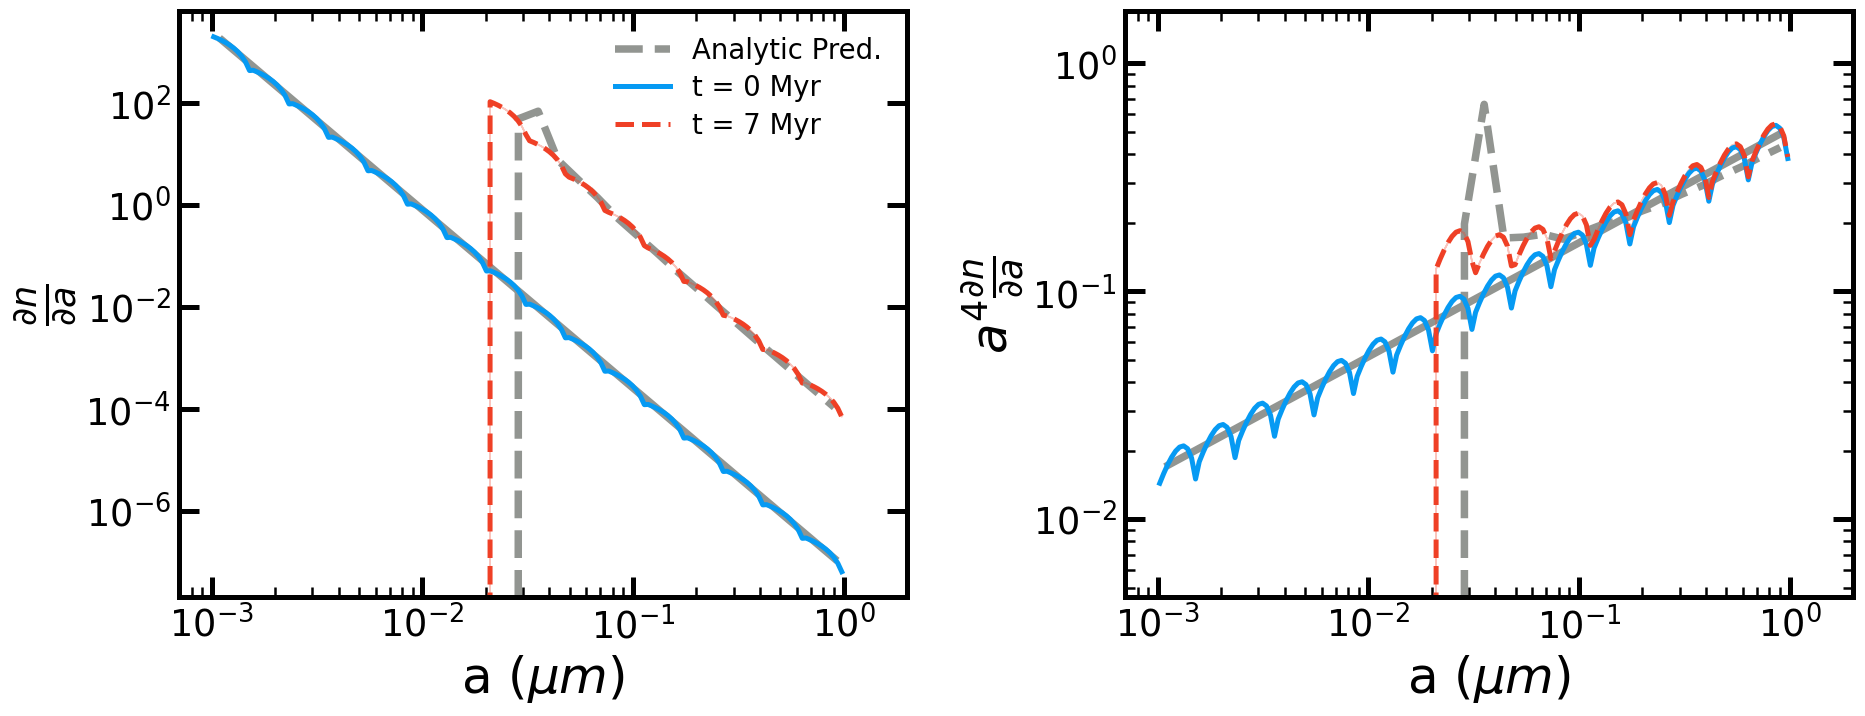

In [21]:


for i,sim_snaps in enumerate(snaps):

    foutname = plot_dir+'coagulation_FIRE3_test.pdf'
    num_snaps = len(sim_snaps)
    fig = Figure(2,ncols=2)
    colors = config.LINE_COLORS[:num_snaps]
    linestyles = config.LINE_STYLES[:num_snaps]
    linewidth = 2*config.BASE_LINEWIDTH

    init_depl = 0

    # Restrict to one species
    species='carbonaceous'
    spec_ind = 1

    # number of points per bin
    # Any points_per_bin > 1 will follow the slopes in each bin so it can look odd
    points_per_bin=10

    for j,sp in enumerate(sim_snaps):
        print('snapshot time',sp.time)
        G=sp.loadpart(0)
        if j == 0:
            init_depl=np.sum(G.get_property('dust_Z')[:,7])/np.sum(G.get_property('Z_all')[:,7])
            init_spec_mass = np.sum(G.get_property('M_spec')[:,spec_ind])
            init_N_total = np.sum(G.get_property('N_grain_total')[:,spec_ind])
            print('init depletion',init_depl)
            print('init spec mass',init_spec_mass)
        else:
            final_spec_mass = np.sum(G.get_property('M_spec')[:,spec_ind])
            final_N_total = np.sum(G.get_property('N_grain_total')[:,spec_ind])
            print('snapshot change in spec mass',final_spec_mass/init_spec_mass)
            print('snapshot change in total N grains',final_N_total/init_N_total)

        
        

        dt_Gyr = sp.time
        amin = sp.Grain_Size_Min*config.cm_to_um
        amax = sp.Grain_Size_Max*config.cm_to_um
        bin_num = sp.Flag_GrainSizeBins*2
        init_dnda = gse.MRN_dnda
        a_bins, final_dnda, final_dmda = gse.change_in_grain_distribution_from_shat_coag(dt_Gyr, amin=amin,amax=amax,bin_num=bin_num, init_dnda=init_dnda, depl_frac=init_depl, ISM_phase='MC', species=species, subcycle_constraints='both')

        mask = G.get_property('dust_spec')[:,spec_ind]>0
        #mask = calc.get_particle_mask(0, sp, mask_criteria='cold')

        dnda_bin_points, dnda_means, dnda_stds  =  gse.get_grain_size_dist(sp, species=species, mask=mask, mass=False,points_per_bin=points_per_bin)
        dmda_bin_points, dmda_means, dmda_stds =  gse.get_grain_size_dist(sp, species=species, mask=mask, mass=True,points_per_bin=points_per_bin)

        if j == 0:
            fig.set_axis(0, 'grain_size', 'dn/da',y_lim=[np.power(10,-0.5)*np.min(dnda_means[dnda_means>0]),np.power(10,0.5)*np.max(dnda_means)])
            fig.set_axis(1, 'grain_size', 'dm/da',y_lim=[np.power(10,-0.5)*np.min(dmda_means),np.power(10,0.5)*np.max(dmda_means)])

        fig.plot_line_data(0,a_bins,final_dnda(a_bins), color='xkcd:grey',linestyle=linestyles[j], linewidth=1.5*config.BASE_LINEWIDTH ,label="Analytic Pred.", zorder=-2)
        fig.plot_line_data(0,dnda_bin_points,dnda_means, color=colors[j],linestyle=linestyles[j],label="t = %.0f Myr"%snap_nums[j])
        fig.plot_shaded_region(0,dnda_bin_points,dnda_stds[:,0],dnda_stds[:,1], color=colors[j])


        fig.plot_line_data(1,a_bins,final_dmda(a_bins)*a_bins, color='xkcd:grey',linestyle=linestyles[j], linewidth=1.5*config.BASE_LINEWIDTH ,label="Analytic Pred.", zorder=-2)
        fig.plot_line_data(1,dmda_bin_points,dmda_means, color=colors[j],linestyle=linestyles[j])
        fig.plot_shaded_region(1,dmda_bin_points,dmda_stds[:,0],dmda_stds[:,1], color=colors[j])

    fig.set_all_legends(max_cols=2,rescale_font=0.75)
    fig.save(foutname)

### Testing Shattering

In [22]:
# Name prefix for all saved images. Useful if you run this for multiple sims.
prefix=['size_evolution_dev']

main_dirc = '/N/u/cchoban/BigRed200/'
# Names of simulation directories
sim_names = np.array(['size_evolution_dev'])

# Snapshot to check
snap_nums = [0,5,10]

# Main sim directories and their snap and halo directories
# Default sim layout is assumed
# Note you need to specify the dtype or else you get numpy strings which annoying to deal with
main_dirs = np.array([main_dirc+name+'/' for name in sim_names], dtype=object)
snap_dirs = np.array([main_dirc+name+'/FIRE3_shattering_output/' for name in sim_names], dtype=object)
hdirs = np.array([main_dirc+name+'/halo/ahf/output/' for name in sim_names], dtype=object)
# We only look at the main halos
halo_histories = np.array([main_dirc+name+'/halo/ahf/history/halo_main.dat' for name in sim_names], dtype=object)

In [23]:
snaps = [[]]*len(snap_dirs)

for i,snap_dir in enumerate(snap_dirs):
    print("Snap Dirc: ",snap_dir)
    name = sim_names[i]
    hdir = hdirs[i]

    for j, snap_num in enumerate(snap_nums):
        print("Snap Num:",snap_num)
        sp = load_snap(snap_dir, snap_num, cosmological=0)
        snaps[i] += [sp]


Snap Dirc:  /N/u/cchoban/BigRed200/size_evolution_dev/FIRE3_shattering_output/
Snap Num: 0
This snap has grain size bins!
Snap Num: 5
This snap has grain size bins!
Snap Num: 10
This snap has grain size bins!


snapshot time 0.0
init depletion 0.5
init spec mass 16412767.0
Final changes
Mass fraction moved in given timestep 1.0
Number fraction changed in given timestep 0.9713571098881096
snapshot time 0.005
snapshot change in spec mass 0.9999977
snapshot change in total N grains 2.510028721400459
Need to subcycle for 2 cycle
	 Number fraction changed 4.18065487588334e-07
	 Mass fraction change 0.19655775931079789
	 Change if we did not subcycle
	 Mass fraction change in given timestep 0.98244843677465
	 Number fraction change in given timestep 2.062238158699857
Final changes
Mass fraction moved in given timestep 0.9794875369631412
Number fraction changed in given timestep 2.1566050922760325
snapshot time 0.01
snapshot change in spec mass 0.99963224
snapshot change in total N grains 4.989339435860337
Need to subcycle for 4 cycle
	 Number fraction changed 8.309220399539956e-07
	 Mass fraction change 0.36807266761697194
	 Change if we did not subcycle
	 Mass fraction change in given timestep 0.9

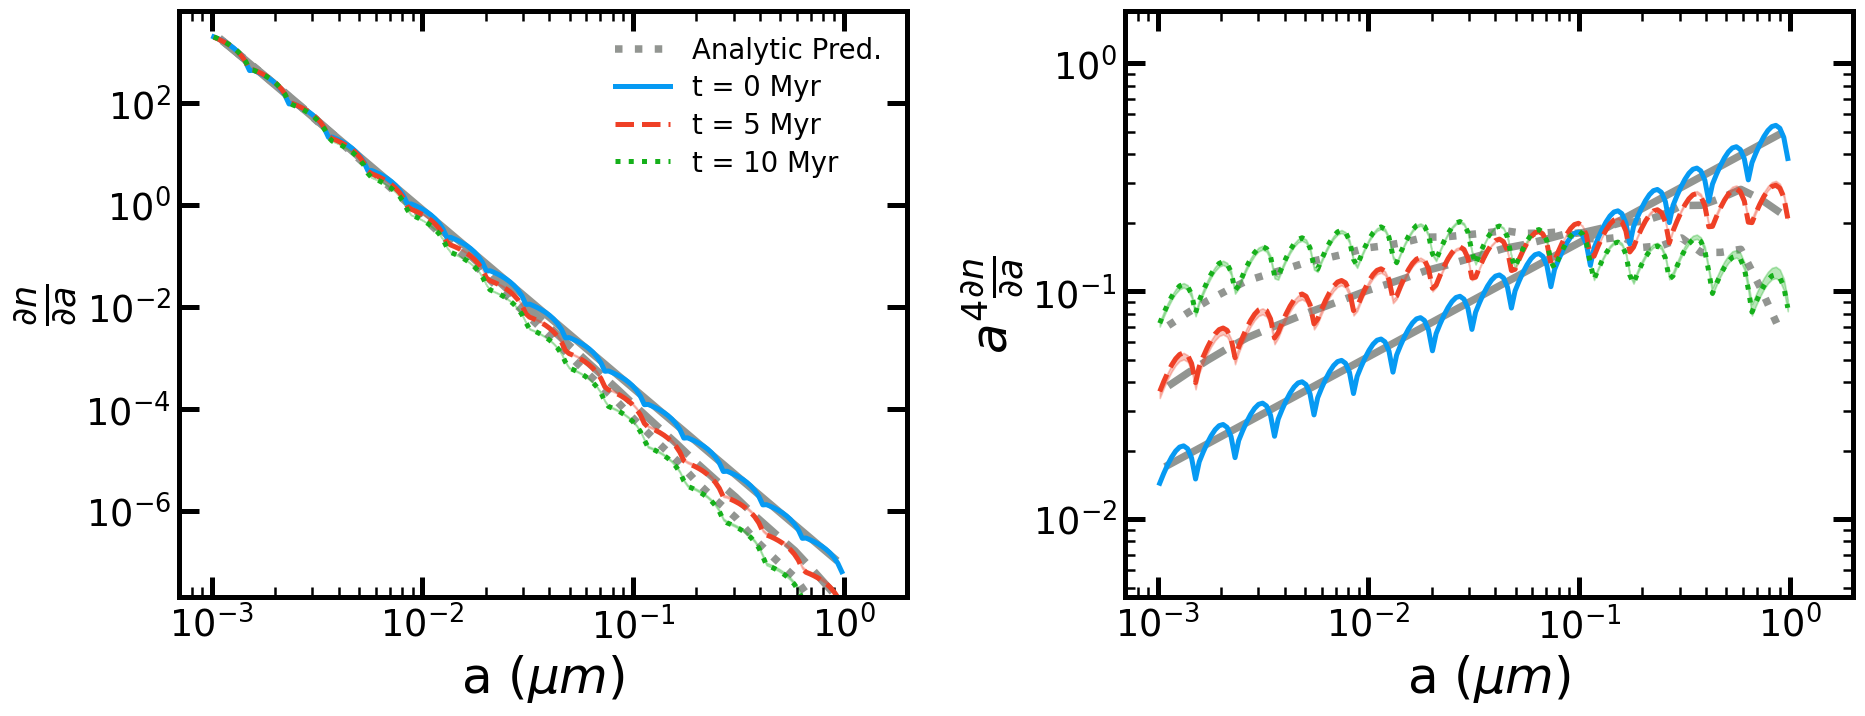

In [27]:


for i,sim_snaps in enumerate(snaps):

    foutname = plot_dir+'shattering_coagulation_FIRE3_test.pdf'
    num_snaps = len(sim_snaps)
    fig = Figure(2,ncols=2)
    colors = config.LINE_COLORS[:num_snaps]
    linestyles = config.LINE_STYLES[:num_snaps]
    linewidth = 2*config.BASE_LINEWIDTH

    init_depl = 0

    # Restrict to one species
    species='carbonaceous'
    spec_ind = 1

    # number of points per bin
    # Any points_per_bin > 1 will follow the slopes in each bin so it can look odd
    points_per_bin=10

    for j,sp in enumerate(sim_snaps):
        print('snapshot time',sp.time)
        G=sp.loadpart(0)
        if j == 0:
            init_depl=np.sum(G.get_property('dust_Z')[:,7])/np.sum(G.get_property('Z_all')[:,7])
            init_spec_mass = np.sum(G.get_property('M_spec')[:,spec_ind])
            init_N_total = np.sum(G.get_property('N_grain_total')[:,spec_ind])
            print('init depletion',init_depl)
            print('init spec mass',init_spec_mass)
        else:
            final_spec_mass = np.sum(G.get_property('M_spec')[:,spec_ind])
            final_N_total = np.sum(G.get_property('N_grain_total')[:,spec_ind])
            print('snapshot change in spec mass',final_spec_mass/init_spec_mass)
            print('snapshot change in total N grains',final_N_total/init_N_total)

        
        

        dt_Gyr = sp.time
        amin = sp.Grain_Size_Min*config.cm_to_um
        amax = sp.Grain_Size_Max*config.cm_to_um
        bin_num = sp.Flag_GrainSizeBins*2
        init_dnda = gse.MRN_dnda
        a_bins, final_dnda, final_dmda = gse.change_in_grain_distribution_from_shat_coag(dt_Gyr, amin=amin,amax=amax,bin_num=bin_num, init_dnda=init_dnda, depl_frac=init_depl, ISM_phase='WIM', species=species, subcycle_constraints='both')

        mask = G.get_property('dust_spec')[:,spec_ind]>0
        #mask = calc.get_particle_mask(0, sp, mask_criteria='cold')

        dnda_bin_points, dnda_means, dnda_stds  =  gse.get_grain_size_dist(sp, species=species, mask=mask, mass=False,points_per_bin=points_per_bin)
        dmda_bin_points, dmda_means, dmda_stds =  gse.get_grain_size_dist(sp, species=species, mask=mask, mass=True,points_per_bin=points_per_bin)

        if j == 0:
            fig.set_axis(0, 'grain_size', 'dn/da',y_lim=[np.power(10,-0.5)*np.min(dnda_means[dnda_means>0]),np.power(10,0.5)*np.max(dnda_means)])
            fig.set_axis(1, 'grain_size', 'dm/da',y_lim=[np.power(10,-0.5)*np.min(dmda_means),np.power(10,0.5)*np.max(dmda_means)])

        fig.plot_line_data(0,a_bins,final_dnda(a_bins), color='xkcd:grey',linestyle=linestyles[j], linewidth=1.5*config.BASE_LINEWIDTH ,label="Analytic Pred.", zorder=-2)
        fig.plot_line_data(0,dnda_bin_points,dnda_means, color=colors[j],linestyle=linestyles[j],label="t = %.0f Myr"%snap_nums[j])
        fig.plot_shaded_region(0,dnda_bin_points,dnda_stds[:,0],dnda_stds[:,1], color=colors[j])


        fig.plot_line_data(1,a_bins,final_dmda(a_bins)*a_bins, color='xkcd:grey',linestyle=linestyles[j], linewidth=1.5*config.BASE_LINEWIDTH ,label="Analytic Pred.", zorder=-2)
        fig.plot_line_data(1,dmda_bin_points,dmda_means, color=colors[j],linestyle=linestyles[j])
        fig.plot_shaded_region(1,dmda_bin_points,dmda_stds[:,0],dmda_stds[:,1], color=colors[j])

    fig.set_all_legends(max_cols=2,rescale_font=0.75)
    fig.save(foutname)

### Testing Snapshot Restart w/ New Bin Number

In [28]:
# Name prefix for all saved images. Useful if you run this for multiple sims.
prefix=['size_evolution_dev']

main_dirc = '/N/u/cchoban/BigRed200/size_evolution_dev/'
# Names of simulation directories
sim_names = np.array(['size_evolution_dev'])

# Snapshot to check
snap_nums = [0]

snap_dirs = np.array([main_dirc+'/output/', main_dirc+'/restart/'], dtype=object)

In [38]:
snaps = []

for i,snap_dir in enumerate(snap_dirs):
    print("Snap Dirc: ",snap_dir)

    for j, snap_num in enumerate(snap_nums):
        print("Snap Num:",snap_num)
        sp = load_snap(snap_dir, snap_num, cosmological=0)
        snaps += [sp]


Snap Dirc:  /N/u/cchoban/BigRed200/size_evolution_dev//output/
Snap Num: 0
This snap has grain size bins!
Snap Dirc:  /N/u/cchoban/BigRed200/size_evolution_dev//restart/
Snap Num: 0
This snap has grain size bins!


snapshot time 0.0
init depletion 0.5
init spec mass 16412767.0
24
[4 6 7]
[5.63 1.06 1.  ]
snapshot time 0.0
snapshot change in spec mass 1.0
snapshot change in total N grains 1.0000069072875428
16
[4 6 7]
[5.63 1.06 1.  ]


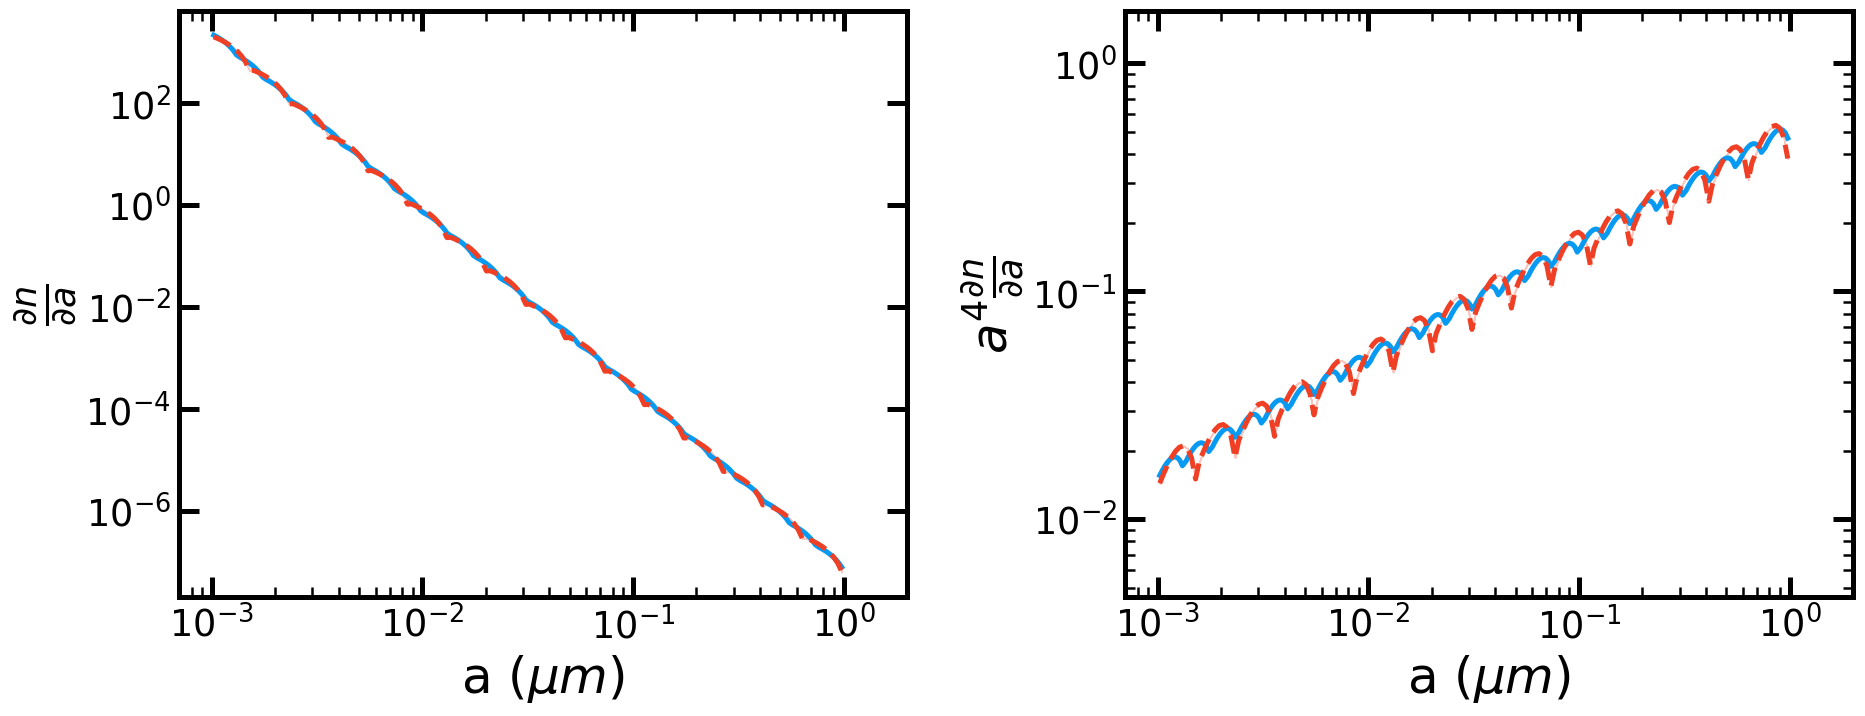

In [39]:

foutname = plot_dir+'snapshot_restart_FIRE3_test.pdf'
fig = Figure(2,ncols=2)
num_snaps = len(snaps)
colors = config.LINE_COLORS[:num_snaps]
linestyles = config.LINE_STYLES[:num_snaps]
linewidth = 2*config.BASE_LINEWIDTH
init_depl = 0

# Restrict to one species
species='silicates'
spec_ind = 0

# number of points per bin
# Any points_per_bin > 1 will follow the slopes in each bin so it can look odd
points_per_bin=10

for i,sp in enumerate(snaps):

    print('snapshot time',sp.time)
    G=sp.loadpart(0)
    if i == 0:
        init_depl=np.sum(G.get_property('dust_Z')[:,7])/np.sum(G.get_property('Z_all')[:,7])
        init_spec_mass = np.sum(G.get_property('M_spec')[:,spec_ind])
        init_N_total = np.sum(G.get_property('N_grain_total')[:,spec_ind])
        print('init depletion',init_depl)
        print('init spec mass',init_spec_mass)
    else:
        final_spec_mass = np.sum(G.get_property('M_spec')[:,spec_ind])
        final_N_total = np.sum(G.get_property('N_grain_total')[:,spec_ind])
        print('snapshot change in spec mass',final_spec_mass/init_spec_mass)
        print('snapshot change in total N grains',final_N_total/init_N_total)

    print(sp.Flag_GrainSizeBins)
    print(sp.Silicates_Element_Key)
    print(sp.Silicates_Element_Number)

    mask = G.get_property('dust_spec')[:,spec_ind]>0
    #mask = calc.get_particle_mask(0, sp, mask_criteria='cold')

    dnda_bin_points, dnda_means, dnda_stds  =  gse.get_grain_size_dist(sp, species=species, mask=mask, mass=False,points_per_bin=points_per_bin)
    dmda_bin_points, dmda_means, dmda_stds =  gse.get_grain_size_dist(sp, species=species, mask=mask, mass=True,points_per_bin=points_per_bin)

    if i == 0:
        fig.set_axis(0, 'grain_size', 'dn/da',y_lim=[np.power(10,-0.5)*np.min(dnda_means[dnda_means>0]),np.power(10,0.5)*np.max(dnda_means)])
        fig.set_axis(1, 'grain_size', 'dm/da',y_lim=[np.power(10,-0.5)*np.min(dmda_means),np.power(10,0.5)*np.max(dmda_means)])

    fig.plot_line_data(0,dnda_bin_points,dnda_means, color=colors[i],linestyle=linestyles[i])
    fig.plot_shaded_region(0,dnda_bin_points,dnda_stds[:,0],dnda_stds[:,1], color=colors[i])


    fig.plot_line_data(1,dmda_bin_points,dmda_means, color=colors[i],linestyle=linestyles[i])
    fig.plot_shaded_region(1,dmda_bin_points,dmda_stds[:,0],dmda_stds[:,1], color=colors[i])

fig.set_all_legends(max_cols=2,rescale_font=0.75)
fig.save(foutname)

### Testing Dust Diffusion

In [49]:
# Name prefix for all saved images. Useful if you run this for multiple sims.
prefix=['size_evolution_dev']

main_dirc = '/N/u/cchoban/BigRed200/size_evolution_dev/'
# Names of simulation directories
sim_names = np.array(['size_evolution_dev'])

# Snapshot to check
snap_nums = [0,5]

snap_dir = main_dirc+'/FIRE3_diffusion_output/'

In [45]:
snaps = []


print("Snap Dirc: ",snap_dir)

for j, snap_num in enumerate(snap_nums):
    print("Snap Num:",snap_num)
    sp = load_snap(snap_dir, snap_num, cosmological=0)
    snaps += [sp]


Snap Dirc:  /N/u/cchoban/BigRed200/size_evolution_dev//FIRE3_diffusion_output/
Snap Num: 0
This snap has grain size bins!
Snap Num: 10
This snap has grain size bins!


snapshot time 0.0
init depletion 0.5
init spec mass 16412767.0
snapshot time 0.01
snapshot change in spec mass 0.99985474
snapshot change in total N grains 0.9998529548385963


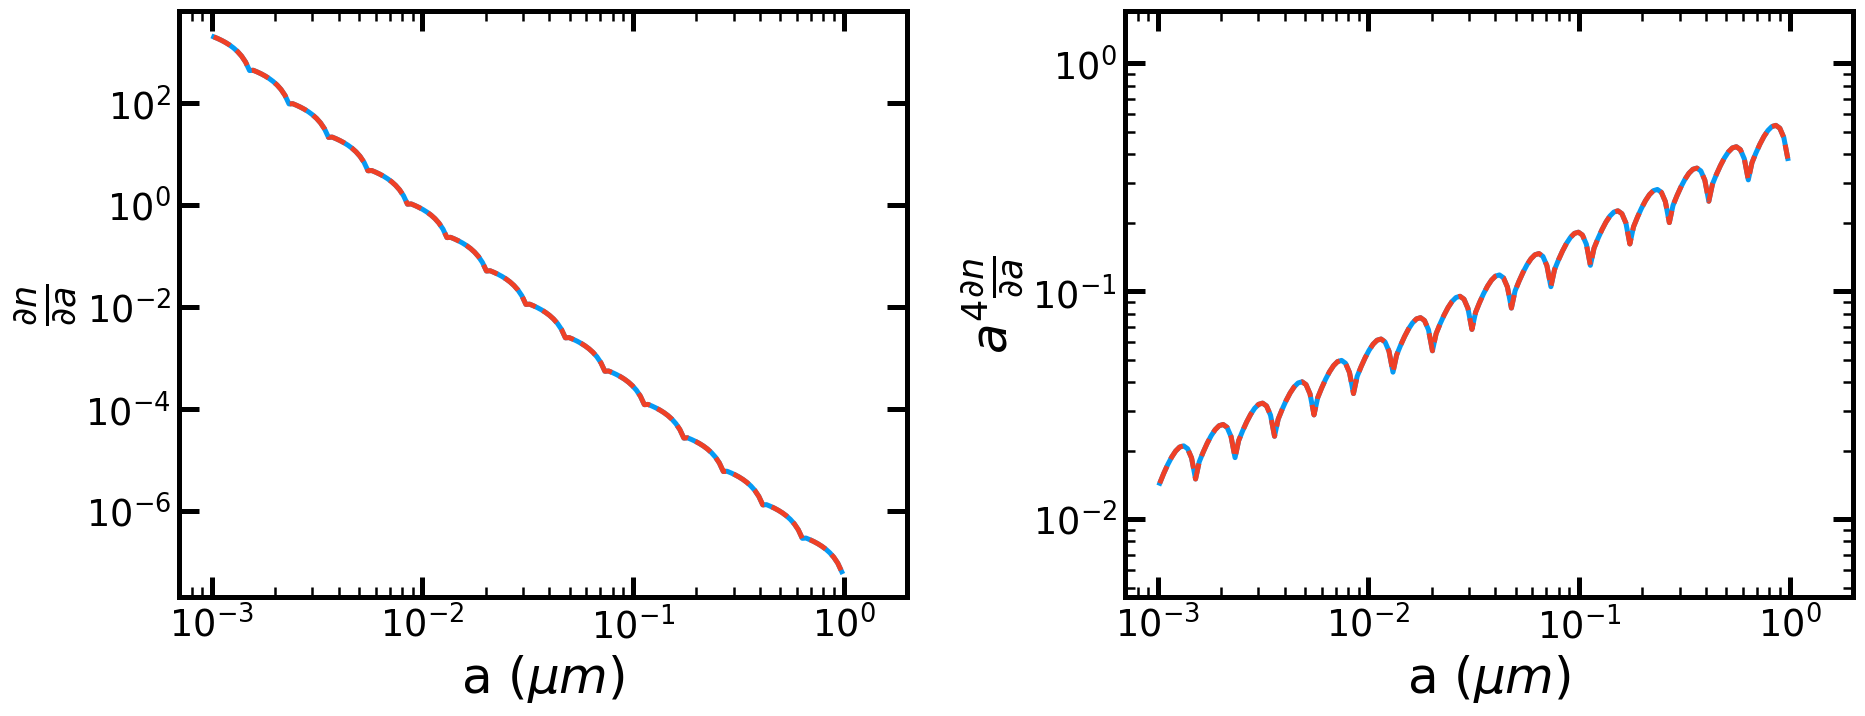

In [48]:

foutname = plot_dir+'diffusion_test_FIRE3_test.pdf'
fig = Figure(2,ncols=2)
num_snaps = len(snaps)
colors = config.LINE_COLORS[:num_snaps]
linestyles = config.LINE_STYLES[:num_snaps]
linewidth = 2*config.BASE_LINEWIDTH
init_depl = 0

# Restrict to one species
species='silicates'
spec_ind = 0

# number of points per bin
# Any points_per_bin > 1 will follow the slopes in each bin so it can look odd
points_per_bin=10

for i,sp in enumerate(snaps):

    print('snapshot time',sp.time)
    G=sp.loadpart(0)
    if i == 0:
        init_depl=np.sum(G.get_property('dust_Z')[:,7])/np.sum(G.get_property('Z_all')[:,7])
        init_spec_mass = np.sum(G.get_property('M_spec')[:,spec_ind])
        init_N_total = np.sum(G.get_property('N_grain_total')[:,spec_ind])
        print('init depletion',init_depl)
        print('init spec mass',init_spec_mass)
    else:
        final_spec_mass = np.sum(G.get_property('M_spec')[:,spec_ind])
        final_N_total = np.sum(G.get_property('N_grain_total')[:,spec_ind])
        print('snapshot change in spec mass',final_spec_mass/init_spec_mass)
        print('snapshot change in total N grains',final_N_total/init_N_total)

    mask = G.get_property('dust_spec')[:,spec_ind]>0
    #mask = calc.get_particle_mask(0, sp, mask_criteria='cold')

    dnda_bin_points, dnda_means, dnda_stds  =  gse.get_grain_size_dist(sp, species=species, mask=mask, mass=False,points_per_bin=points_per_bin, percentiles = [50, 1, 99])
    dmda_bin_points, dmda_means, dmda_stds =  gse.get_grain_size_dist(sp, species=species, mask=mask, mass=True,points_per_bin=points_per_bin, percentiles = [50, 1, 99])

    if i == 0:
        fig.set_axis(0, 'grain_size', 'dn/da',y_lim=[np.power(10,-0.5)*np.min(dnda_means[dnda_means>0]),np.power(10,0.5)*np.max(dnda_means)])
        fig.set_axis(1, 'grain_size', 'dm/da',y_lim=[np.power(10,-0.5)*np.min(dmda_means),np.power(10,0.5)*np.max(dmda_means)])

    fig.plot_line_data(0,dnda_bin_points,dnda_means, color=colors[i],linestyle=linestyles[i])
    fig.plot_shaded_region(0,dnda_bin_points,dnda_stds[:,0],dnda_stds[:,1], color=colors[i])


    fig.plot_line_data(1,dmda_bin_points,dmda_means, color=colors[i],linestyle=linestyles[i])
    fig.plot_shaded_region(1,dmda_bin_points,dmda_stds[:,0],dmda_stds[:,1], color=colors[i])

fig.set_all_legends(max_cols=2,rescale_font=0.75)
fig.save(foutname)

### Testing SNe Injection + Diffusion

In [65]:
# Name prefix for all saved images. Useful if you run this for multiple sims.
prefix=['size_evolution_dev']

main_dirc = '/N/u/cchoban/BigRed200/size_evolution_dev/'
# Names of simulation directories
sim_names = np.array(['size_evolution_dev'])

# Snapshot to check
snap_nums = [0,5,10]

snap_dir = main_dirc+'/output/'

In [66]:
snaps = []


print("Snap Dirc: ",snap_dir)

for j, snap_num in enumerate(snap_nums):
    print("Snap Num:",snap_num)
    sp = load_snap(snap_dir, snap_num, cosmological=0)
    snaps += [sp]


Snap Dirc:  /N/u/cchoban/BigRed200/size_evolution_dev//output/
Snap Num: 0
This snap has grain size bins!
Snap Num: 5
This snap has grain size bins!
Snap Num: 10
This snap has grain size bins!


snapshot time 0.0
init depletion 0.0
init spec mass 0.0
init old star mass 5481000.0 0.000115999996
snapshot time 0.005
spec mass 21259.547
snapshot change in spec mass inf
snapshot change in total N grains inf


/tmp/ipykernel_70698/630948567.py:39: RuntimeWarning: divide by zero encountered in scalar divide
  print('snapshot change in spec mass',final_spec_mass/init_spec_mass)
/tmp/ipykernel_70698/630948567.py:40: RuntimeWarning: divide by zero encountered in scalar divide
  print('snapshot change in total N grains',final_N_total/init_N_total)


snapshot time 0.01
spec mass 40288.613
snapshot change in spec mass inf
snapshot change in total N grains inf


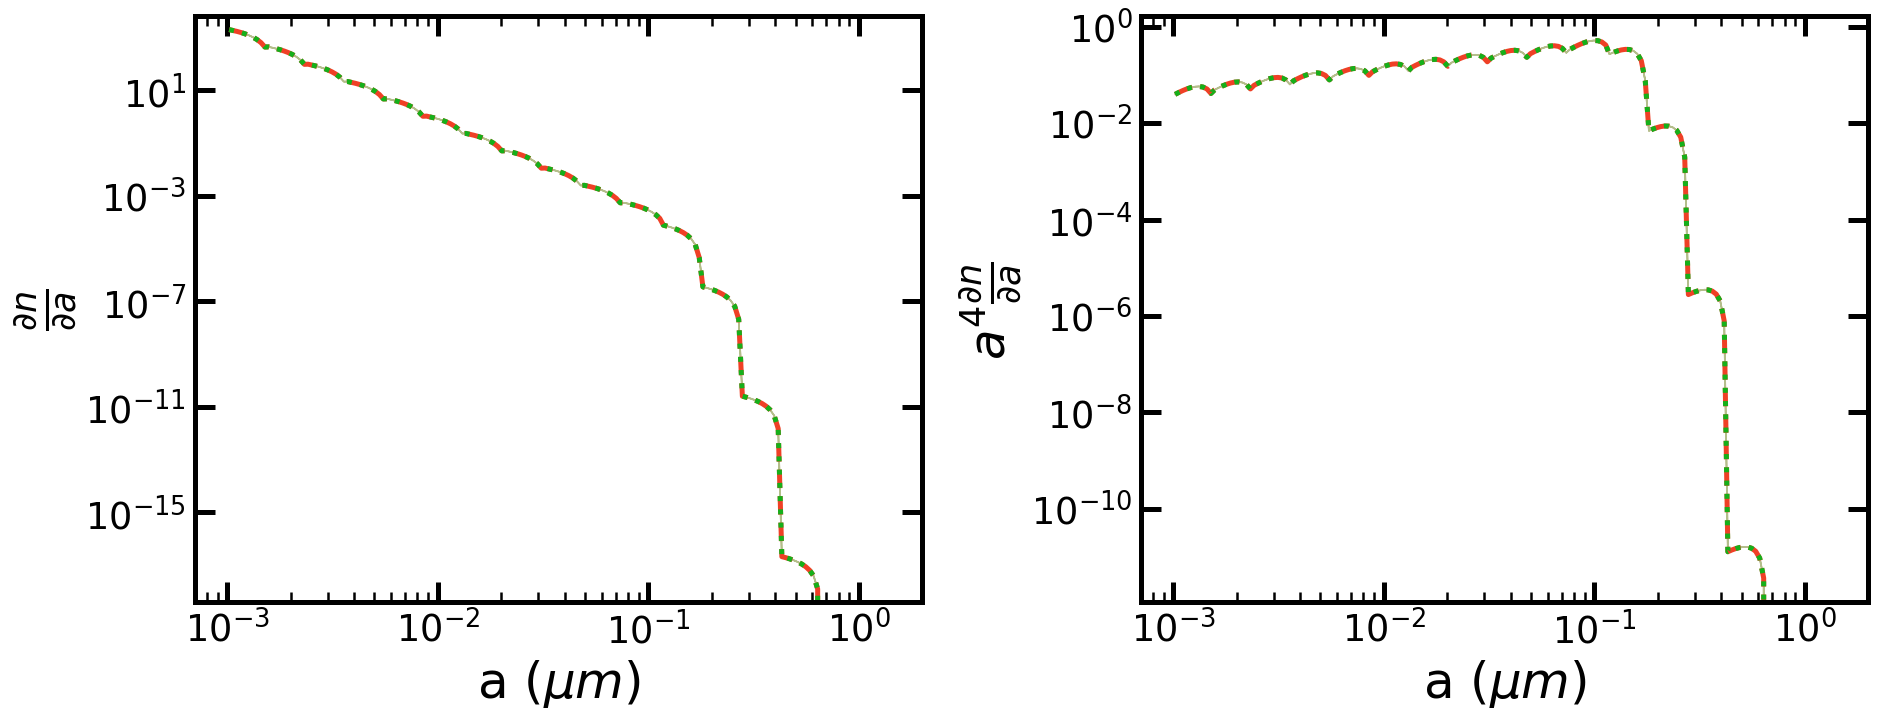

In [67]:

foutname = plot_dir+'SNe_diffusion_test_FIRE2_test.pdf'
fig = Figure(2,ncols=2)
num_snaps = len(snaps)
colors = config.LINE_COLORS[:num_snaps]
linestyles = config.LINE_STYLES[:num_snaps]
linewidth = 2*config.BASE_LINEWIDTH
init_depl = 0

# Restrict to one species
species='silicates'
spec_ind = 0

# number of points per bin
# Any points_per_bin > 1 will follow the slopes in each bin so it can look odd
points_per_bin=10

for i,sp in enumerate(snaps):

    print('snapshot time',sp.time)
    G=sp.loadpart(0)
    if i == 0:
        init_depl=np.sum(G.get_property('dust_Z')[:,7])/np.sum(G.get_property('Z_all')[:,7])
        init_spec_mass = np.sum(G.get_property('M_spec')[:,spec_ind])
        init_N_total = np.sum(G.get_property('N_grain_total')[:,spec_ind])
        print('init depletion',init_depl)
        print('init spec mass',init_spec_mass)
        old_S = sp.loadpart(2)
        age = old_S.get_property('age')
        M_young = np.sum(old_S.get_property('mass')[age < 2e-3])
        print('init old star mass',M_young, M_young/np.sum(old_S.get_property('mass')))

        
        if init_spec_mass == 0:
            continue
    else:
        final_spec_mass = np.sum(G.get_property('M_spec')[:,spec_ind])
        final_N_total = np.sum(G.get_property('N_grain_total')[:,spec_ind])
        print('spec mass',final_spec_mass)
        print('snapshot change in spec mass',final_spec_mass/init_spec_mass)
        print('snapshot change in total N grains',final_N_total/init_N_total)

    mask = G.get_property('dust_spec')[:,spec_ind]>0
    #mask = calc.get_particle_mask(0, sp, mask_criteria='cold')

    dnda_bin_points, dnda_means, dnda_stds  =  gse.get_grain_size_dist(sp, species=species, mask=mask, mass=False,points_per_bin=points_per_bin)
    dmda_bin_points, dmda_means, dmda_stds =  gse.get_grain_size_dist(sp, species=species, mask=mask, mass=True,points_per_bin=points_per_bin)

    fig.set_axis(0, 'grain_size', 'dn/da',y_lim=[np.power(10,-0.5)*np.min(dnda_means[dnda_means>0]),np.power(10,0.5)*np.max(dnda_means)])
    fig.set_axis(1, 'grain_size', 'dm/da',y_lim=[np.power(10,-0.5)*np.min(dmda_means[dmda_means>0]),np.power(10,0.5)*np.max(dmda_means)])

    fig.plot_line_data(0,dnda_bin_points,dnda_means, color=colors[i],linestyle=linestyles[i])
    fig.plot_shaded_region(0,dnda_bin_points,dnda_stds[:,0],dnda_stds[:,1], color=colors[i])


    fig.plot_line_data(1,dmda_bin_points,dmda_means, color=colors[i],linestyle=linestyles[i])
    fig.plot_shaded_region(1,dmda_bin_points,dmda_stds[:,0],dmda_stds[:,1], color=colors[i])

fig.set_all_legends(max_cols=2,rescale_font=0.75)
fig.save(foutname)

### Testing SNe Destruction

In [ ]:
# Name prefix for all saved images. Useful if you run this for multiple sims.
prefix=['size_evolution_dev']

main_dirc = '/N/u/cchoban/BigRed200/'
# Names of simulation directories
sim_names = np.array(['size_evolution_dev'])

# Snapshot to check
snap_nums = [5,10]

# Main sim directories and their snap and halo directories
# Default sim layout is assumed
# Note you need to specify the dtype or else you get numpy strings which annoying to deal with
main_dirs = np.array([main_dirc+name+'/' for name in sim_names], dtype=object)
snap_dirs = np.array([main_dirc+name+'/FIRE2_SNeDust_output/' for name in sim_names], dtype=object)
hdirs = np.array([main_dirc+name+'/halo/ahf/output/' for name in sim_names], dtype=object)
# We only look at the main halos
halo_histories = np.array([main_dirc+name+'/halo/ahf/history/halo_main.dat' for name in sim_names], dtype=object)

In [ ]:
snaps = [[]]*len(snap_dirs)

for i,snap_dir in enumerate(snap_dirs):
    print("Snap Dirc: ",snap_dir)
    name = sim_names[i]
    hdir = hdirs[i]

    for j, snap_num in enumerate(snap_nums):
        print("Snap Num:",snap_num)
        sp = load_snap(snap_dir, snap_num, cosmological=0)
        snaps[i] += [sp]


Snap Dirc:  /N/u/cchoban/BigRed200/size_evolution_dev/FIRE2_SNeDust_output/
Snap Num: 5
This snap has grain size bins!
Snap Num: 10
This snap has grain size bins!


[437500 437500 250000 125000      0      1]
0.0008412053
0.0007292468
2.7887592
0.57022357


/geode2/home/u020/cchoban/BigRed200/codes/crc_scripts/src/crc_scripts/utils/plot_utils.py:332: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  axis.set_ylim(y_lim)


[437338 437500 250000 125000    162      1]
[0.         1.4062496  1.5624994  2.96875    1.4062496  1.7187502
 0.3124997  0.3124997  0.3124997  2.3046873  0.93750006 1.8750001
 1.2499998  0.15624985 0.3124997  0.6249994  0.3124997  0.3124997
 1.8750001  2.2265623  1.9140625  2.3437495  1.7187502  2.1874998
 2.03125    3.1249998  2.03125    2.1874998  2.8124998  0.93750006
 0.46874955 1.8750001  2.03125    1.5624994  1.5624994  2.03125
 0.46874955 0.46874955 1.7187502  0.93750006 0.3124997  2.3437495
 2.6562498  1.8750001  2.3437495  1.4062496  1.6406244  0.6249994
 0.6249994  0.         0.46874955 0.93750006 1.5624994  0.6249994
 1.3281246  1.2499998  3.1249998  2.3437495  2.03125    0.15624985
 0.6249994  1.5624994  2.1874998  1.0937499  1.4062496  0.7812502
 1.3671871  0.6249994  2.8124998  1.7187502  1.4062496  3.2812498
 0.74218774 0.6249994  2.03125    1.5624994  0.         0.
 2.8124998  2.8124998  4.3749995  1.2499998  1.8750001  0.93750006
 1.0937499  0.93750006 1.4062496  1.64

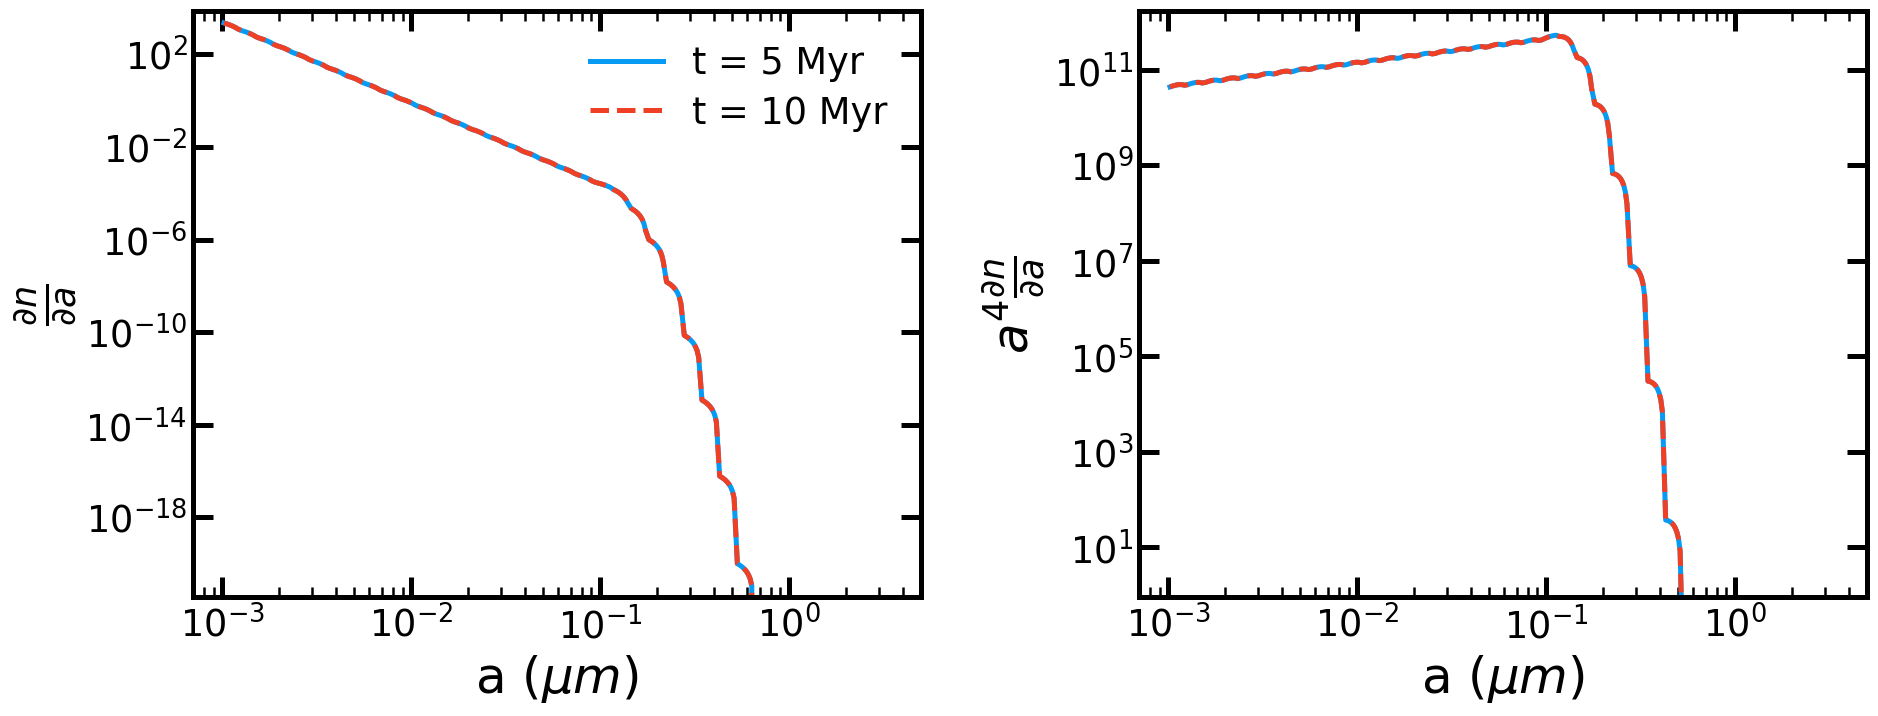

In [ ]:
for i,sim_snaps in enumerate(snaps):

    foutname = plot_dir+sim_names[i] + '_SNeDest0_FIRE2_test.pdf'
    num_snaps = len(sim_snaps)
    fig = Figure(2,ncols=2)
    colors = config.LINE_COLORS[:num_snaps]
    linestyles = config.LINE_STYLES[:num_snaps]
    linewidth = 2*config.BASE_LINEWIDTH
    for j,sp in enumerate(sim_snaps):
        G=sp.loadpart(0)
        S=sp.loadpart(3)
        new_S=sp.loadpart(4)
        print(sp.npart)
        if (sp.npart[4] > 0):
            print(new_S.get_property('age')*1E3)
        time = sp.time*1E3
        spec_ind = 0
        mask = G.get_property('dust_spec')[:,spec_ind]>0
        #mask = calc.get_particle_mask(0, sp, mask_criteria='cold')

        dnda_bin_points, dnda_means, dnda_stds  =  gse.get_grain_size_dist(sp, spec_ind, mask=mask, mass=False,points_per_bin=10)
        dmda_bin_points, dmda_means, dmda_stds =  gse.get_grain_size_dist(sp, spec_ind, mask=mask, mass=True,points_per_bin=10)
        
        age1_mask = (S.get_property('age')<35E-3) & (S.get_property('age')>5E-3)
        age2_mask = (S.get_property('age')<40E-3)
        print(np.sum(G.get_property('M_dust')) / np.sum(S.get_property('M')[age1_mask]))
        print(np.sum(G.get_property('M_dust')) / np.sum(S.get_property('M')[age2_mask]))
        print(np.sum(G.get_property('M_sil'))/np.sum(G.get_property('M_carb')))
        print(np.sum(G.get_property('M_iron'))/np.sum(G.get_property('M_carb')))

        if j == 0:
            fig.set_axis(0, 'grain_size', 'dn/da',y_lim=[np.power(10,-0.5)*np.min(dnda_means[dnda_means>0]),np.power(10,0.5)*np.max(dnda_means)])
            fig.set_axis(1, 'grain_size', 'dm/da',y_lim=[np.power(10,-0.5)*np.min(dmda_means),np.power(10,0.5)*np.max(dmda_means)])

        fig.plot_line_data(0,dnda_bin_points,dnda_means, color=colors[j],linestyle=linestyles[j],label="t = %.0f Myr"%snap_nums[j])
        fig.plot_shaded_region(0,dnda_bin_points,dnda_stds[:,0],dnda_stds[:,1], color=colors[j])
        fig.plot_line_data(1,dmda_bin_points,dmda_means, color=colors[j],linestyle=linestyles[j])
        fig.plot_shaded_region(1,dmda_bin_points,dmda_stds[:,0],dmda_stds[:,1], color=colors[j])

    # Add a comparison to the MRN size distribution
    # C_norm = 1E3/np.power(dnda_bin_points[0],-3.5);
    # MRN_dist = C_norm * np.power(dnda_bin_points,-3.5)
    # fig.plot_line_data(0,dnda_bin_points,MRN_dist, color='xkcd:grey',linestyle=linestyles[1], label='MRN')

    # C_norm = 1E10/np.power(dnda_bin_points[0],0.5);
    # MRN_dist = C_norm * np.power(dnda_bin_points,0.5)
    # fig.plot_line_data(1,dnda_bin_points,MRN_dist, color='xkcd:grey',linestyle=linestyles[1], label='MRN')

    fig.set_all_legends()
    fig.save(foutname)

# Simulation Analysis

In [219]:
# Name prefix for all saved images. Useful if you run this for multiple sims.
prefix=['size_evolution_dev']


# Names of simulation directories
sim_names = np.array(['size_evolution_dev'])


### Load and Check Single Snapshot for Multiple Simulations

In [559]:
main_dirc = '/N/project/choban_group/cchoban/size_evolution_tests/full_sim/'

# Snapshot to check
snap_num = 0


snap_dirs = [main_dirc+'/init_dust_output/',
             #main_dirc+'/FIRE3_all_output/',
             #main_dirc+'/FIRE2_all_output/',
             ]

# Shorthand names for each sim used in plot legends and file names
sim_names = ['new',
             #'FIRE3_all',
             #'FIRE2_all'
             ]


snap_num = 200

snaps = []


for snap_dir in snap_dirs:
    print("Snap Dirc: ",snap_dir)

    print("Snap Num:",snap_num)
    sp = load_snap(snap_dir, snap_num, cosmological=0)
    snaps += [sp]
    print(sp.time,sp.npart)
    print('total new star+gas particles',sp.npart[0]+sp.npart[4]) 
    G=sp.loadpart(0)
    print('gas')
    gas_mass = G.get_property('mass')
    print('gas mass', np.sum(gas_mass)/1E10)
    print('max min and median gas mass',np.max(gas_mass), np.min(gas_mass), np.median(gas_mass))
    dust_mass = G.get_property('M_dust')
    H2_mass = G.get_property('M_H2')
    print('dust_mass', np.sum(dust_mass)/1E10)
    print('H2 mass', np.sum(H2_mass)/1E10)
    print
    print('stars')
    if(sp.npart[4] > 0):
        S=sp.loadpart(4)
        new_star_mass = S.get_property('mass')
        print('new star mass', np.sum(new_star_mass)/1E10)
        print("Max/Min/Median star mass:", np.max(new_star_mass), np.min(new_star_mass), np.median(new_star_mass))
    else: new_star_mass=0
    S_IC1 = sp.loadpart(2)
    S_IC2 = sp.loadpart(3)
    star_IC1_mass = S_IC1.get_property('mass')
    star_IC2_mass = S_IC2.get_property('mass')
    star_IC1_age = S_IC1.get_property('age')
    star_IC2_age = S_IC2.get_property('age')
    print('star IC1 mass', np.sum(star_IC1_mass)/1E10)
    print('star IC2 mass', np.sum(star_IC2_mass)/1E10)
    print('star IC1 age', np.median(star_IC1_age))
    print('star IC2 age', np.median(star_IC2_age))

        
    print("star+gas mass",(np.sum(new_star_mass) + np.sum(gas_mass) + np.sum(star_IC1_mass) + np.sum(star_IC2_mass))/1E10)


Snap Dirc:  /N/project/choban_group/cchoban/size_evolution_tests/full_sim//init_dust_output/
Snap Num: 200
1.0 [348287 437500 250000 125000  89470      1]
total new star+gas particles 437757
gas
gas mass 0.7745086464
max min and median gas mass 61830.965 20571.428 21176.545
dust_mass 0.0014010719
H2 mass 0.000234306275
stars
new star mass 0.1710411904
Max/Min/Median star mass: 53235.37 14537.825 17934.041
star IC1 mass 4.6895181824
star IC2 mass 1.4899320832
star IC1 age 8.045581
star IC2 age 8.025793
star+gas mass 7.125000192


#### Quick Check of Global Galaxy Properties

In [511]:
ISM_phases = ['cold','warm','hot','coronal']

for i,sp in enumerate(snaps):
    name = sim_names[i]

    print(name)
    G=sp.loadpart(0)
    S=sp.loadpart(4)

    gas_mass = G.get_property('mass')
    H2_mass = G.get_property('M_H2')
    dust_mass = G.get_property('M_dust')
    spec_mass = G.get_property('M_spec')
    DZ = G.get_property('D/Z')

    print('gas mass', np.sum(gas_mass)/1E10)
    print('H2 mass', np.sum(H2_mass)/1E10)
    print('dust mass', np.sum(dust_mass)/1E10)
    print('spec mass', np.sum(spec_mass,axis=0)/1E10)
    print('median D/Z', np.median(DZ))

    for i,phase in enumerate(ISM_phases):
        mask = calc.get_particle_mask(0, sp, mask_criteria=phase)
        print(phase,"phase gas mass:",np.sum(gas_mass[mask])/1E10)

    mach_num = G.get_property('mach_number')
    temp = G.get_property('temperature')
    T_clumping_factor = G.get_property('T_clumping_factor')
    Tcut = 1000
    T_cutoff = temp <= Tcut
    print("For Tcut = ", Tcut)
    print("T<Tcut gas mass:",np.sum(gas_mass[T_cutoff])/1E10)
    T_cutoff = temp*T_clumping_factor <= Tcut
    print("T<Tcut*T_clump gas mass:",np.sum(gas_mass[T_cutoff])/1E10)

    Tcut = 300
    T_cutoff = temp <= Tcut
    print("For Tcut = ", Tcut)
    print("T<Tcut gas mass:",np.sum(gas_mass[T_cutoff])/1E10)
    T_cutoff = temp*T_clumping_factor <= Tcut
    print("T<Tcut*T_clump gas mass:",np.sum(gas_mass[T_cutoff])/1E10)
        

new
gas mass 0.7745086464
H2 mass 0.000234306275
dust mass 0.0014010719
spec mass [0.00077129 0.00040506 0.00022474]
median D/Z 0.11543996
cold phase gas mass: 0.0117773368
warm phase gas mass: 0.6981728768
hot phase gas mass: 0.0645583808
coronal phase gas mass: 0.0072277632
For Tcut =  1000
T<Tcut gas mass: 0.0117773368
T<Tcut*T_clump gas mass: 0.0211814688
For Tcut =  300
T<Tcut gas mass: 0.0027452028
T<Tcut*T_clump gas mass: 0.007970264


#### Snapshot Projections

3
/N/project/choban_group/cchoban/size_evolution_tests/full_sim//init_dust_output/


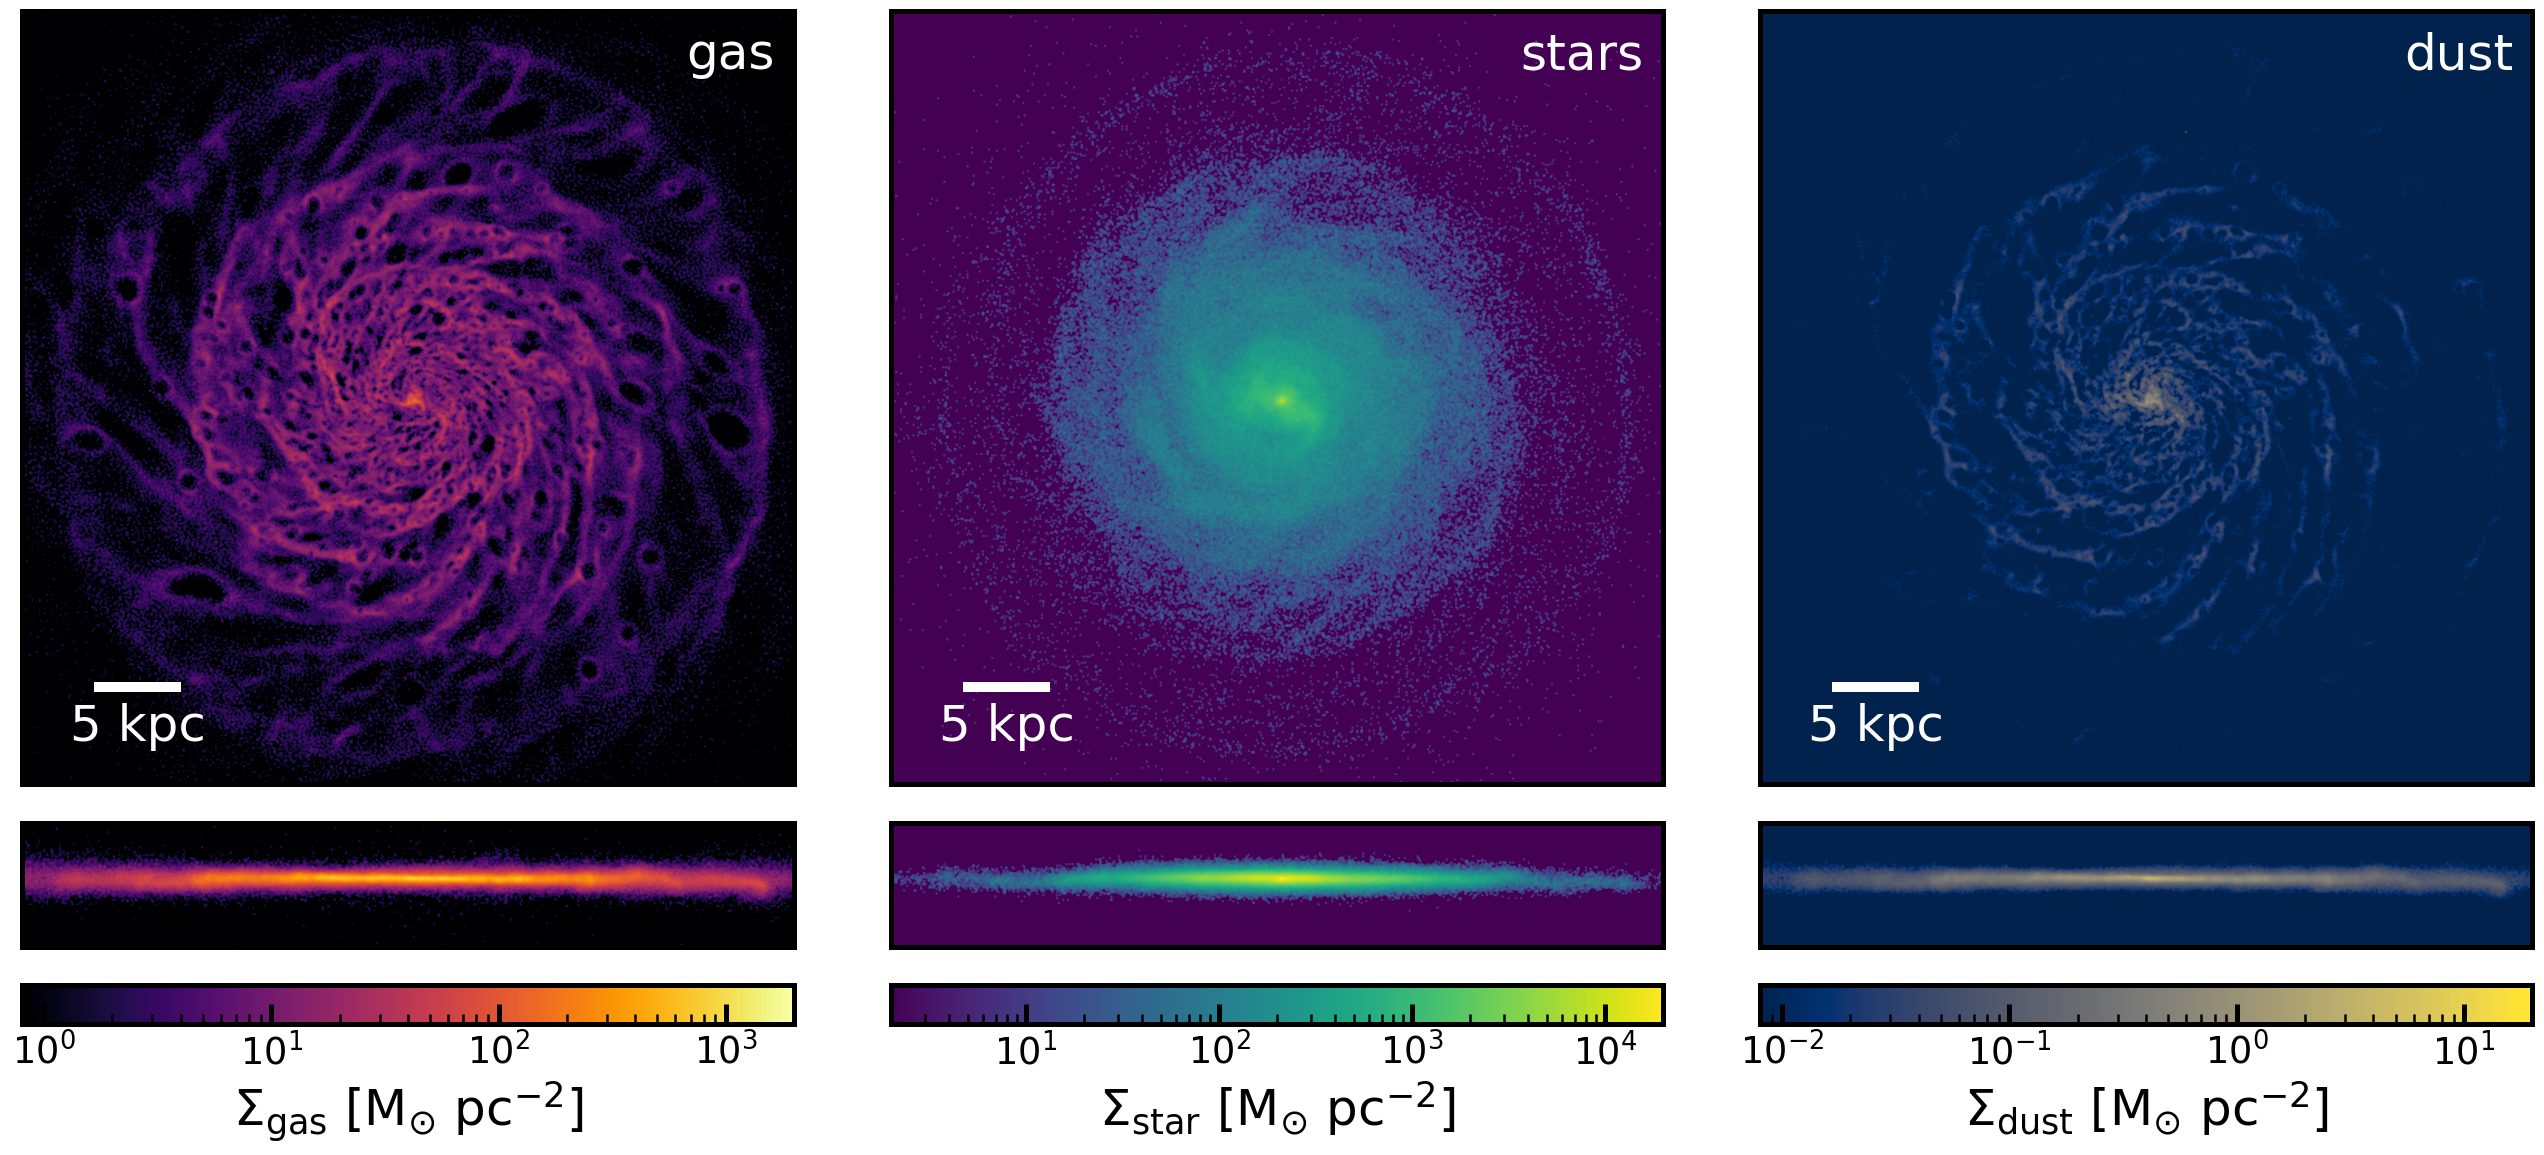

In [515]:

foutname = 'snapshot_projections.pdf'

# Physical size of projection 
proj_L = 15 # kpc
# Size resolution (kpc) for each "pixel" in projection
pixel_res=0.1
# Properties to plot projections of. Can be surface densities (total mass in pixel divided by pixel size) or properties like T (median value of all particles in pixel)
properties = ['sigma_gas','sigma_star','sigma_dust']
# Limits for projection of each property. Defaults if not set
prop_limits = [[8E-1,2E3],[2E0,2E4],[8E-3,2E1]]
# Colormaps for each projection
prop_cmaps = ['inferno','viridis','cividis']
# Do you want log colormaps for each property (default = True)
log_cmaps = [True]*len(properties)
# Labels for each projection is so desired
labels = ['gas','stars','dust']
# Physical size of projection 
proj_L = 50 # kpc
# Do you want a secondary projection from an orthogonal axis (i.e. edge-on)
sub_proj = True
# size of secondary projection
sub_L = 8 # kpc



for i,sp in enumerate(snaps):
    print(sp.sdir)
    name = sim_names[i]
    # Initialize projection figure
    L = proj_L
    height_ratios = [L/sub_L,1]
    new_proj = Projection(len(properties), add_sub_proj=sub_proj, add_colorbars=True, height_ratios=height_ratios)
    # Create projections for each property and plot the projection
    for j,prop in enumerate(properties):
        new_proj.set_proj_axis(j, prop, L, axes_visible=False)
        # Create x-y projection using a 2D histogram
        main_pixel_stats, main_xedges, main_yedges, main_extent = calc.calc_projected_prop(prop, sp, [L,L,L], pixel_res=pixel_res, proj='xy')
        if sub_proj:
            # Create x-z subprojection using a 2D histogram
            sub_pixel_stats, sub_xedges, sub_yedges, sub_extent = calc.calc_projected_prop(prop, sp, [L,sub_L,L], pixel_res=pixel_res, proj='xz')
        else:
            sub_pixel_stats=None; sub_extent=None
        # x-z projection
        # Create the projection
        if labels is not None:
            label = labels[j]
        else:
            label=None
        new_proj.plot_projection(j, main_pixel_stats, main_extent, sub_proj_data=sub_pixel_stats, sub_extent=sub_extent,
                                    cmap= prop_cmaps[j], v_limits = prop_limits[j],v_log=log_cmaps[j], label=label)
        
    new_proj.save(plot_dir+name+'_'+str(sp.snum)+'_'+foutname)

Comparing gas phase diagram when accounting for clumping factor.

/N/project/choban_group/cchoban/size_evolution_tests/full_sim//init_dust_output/


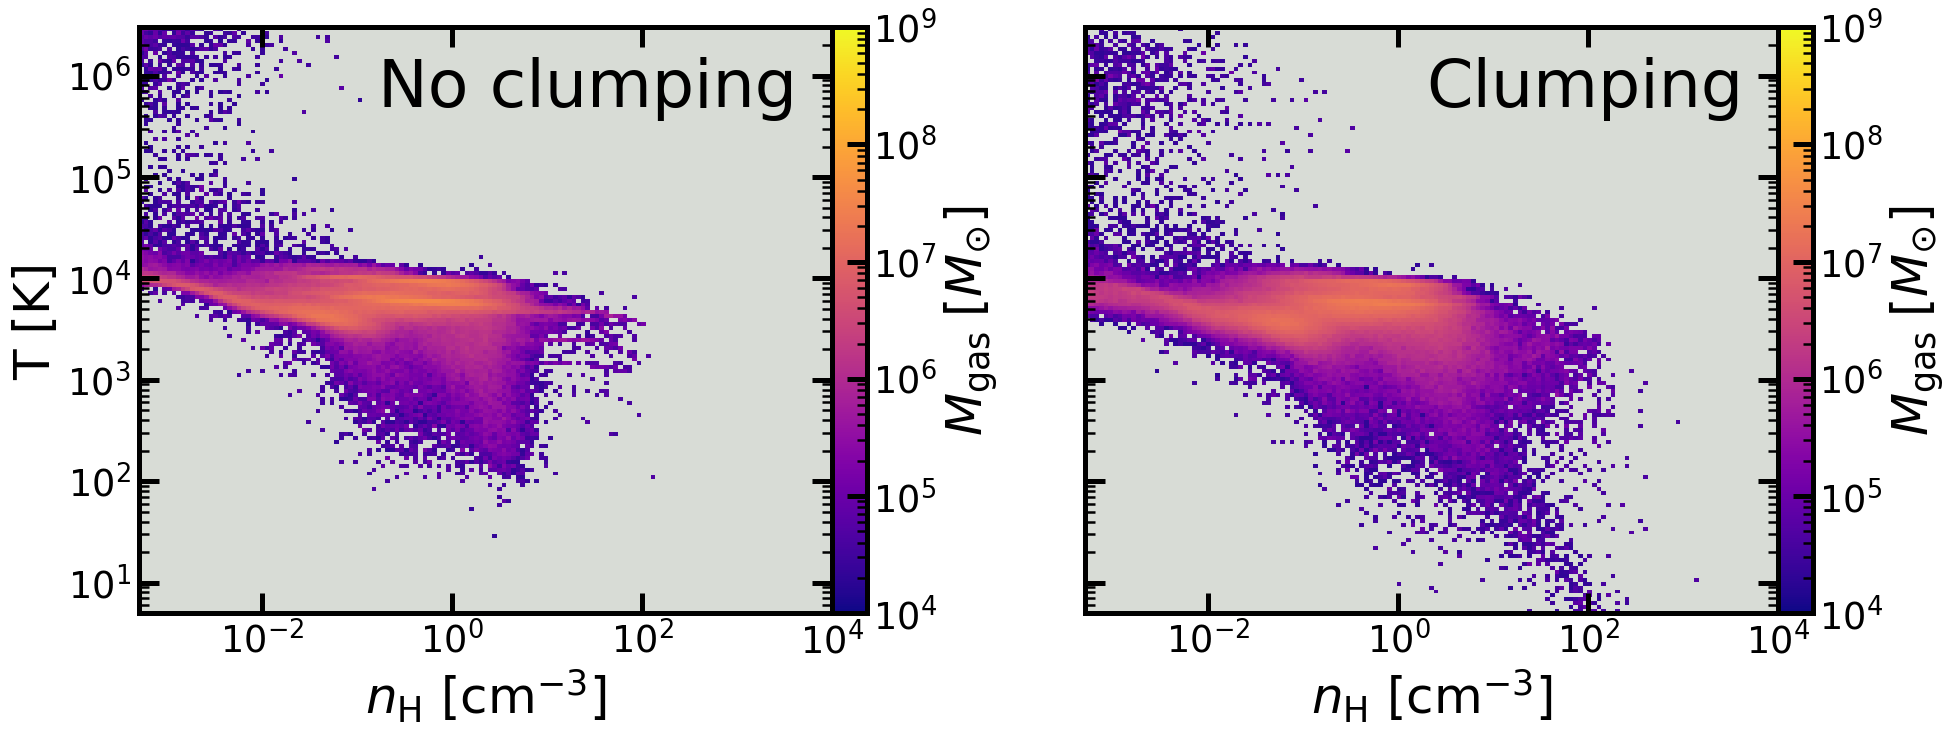

In [519]:
foutname = 'clumping_factor_phase_diagram.pdf'
prop = 'M_gas'
z_logs=[True]
# Number of bins across nH and T space
bin_nums = 150
cmap='plasma'
# nH and T limits
nH_lims = [5E-4,1E4]
T_lims = [5,3E6]

prop_lims=[[1E4,1E9],[1E4,1E9],[1,12],[0.01,0.5]]


for i,sp in enumerate(snaps):
    print(sp.sdir)
    name = sim_names[i]

    fig = Figure(2,ncols=2, sharey=True)

    # Set up for each plot
    fig.set_axis(0, 'nH', 'T', x_lim=nH_lims, x_log=True, y_lim=T_lims, y_log=True, face_color='xkcd:light grey')
    ret = calc.calc_phase_hist_data(prop, sp, bin_nums=bin_nums, nH_lims=nH_lims, T_lims=T_lims, factor_clumping=False)
    X, Y = np.meshgrid(ret.x_edge, ret.y_edge)
    fig.plot_2Dhistogram(0, prop, X, Y, ret.statistic.T, cmap=cmap, z_lim=prop_lims[0], z_log=z_logs[0],label='No clumping')

    # Add colorbar to last axis
    fig.add_colorbar(0,cbar_prop=prop)


    # Set up for each plot
    fig.set_axis(1, 'nH', 'T', x_lim=nH_lims, x_log=True, y_lim=T_lims, y_log=True, face_color='xkcd:light grey')
    ret = calc.calc_phase_hist_data(prop, sp, bin_nums=bin_nums, nH_lims=nH_lims, T_lims=T_lims, factor_clumping=True)
    X, Y = np.meshgrid(ret.x_edge, ret.y_edge)
    fig.plot_2Dhistogram(1, prop, X, Y, ret.statistic.T, cmap=cmap, z_lim=prop_lims[0], z_log=z_logs[0],label='Clumping')

    # Add colorbar to last axis
    fig.add_colorbar(1,cbar_prop=prop)



    fig.save(plot_dir+name+'_'+str(sp.snum)+'_'+foutname)

### Dust Process Rates Phase Diagram

In [661]:
foutname = 'dMdt_phase_diagram.pdf'
props = ['dMdt_acc','dMdt_sput']
fig_labels = ['accretion','sputtering']
z_logs=[True]*len(props)
# Number of bins across nH and T space
bin_nums = 150
cmap='plasma'
# nH and T limits
nH_lims = [5E-5,1E4]
T_lims = [5,8E6]


prop_lims=[[1E-7,1E-3],[1E-8,1E-6]]

# Number of subsampling for each bin when calculating dMdt rates.
# N=1 will assume all grains have the same size in each bin
# Set to a small number to get a good estimate
bin_subsamples = 4



for i,sp in enumerate(snaps):
    print(sp.sdir)
    name = sim_names[i]

    G = sp.loadpart(0)
    dMdt_shat, dMdt_coag = grain_size_utils.get_dust_shattering_and_coagulation_rate(G)

    dMdt_acc = grain_size_utils.get_dust_accretion_rate(G, T_cutoff=1000, factor_clumping=True,bin_subsamples=bin_subsamples)
    print('dMdt_acc:',np.sum(dMdt_acc),'Msol/yr')
    dMdt_sput = grain_size_utils.get_dust_sputtering_rate(G, T_cutoff = 1E4, factor_clumping=True,bin_subsamples=bin_subsamples)
    print('dMdt_sput:',np.sum(dMdt_sput),'Msol/yr')

    dMdt=[dMdt_acc,-dMdt_sput]

    print('dMdt_acc:',np.sum(dMdt_acc),'Msol/yr')

    fig = Figure(len(props),ncols=2, sharex='col',sharey='row')

    for j,prop in enumerate(props):
        # Set up for each plot
        fig.set_axis(j, 'nH', 'T', x_lim=nH_lims, x_log=True, y_lim=T_lims, y_log=True, face_color='xkcd:light grey')
        ret = calc.calc_phase_hist_data(dMdt[j], sp, bin_nums=bin_nums, nH_lims=nH_lims, T_lims=T_lims, bin_func='sum')

        ret.statistic[ret.statistic == 0] = np.nan

        X, Y = np.meshgrid(ret.x_edge, ret.y_edge)
        fig.plot_2Dhistogram(j, prop, X, Y, ret.statistic.T, cmap=cmap, z_lim=prop_lims[j], z_log=z_logs[j],label=fig_labels[j])

        # Add colorbar to last axis
        fig.add_colorbar(j,cbar_prop='dMdt')

    #fig.save(plot_dir+name+'_'+str(sp.snum)+'_'+foutname)

/N/project/choban_group/cchoban/size_evolution_tests/full_sim//init_dust_output/
i: 0
j: 0
k: 0
k: 1
k: 2
k: 3
k: 4
k: 5
k: 6
k: 7
k: 8
k: 9
k: 10
k: 11
k: 12
k: 13
k: 14
k: 15
j: 1
k: 0
k: 1
k: 2
k: 3
k: 4
k: 5
k: 6
k: 7
k: 8
k: 9
k: 10
k: 11
k: 12
k: 13
k: 14
k: 15
j: 2
k: 0
k: 1
k: 2
k: 3
k: 4
k: 5
k: 6
k: 7
k: 8
k: 9
k: 10
k: 11
k: 12
k: 13
k: 14
k: 15
j: 3
k: 0
k: 1
k: 2
k: 3
k: 4
k: 5
k: 6
k: 7
k: 8
k: 9
k: 10
k: 11
k: 12
k: 13
k: 14
k: 15
j: 4
k: 0
k: 1
k: 2
k: 3
k: 4
k: 5
k: 6
k: 7
k: 8
k: 9
k: 10
k: 11
k: 12
k: 13
k: 14
k: 15
j: 5
k: 0
k: 1
k: 2
k: 3
k: 4
k: 5
k: 6
k: 7
k: 8
k: 9
k: 10
k: 11
k: 12
k: 13
k: 14
k: 15
j: 6
k: 0
k: 1
k: 2
k: 3
k: 4
k: 5
k: 6
k: 7
k: 8
k: 9
k: 10
k: 11
k: 12
k: 13
k: 14
k: 15
j: 7
k: 0
k: 1
k: 2
k: 3
k: 4
k: 5
k: 6
k: 7
k: 8
k: 9
k: 10
k: 11
k: 12
k: 13
k: 14
k: 15
j: 8
k: 0
k: 1
k: 2
k: 3
k: 4
k: 5
k: 6
k: 7
k: 8
k: 9
k: 10
k: 11
k: 12
k: 13
k: 14
k: 15
j: 9
k: 0
k: 1
k: 2
k: 3
k: 4
k: 5
k: 6
k: 7
k: 8
k: 9
k: 10
k: 11
k: 12
k: 13
k: 14
k: 15
j: 1

/geode2/home/u020/cchoban/BigRed200/codes/crc_scripts/src/crc_scripts/utils/grain_size/grain_size_utils.py:536: RuntimeWarning: overflow encountered in divide
  
/geode2/home/u020/cchoban/BigRed200/codes/crc_scripts/src/crc_scripts/utils/grain_size/grain_size_utils.py:537: RuntimeWarning: overflow encountered in divide
  shat_dMbin_dt[:,i] = eff_clump_factor / V_cell * np.pi * (-shat_removal_term + shat_injection_term) # g/sec


i: 1
j: 0
k: 0
k: 1
k: 2
k: 3
k: 4
k: 5
k: 6
k: 7
k: 8
k: 9
k: 10
k: 11
k: 12
k: 13
k: 14
k: 15
j: 1
k: 0
k: 1
k: 2
k: 3
k: 4
k: 5
k: 6
k: 7
k: 8
k: 9
k: 10
k: 11
k: 12
k: 13
k: 14
k: 15
j: 2
k: 0
k: 1
k: 2
k: 3
k: 4
k: 5
k: 6
k: 7
k: 8
k: 9
k: 10
k: 11
k: 12
k: 13
k: 14
k: 15
j: 3
k: 0
k: 1
k: 2
k: 3
k: 4
k: 5
k: 6
k: 7
k: 8
k: 9
k: 10
k: 11
k: 12
k: 13
k: 14
k: 15
j: 4
k: 0
k: 1
k: 2
k: 3
k: 4
k: 5
k: 6
k: 7
k: 8
k: 9
k: 10
k: 11
k: 12
k: 13
k: 14
k: 15
j: 5
k: 0
k: 1
k: 2
k: 3
k: 4
k: 5
k: 6
k: 7
k: 8
k: 9
k: 10
k: 11
k: 12
k: 13
k: 14
k: 15
j: 6
k: 0
k: 1
k: 2
k: 3
k: 4
k: 5
k: 6
k: 7
k: 8
k: 9
k: 10
k: 11
k: 12
k: 13
k: 14
k: 15
j: 7
k: 0
k: 1
k: 2
k: 3
k: 4
k: 5
k: 6
k: 7
k: 8
k: 9
k: 10
k: 11
k: 12
k: 13
k: 14
k: 15
j: 8
k: 0
k: 1
k: 2
k: 3
k: 4
k: 5
k: 6
k: 7
k: 8
k: 9
k: 10
k: 11
k: 12
k: 13
k: 14
k: 15
j: 9
k: 0
k: 1
k: 2
k: 3
k: 4
k: 5
k: 6
k: 7
k: 8
k: 9
k: 10
k: 11
k: 12
k: 13
k: 14
k: 15
j: 10
k: 0
k: 1
k: 2
k: 3
k: 4
k: 5
k: 6
k: 7
k: 8
k: 9
k: 10
k: 11
k: 12
k: 13
k: 14

In [ ]:
foutname = 'dMdt_phase_diagram.pdf'
props = ['dMdt_acc','dMdt_sput']
fig_labels = ['accretion','sputtering']
z_logs=[True]*len(props)
# Number of bins across nH and T space
bin_nums = 150
cmap='plasma'
# nH and T limits
nH_lims = [5E-5,1E4]
T_lims = [5,8E6]


prop_lims=[[1E-7,1E-3],[1E-7,1E-4]]

# Number of subsampling for each bin when calculating dMdt rates.
# N=1 will assume all grains have the same size in each bin
# Set to a small number to get a good estimate
bin_subsamples = 4



for i,sp in enumerate(snaps):
    print(sp.sdir)
    name = sim_names[i]

    G = sp.loadpart(0)
    dMdt_acc = grain_size_utils.get_dust_accretion_rate(G, T_cutoff=1000, factor_clumping=True,bin_subsamples=bin_subsamples)
    print('dMdt_acc:',np.sum(dMdt_acc),'Msol/yr')
    dMdt_sput = grain_size_utils.get_dust_sputtering_rate(G, T_cutoff = 1E4, factor_clumping=True,bin_subsamples=bin_subsamples)
    print('dMdt_sput:',np.sum(dMdt_sput),'Msol/yr')

    import matplotlib as mpl
    norm=mpl.colors.SymLogNorm(linthresh=1E-7, linscale=1, vmin=-1E-5, vmax=1E-3)



    dMdt=[dMdt_acc+dMdt_sput]
    dMdt[0][dMdt_acc+dMdt_sput==0]=np.nan

    fig = Figure(len(props),ncols=2, sharex='col',sharey='row')

    for j,prop in enumerate(props):
        if j == 1: continue
        # Set up for each plot
        fig.set_axis(j, 'nH', 'T', x_lim=nH_lims, x_log=True, y_lim=T_lims, y_log=True, face_color='xkcd:light grey')
        ret = calc.calc_phase_hist_data(dMdt[j], sp, bin_nums=bin_nums, nH_lims=nH_lims, T_lims=T_lims, bin_func='sum')
        X, Y = np.meshgrid(ret.x_edge, ret.y_edge)
        fig.plot_2Dhistogram(j, prop, X, Y, ret.statistic.T, cmap=cmap, z_lim=prop_lims[j], z_log=z_logs[j],label=fig_labels[j], norm=norm)

        # Add colorbar to last axis
        fig.add_colorbar(j,cbar_prop='dMdt')

    #fig.save(plot_dir+name+'_'+str(sp.snum)+'_'+foutname)

#### Phase Diagrams

/N/project/choban_group/cchoban/size_evolution_tests/full_sim//init_dust_output/


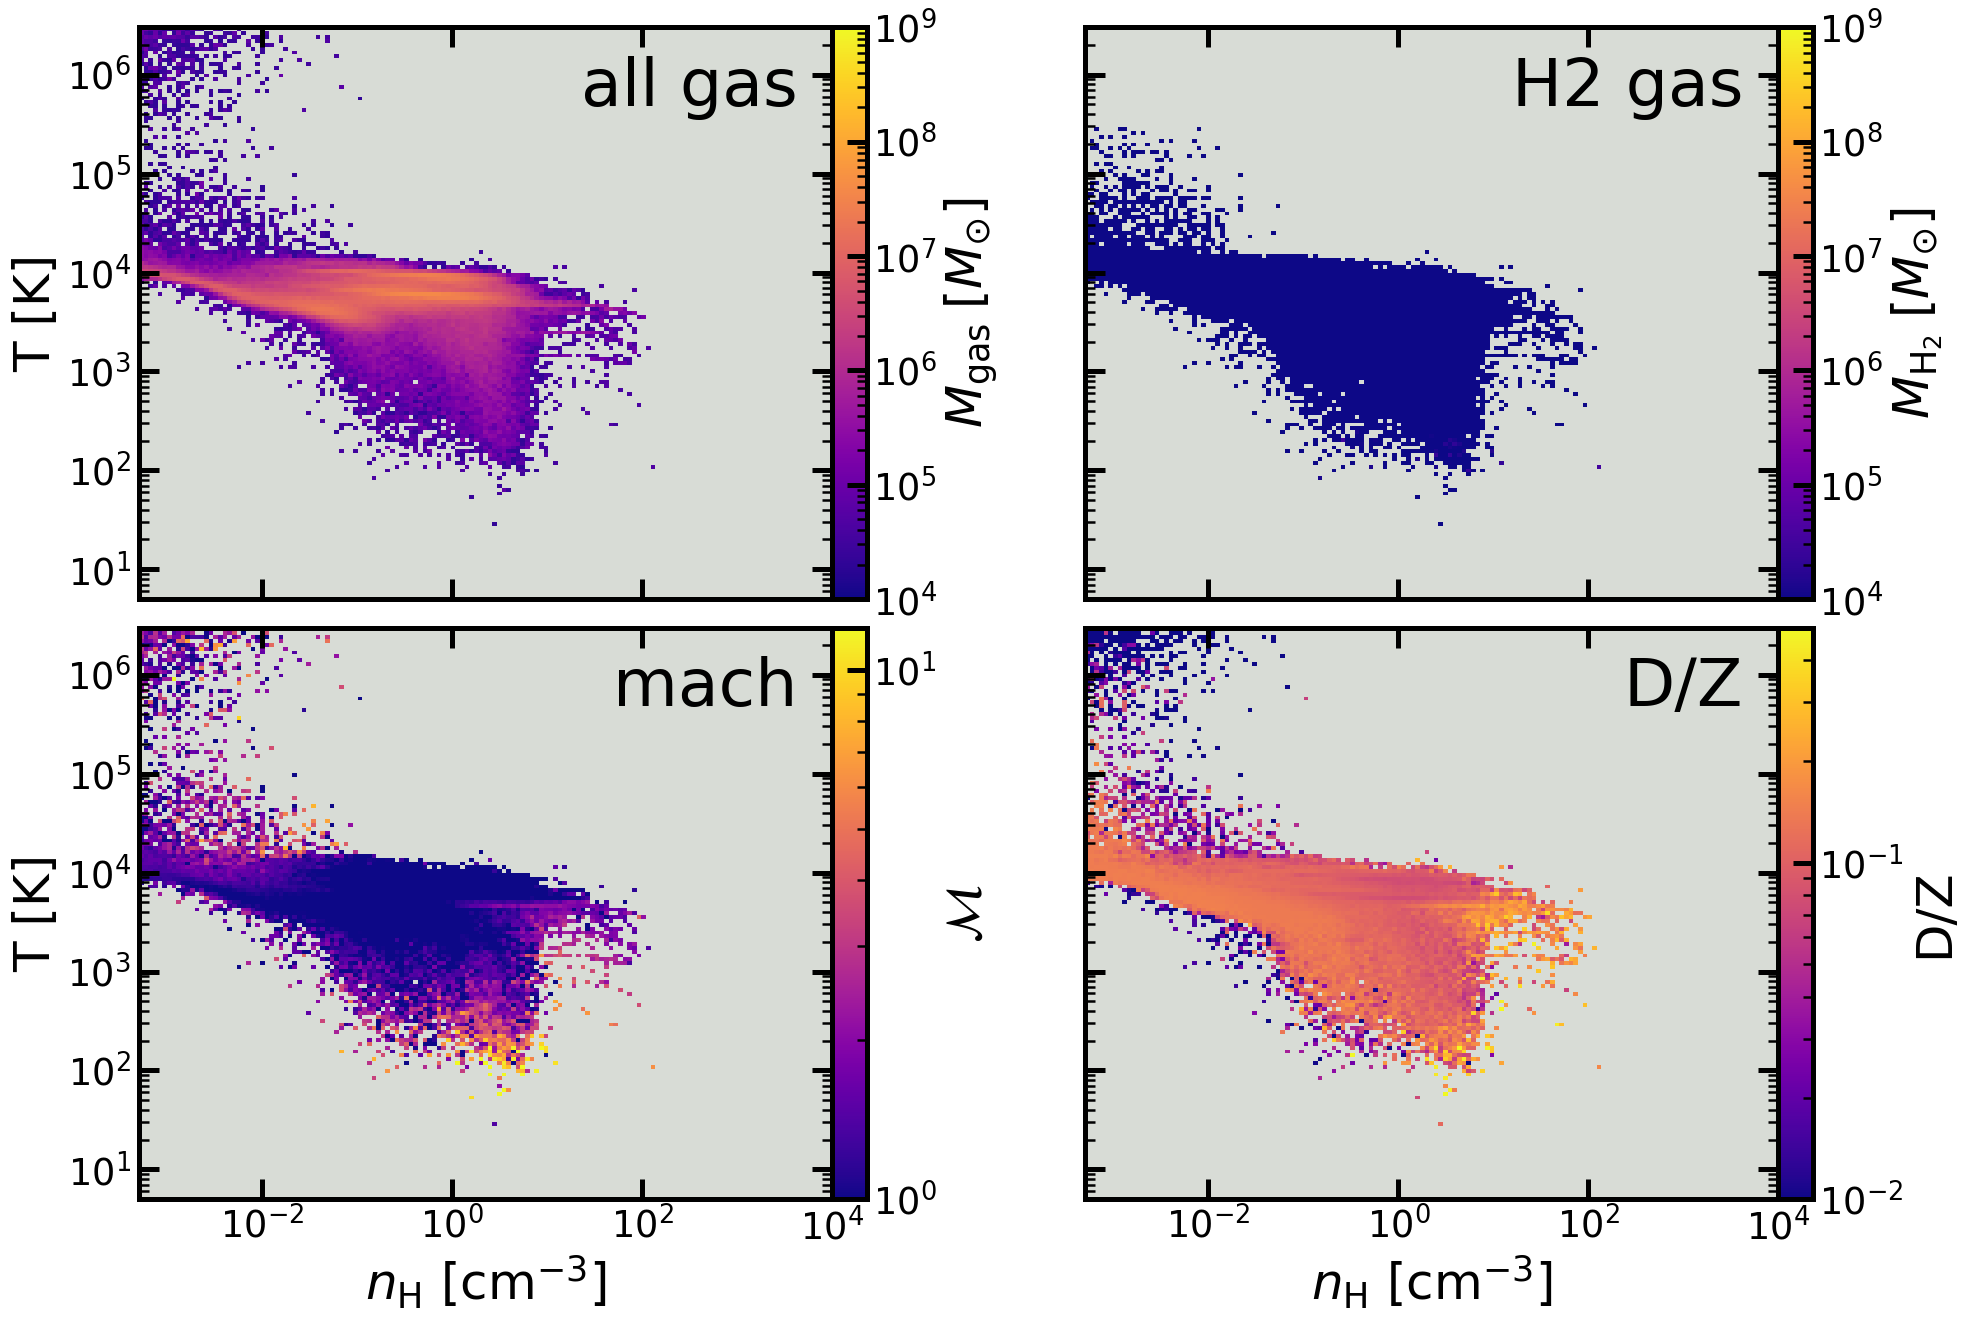

In [622]:
foutname = 'phase_diagram.pdf'
props = ['M_gas','M_H2','mach_number','D/Z']
fig_labels = ['all gas','H2 gas','mach','D/Z']
z_logs=[True]*len(props)
# Number of bins across nH and T space
bin_nums = 150
cmap='plasma'
# nH and T limits
nH_lims = [5E-4,1E4]
T_lims = [5,3E6]

prop_lims=[[1E4,1E9],[1E4,1E9],[1,12],[0.01,0.5]]


for i,sp in enumerate(snaps):
    print(sp.sdir)
    name = sim_names[i]

    fig = Figure(len(props),ncols=2, sharex='col',sharey='row')

    for j,prop in enumerate(props):
        # Set up for each plot
        fig.set_axis(j, 'nH', 'T', x_lim=nH_lims, x_log=True, y_lim=T_lims, y_log=True, face_color='xkcd:light grey')
        ret = calc.calc_phase_hist_data(prop, sp, bin_nums=bin_nums, nH_lims=nH_lims, T_lims=T_lims)
        X, Y = np.meshgrid(ret.x_edge, ret.y_edge)
        fig.plot_2Dhistogram(j, prop, X, Y, ret.statistic.T, cmap=cmap, z_lim=prop_lims[j], z_log=z_logs[j],label=fig_labels[j])

        # Add colorbar to last axis
        fig.add_colorbar(j,cbar_prop=prop)

    fig.save(plot_dir+name+'_'+str(sp.snum)+'_'+foutname)

#### Archeological Star Formation History

/N/project/choban_group/cchoban/size_evolution_tests/full_sim//init_dust_output/


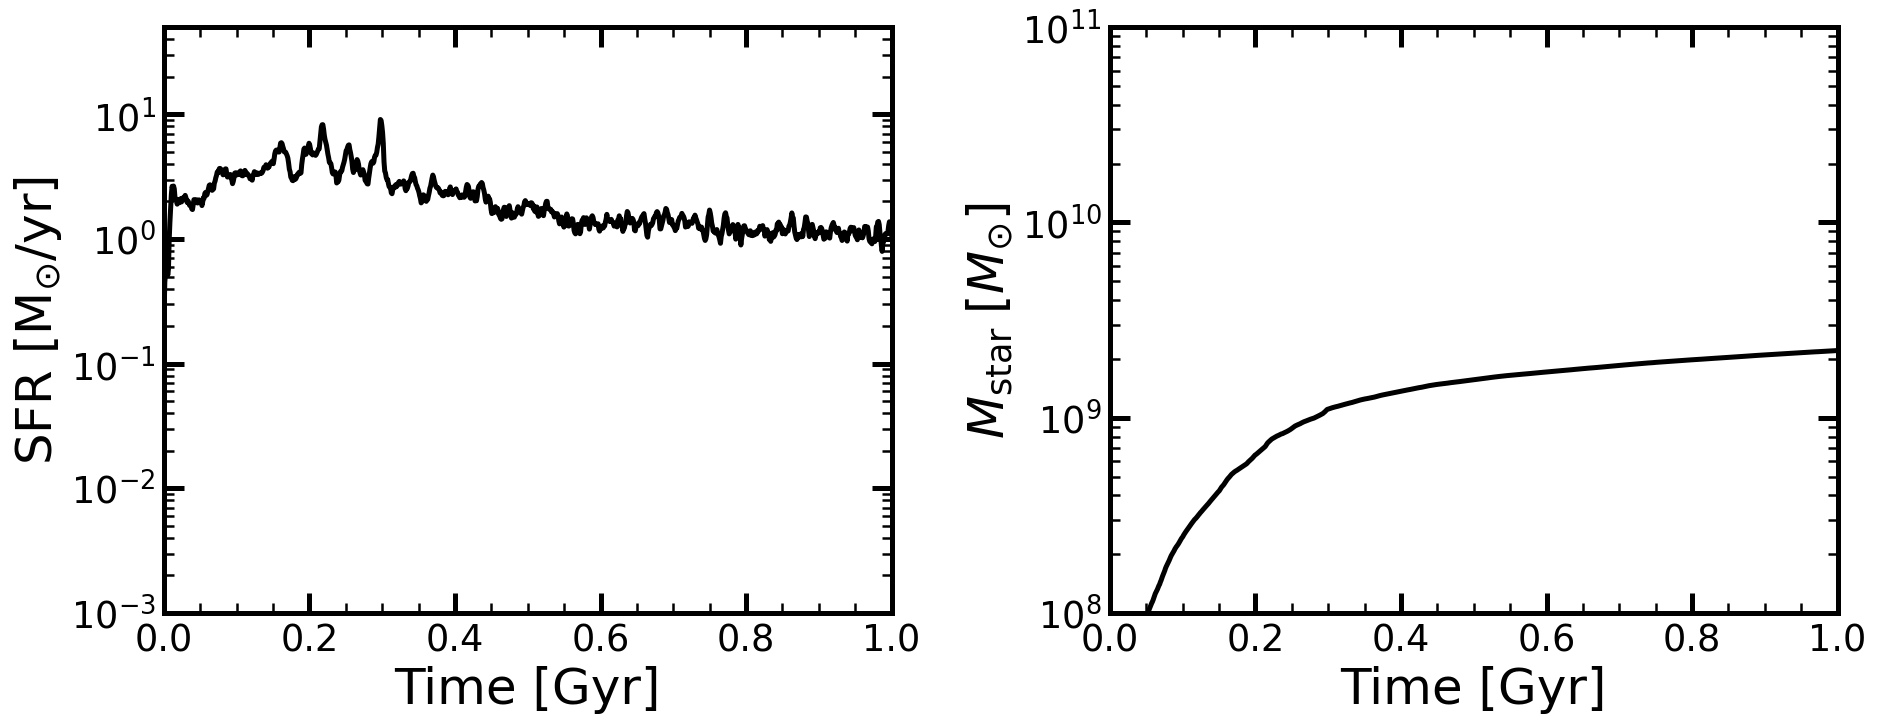

In [520]:
foutname = 'SFH.pdf'


for i,sp in enumerate(snaps):
    print(sp.sdir)
    name = sim_names[i]

    time, cum_SFH = snap_utils.get_SFH(sp, cum=1)

    stars = sp.loadpart(4)
    sft, m = stars.get_property('sft'), stars.get_property('M_form')
    time, sfr = math_utils.SFH(sft, m, sp, dt=0.005, cum=False)

    fig = Figure(2,ncols=2)

    time_lims = [0,1]

    fig.set_axis(0, 'time', 'sfr', x_lim=time_lims,x_log=False,twin_time_axis=False)
    fig.set_axis(1, 'time', 'M_star', x_lim=time_lims,x_log=False,twin_time_axis=False)


    fig.plot_line_data(0,time,sfr)

    fig.plot_line_data(1,time,cum_SFH)


    fig.save(plot_dir+name+'_'+str(sp.snum)+'_'+foutname)


#### D/Z and Mach Number Trends with Gas Density and Temperature

/N/project/choban_group/cchoban/size_evolution_tests/full_sim//init_dust_output/


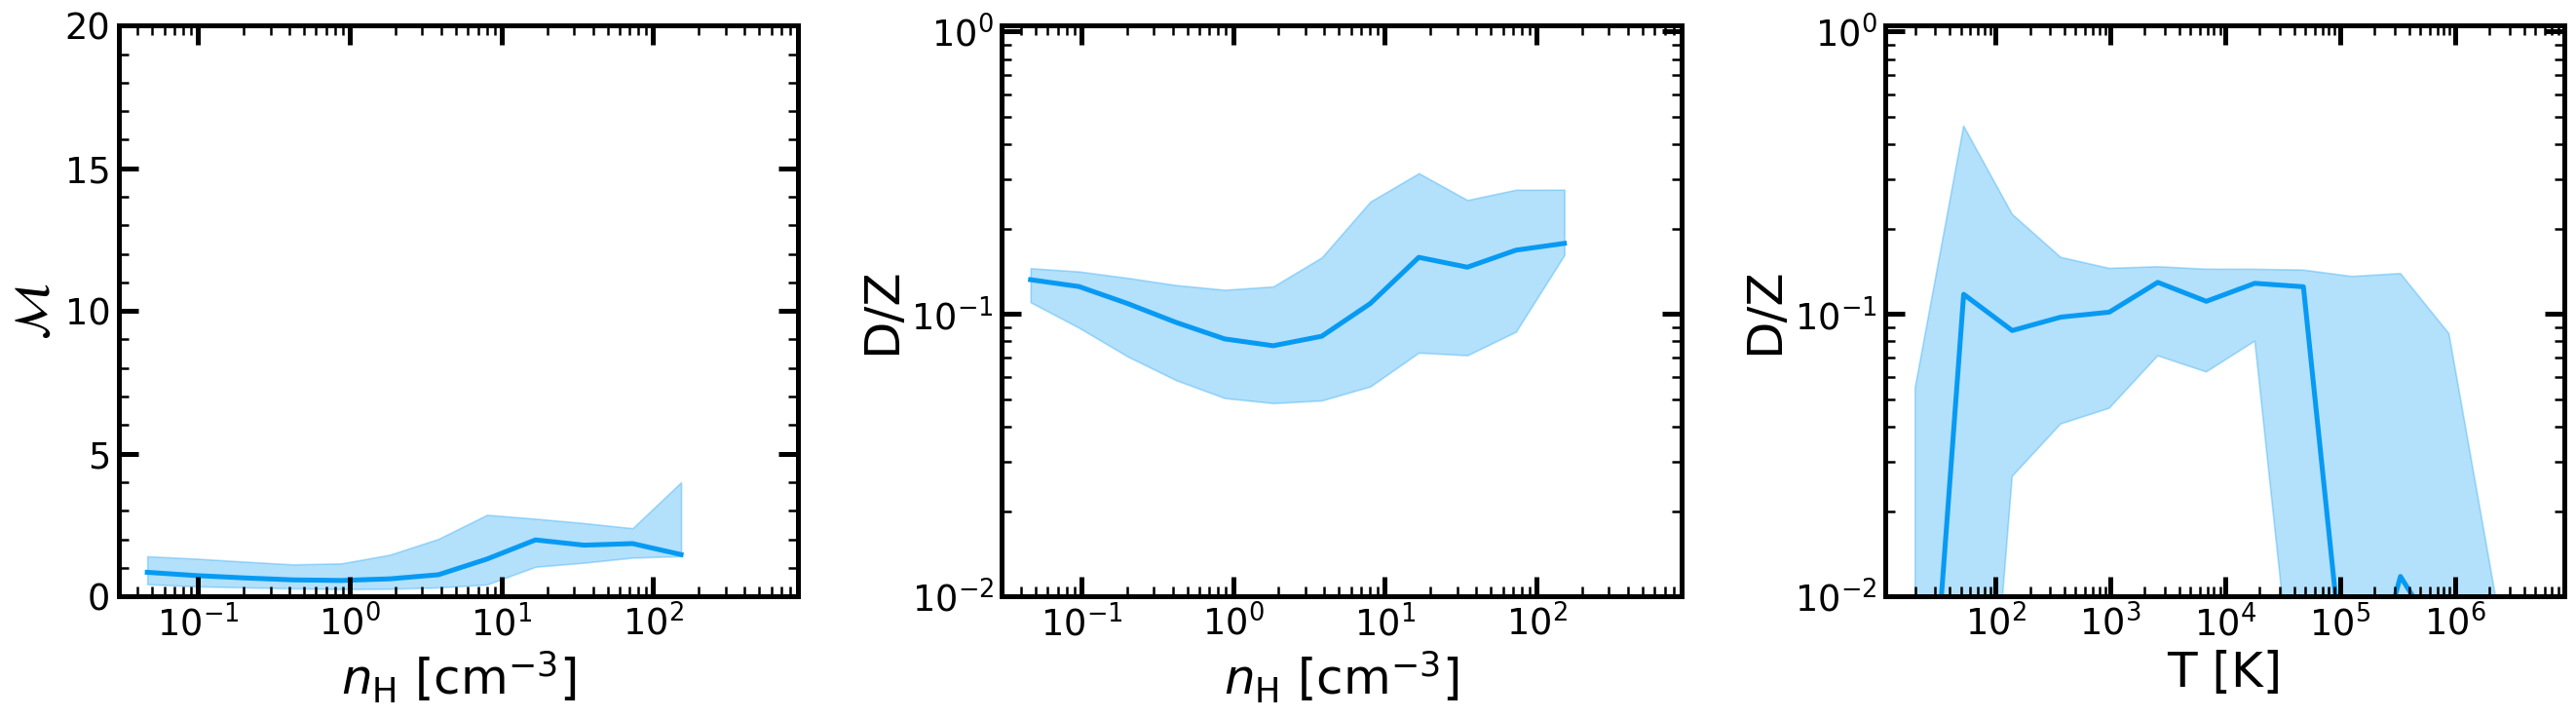

In [521]:


foutname = 'Mach_DZ.pdf'


for i,sp in enumerate(snaps):
    print(sp.sdir)
    name = sim_names[i]

    fig = Figure(3,ncols=3)
    num_snaps = len(snaps)
    num_specs = len(species)
    colors = config.LINE_COLORS[:num_snaps]
    colors = config.LINE_COLORS[:num_specs]
    linestyles = config.LINE_STYLES[:num_specs]
    linewidth = 2*config.BASE_LINEWIDTH
    init_depl = 0

    # number of points per bin
    # Any points_per_bin > 1 will follow the slopes in each bin so it can look odd
    points_per_bin=1

    fig.set_axis(0, 'nH', 'mach_number')
    fig.set_axis(1, 'nH', 'D/Z')
    fig.set_axis(2, 'T', 'D/Z')


    bin_nums=15

    bin_vals, mean_vals, std_vals = calc.calc_binned_property_vs_property('mach_number','nH',sp, bin_nums=bin_nums)
    fig.plot_line_data(0,bin_vals,mean_vals, color=colors[0],linestyle=linestyles[0])
    fig.plot_shaded_region(0,bin_vals,std_vals[:,0],std_vals[:,1], color=colors[0])

    bin_vals, mean_vals, std_vals = calc.calc_binned_property_vs_property('D/Z','nH',sp, bin_nums=bin_nums)
    fig.plot_line_data(1,bin_vals,mean_vals, color=colors[0],linestyle=linestyles[0])
    fig.plot_shaded_region(1,bin_vals,std_vals[:,0],std_vals[:,1], color=colors[0])

    bin_vals, mean_vals, std_vals = calc.calc_binned_property_vs_property('D/Z','T',sp, bin_nums=bin_nums)
    fig.plot_line_data(2,bin_vals,mean_vals, color=colors[0],linestyle=linestyles[0])
    fig.plot_shaded_region(2,bin_vals,std_vals[:,0],std_vals[:,1], color=colors[0])

    fig.save(plot_dir+name+'_'+str(sp.snum)+'_'+foutname)


#### Grain size distributions for each ISM phase

/N/project/choban_group/cchoban/size_evolution_tests/full_sim//init_dust_output/
Snapshot time: 1.0
Total dust mass sources: [5.7551105e+06 4.9276035e+03 7.9898915e+06 2.6043886e+05]


AttributeError: module 'crc_scripts.analytical_models.grain_size_evo' has no attribute 'get_grain_bin_mass'

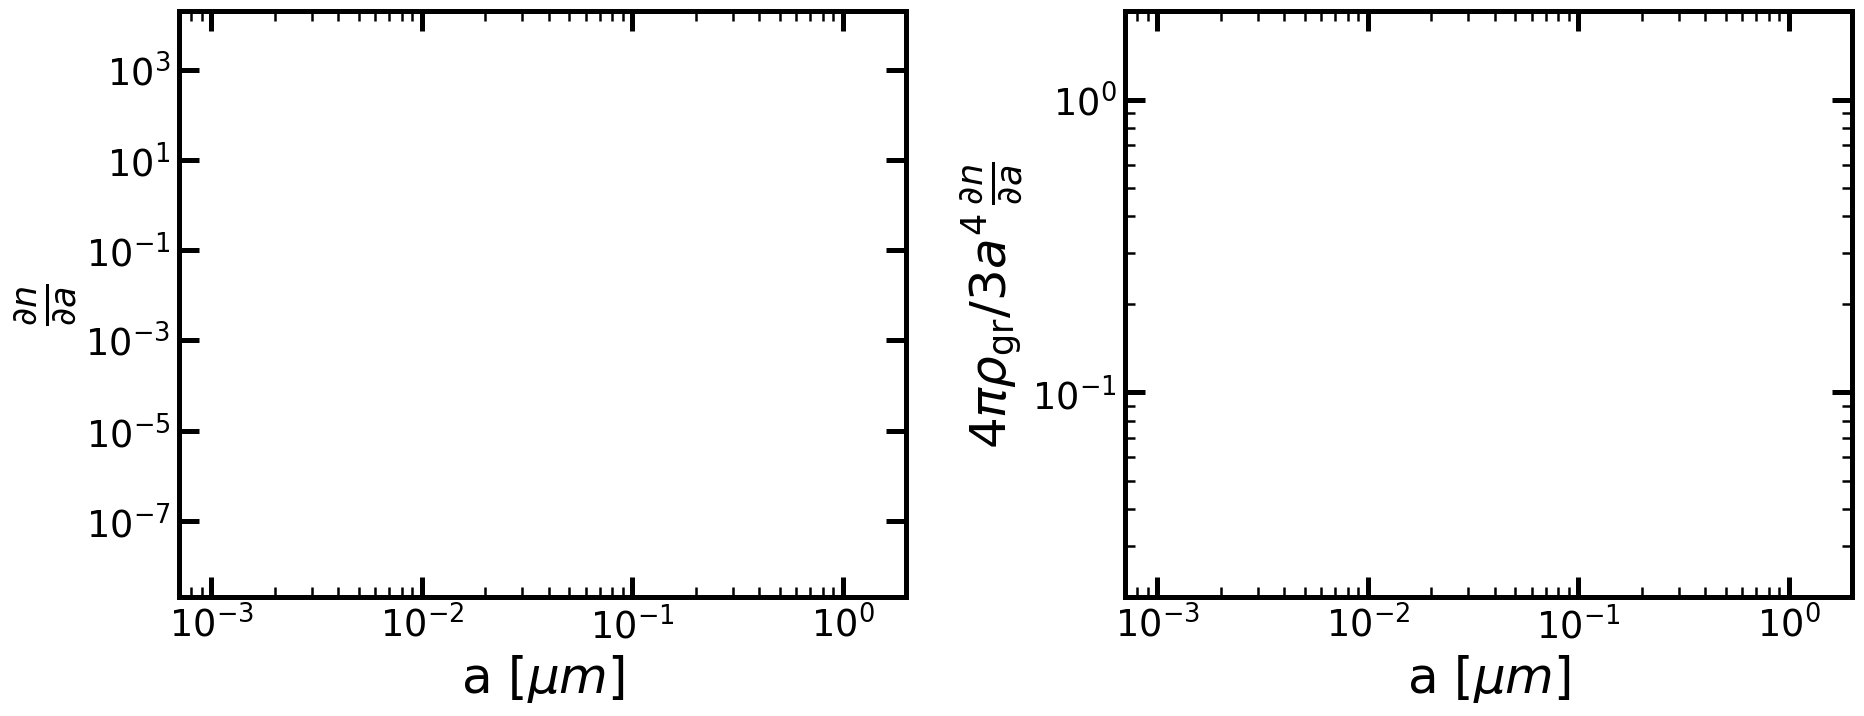

In [522]:

foutname = 'grain_size_dist_check.pdf'
species=['silicates','carbonaceous','iron']
spec_inds = [0,1,2]
ISM_phases = ['cold','warm','hot','coronal']





# number of points per bin
# Any points_per_bin > 1 will follow the slopes in each bin so it can look odd
points_per_bin=10




for k,sp in enumerate(snaps):
    print(sp.sdir)
    name = sim_names[k]
    G=sp.loadpart(0)

    fig = Figure(2,ncols=2)
    num_specs = len(species)
    num_phases = len(ISM_phases)
    colors = config.LINE_COLORS[:num_phases]
    linestyles = config.LINE_STYLES[:num_specs]
    linewidth = 2*config.BASE_LINEWIDTH
    fig.set_axis(0, 'grain_size', 'dn/da',y_lim=[2E-9,2E4])
    fig.set_axis(1, 'grain_size', 'dm/da',y_lim=[2E-2,2E-0])

    print("Snapshot time:",sp.time)
    print("Total dust mass sources:",np.sum(G.get_property('M_dust')[:,np.newaxis]*G.get_property('dust_source'),axis=0))


    # Debugging check for dust species masses
    for j, spec in enumerate(species):
        spec_ind = spec_inds[j]
        species_mass = G.get_property('M_spec')[:,spec_ind]*config.Msolar_to_g
        bin_masses = gse.get_grain_bin_mass(sp, species=spec)
        non_zero = species_mass>0
        # Maximum precentage difference between the sum of the bin masses and the total mass
        print(spec)

        print("\t Maximum percentage error:",np.max(np.abs(np.sum(bin_masses,axis=1)[non_zero]-species_mass[non_zero])/species_mass[non_zero]))
        print("\t Total species mass:",np.sum(species_mass/config.Msolar_to_g))
        print("\t Total bin mass:",np.sum(bin_masses/config.Msolar_to_g))  

    for i,phase in enumerate(ISM_phases):
        if i==0:
            y_offset = 3
            MRN_a_vals = np.logspace(-2,-1,10)
            dnda_norm = quad(gse.MRN_dnda, sp.Grain_Size_Min, sp.Grain_Size_Max)[0]
            dnda_vals = gse.MRN_dnda(MRN_a_vals)/dnda_norm * np.power(10,y_offset)
            fig.plot_line_data(0,MRN_a_vals,dnda_vals, color='xkcd:grey',linestyle='-')

            y_offset = 1
            dmda_norm = quad(gse.MRN_dmda, sp.Grain_Size_Min, sp.Grain_Size_Max)[0]
            dmdloga_vals = gse.MRN_dmda(MRN_a_vals)*MRN_a_vals/dmda_norm * np.power(10,y_offset)
            fig.plot_line_data(1,MRN_a_vals,dmdloga_vals, color='xkcd:grey',linestyle='-')
        
        mask = calc.get_particle_mask(0, sp, mask_criteria=phase)
        print("ISM phase:",phase)

        for j, spec in enumerate(species):
            
            dnda_bin_points, dnda_means, dnda_stds  =  gse.get_grain_size_dist(sp, species=spec, mask=mask, mass=False,points_per_bin=points_per_bin)
            dmdloga_bin_points, dmdloga_means, dmdloga_stds =  gse.get_grain_size_dist(sp, species=spec, mask=mask, mass=True,points_per_bin=points_per_bin)


            fig.plot_line_data(0,dnda_bin_points,dnda_means, color=colors[i],linestyle=linestyles[j])
            #fig.plot_shaded_region(0,dnda_bin_points,dnda_stds[:,0],dnda_stds[:,1], color=colors[i])

            # Lines used for the legend handles. Should not show up in plot
            fig.plot_line_data(0,[-1,-1],[-1,-1], color='xkcd:black',linestyle=linestyles[j],label=spec)

            fig.plot_line_data(1,dmdloga_bin_points,dmdloga_means, color=colors[i],linestyle=linestyles[j], label=phase)
            #fig.plot_shaded_region(1,dmdloga_bin_points,dmdloga_stds[:,0],dmdloga_stds[:,1], color=colors[i],linestyle=linestyles[j])

    fig.set_all_legends(max_cols=2,rescale_font=0.75)

    fig.save(plot_dir+name+'_'+str(sp.snum)+'_'+foutname)

/N/project/choban_group/cchoban/size_evolution_tests/full_sim//init_dust_output/
Snapshot time: 1.0
Total dust mass sources: [5.7551105e+06 4.9276035e+03 7.9898915e+06 2.6043886e+05]
silicates
	 Maximum percentage error: 4.216080088350457e-06
	 Total species mass: 7712888.0
	 Total bin mass: 7712887.547098647
carbonaceous
	 Maximum percentage error: 4.19439769426374e-06
	 Total species mass: 4050440.5
	 Total bin mass: 4050440.131945923
iron
	 Maximum percentage error: 4.110868322938888e-06
	 Total species mass: 2247385.8
	 Total bin mass: 2247385.68308457
ISM phase: all


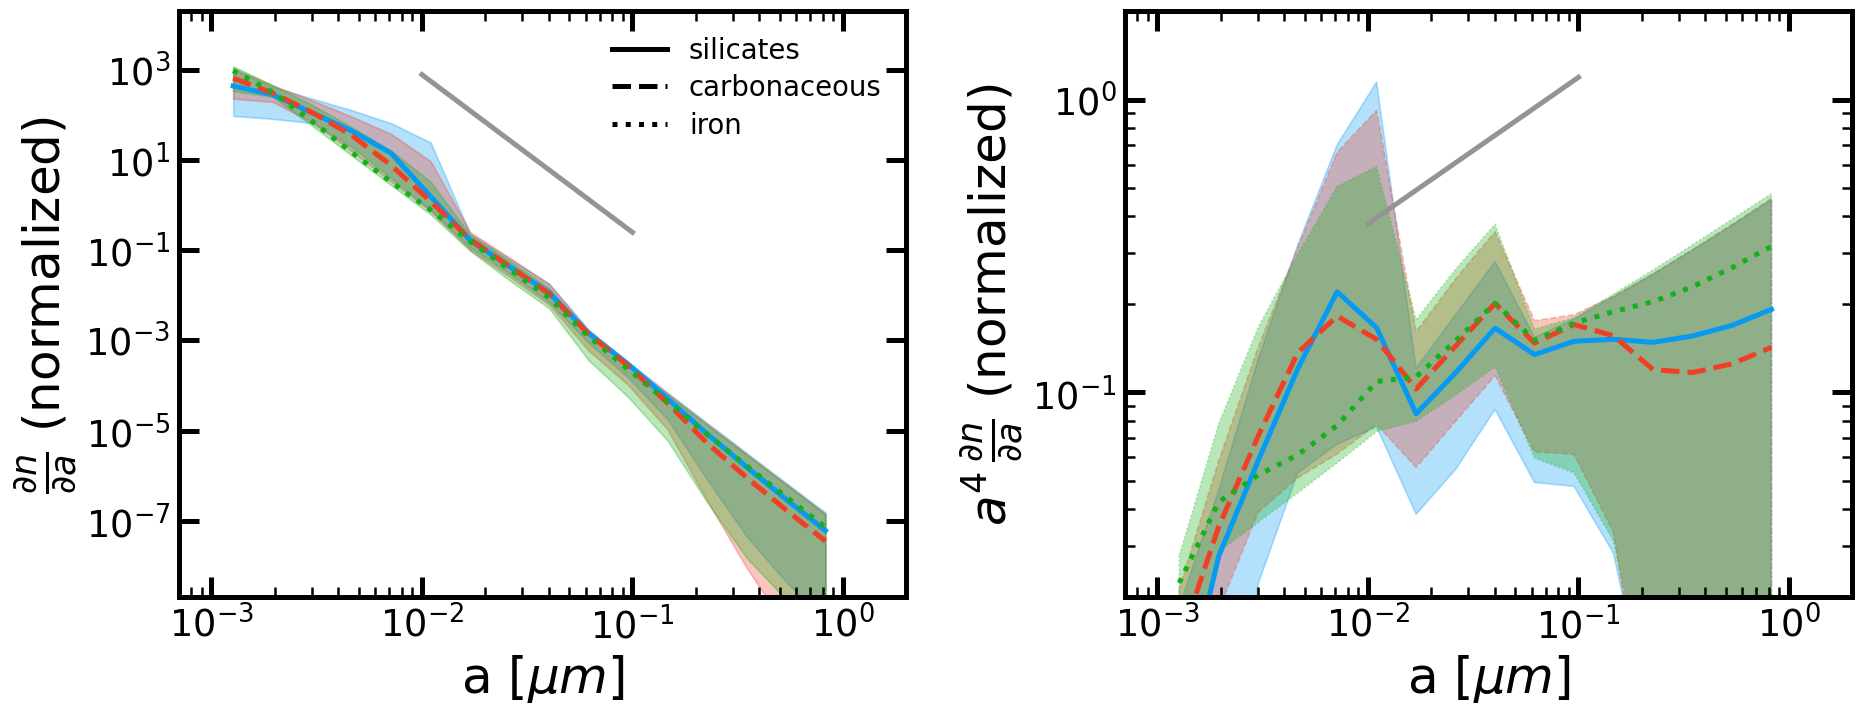

In [525]:

foutname = 'dnda_and_dmdloga_all_gas.pdf'


species=['silicates','carbonaceous','iron']
ISM_phases = ['all']



# number of points per bin
# Any points_per_bin > 1 will follow the slopes in each bin so it can look odd
points_per_bin=1




for k,sp in enumerate(snaps):
    print(sp.sdir)
    name = sim_names[k]
    G=sp.loadpart(0)

    fig = Figure(2,ncols=2)
    num_specs = len(species)
    num_phases = len(ISM_phases)
    colors = config.LINE_COLORS[:num_specs]
    linestyles = config.LINE_STYLES[:num_specs]
    linewidth = 2*config.BASE_LINEWIDTH
    fig.set_axis(0, 'grain_size', 'dn/da_norm',y_lim=[2E-9,2E4])
    fig.set_axis(1, 'grain_size', 'dm/dloga_norm',y_lim=[2E-2,2E-0])

    print("Snapshot time:",sp.time)
    print("Total dust mass sources:",np.sum(G.get_property('M_dust')[:,np.newaxis]*G.get_property('dust_source'),axis=0))


    # Debugging check for dust species masses
    for j, spec in enumerate(species):
        spec_ind = spec_inds[j]
        species_mass = G.get_property('M_spec')[:,spec_ind]*config.Msolar_to_g
        # bin_masses = grain_size_utils.get_grain_bin_mass(sp, species=spec)
        bin_masses = G.get_property('grain_bin_mass')[:,spec_ind]
        non_zero = species_mass>0   
        # Maximum percentage difference between the sum of the bin masses and the total mass
        print(spec)

        print("\t Maximum percentage error:",np.max(np.abs(np.sum(bin_masses,axis=1)[non_zero]-species_mass[non_zero])/species_mass[non_zero]))
        print("\t Total species mass:",np.sum(species_mass/config.Msolar_to_g))
        print("\t Total bin mass:",np.sum(bin_masses/config.Msolar_to_g))  

    for i,phase in enumerate(ISM_phases):
        if i==0:
            y_offset = 3
            MRN_a_vals = np.logspace(-2,-1,10)
            dnda_norm = quad(grain_size_utils.MRN_dnda, sp.Grain_Size_Min, sp.Grain_Size_Max)[0]
            dnda_vals = grain_size_utils.MRN_dnda(MRN_a_vals)/dnda_norm * np.power(10,y_offset)
            fig.plot_line_data(0,MRN_a_vals,dnda_vals, color='xkcd:grey',linestyle='-')

            y_offset = 0.4
            dmdloga_norm = quad(grain_size_utils.MRN_dmdloga, sp.Grain_Size_Min, sp.Grain_Size_Max)[0]
            dmdloga_vals = grain_size_utils.MRN_dmdloga(MRN_a_vals)/dmdloga_norm * np.power(10,y_offset)
            fig.plot_line_data(1,MRN_a_vals,dmdloga_vals, color='xkcd:grey',linestyle='-')
        
        mask = calc.get_particle_mask(0, sp, mask_criteria=phase)
        print("ISM phase:",phase)

        for j, spec in enumerate(species):
            
            grain_size_vals, percentile_dnda, percentile_dmdloga = \
                grain_size_utils.get_grain_size_distribution(sp, 
                                                             species=spec, 
                                                             mask=mask, 
                                                             points_per_bin=points_per_bin, 
                                                             std_percentiles = [16, 84])

            fig.plot_line_data(0,grain_size_vals,percentile_dnda[0], color=colors[j],linestyle=linestyles[j])
            fig.plot_shaded_region(0,grain_size_vals,percentile_dnda[1],percentile_dnda[2], color=colors[j])

            # Lines used for the legend handles. Should not show up in plot
            fig.plot_line_data(0,[-1,-1],[-1,-1], color='xkcd:black',linestyle=linestyles[j],label=spec)

            fig.plot_line_data(1,grain_size_vals,percentile_dmdloga[0], color=colors[j],linestyle=linestyles[j], label=spec)
            fig.plot_shaded_region(1,grain_size_vals,percentile_dmdloga[1],percentile_dmdloga[2], color=colors[j],linestyle=linestyles[j])

    fig.set_all_legends(max_cols=2,rescale_font=0.75)

    fig.save(plot_dir+name+'_'+str(sp.snum)+'_'+foutname)

/N/project/choban_group/cchoban/size_evolution_tests/full_sim//init_dust_output/
Snapshot time: 1.0
Total dust mass sources: [5.7551105e+06 4.9276035e+03 7.9898915e+06 2.6043886e+05]
ISM phase: all


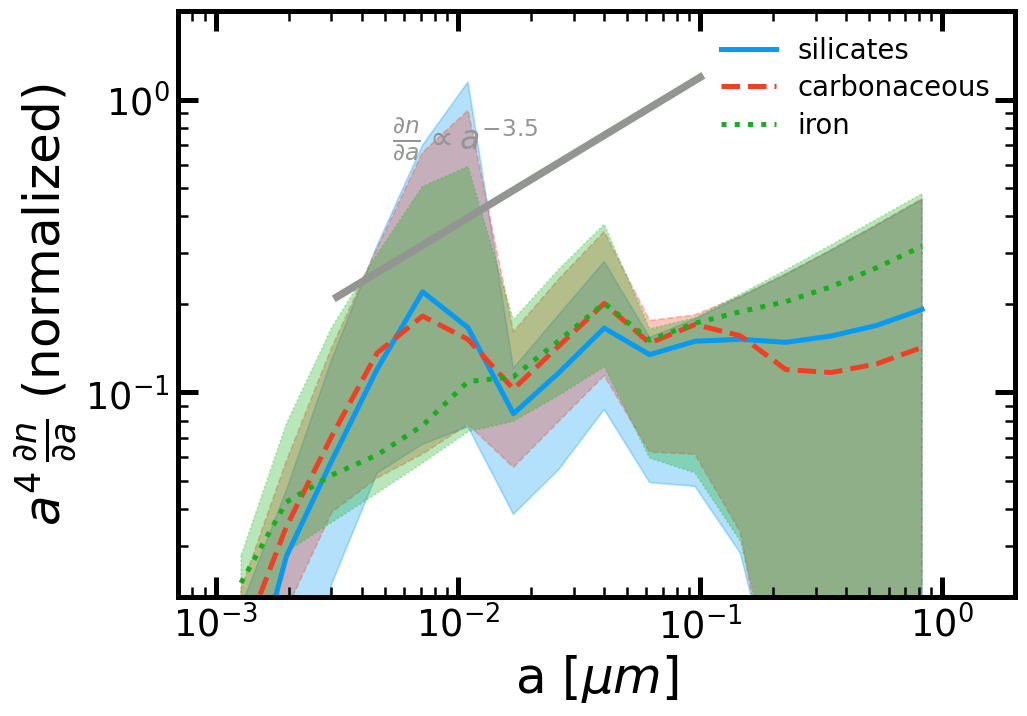

In [568]:

foutname = 'dmdloga_all_gas.pdf'


species=['silicates','carbonaceous','iron']
ISM_phases = ['all']



# number of points per bin
# Any points_per_bin > 1 will follow the slopes in each bin so it can look odd
points_per_bin=1




for k,sp in enumerate(snaps):
    print(sp.sdir)
    name = sim_names[k]
    G=sp.loadpart(0)

    fig = Figure(1)
    num_specs = len(species)
    num_phases = len(ISM_phases)
    colors = config.LINE_COLORS[:num_specs]
    linestyles = config.LINE_STYLES[:num_specs]
    linewidth = 2*config.BASE_LINEWIDTH
    fig.set_axis(0, 'grain_size', 'dm/dloga_norm',y_lim=[2E-2,2E-0])

    print("Snapshot time:",sp.time)
    print("Total dust mass sources:",np.sum(G.get_property('M_dust')[:,np.newaxis]*G.get_property('dust_source'),axis=0))

    for i,phase in enumerate(ISM_phases):
        if i==0:
            y_offset = 0.4
            MRN_a_vals = np.logspace(-2.5,-1,10)
            dmdloga_norm = quad(grain_size_utils.MRN_dmdloga, sp.Grain_Size_Min, sp.Grain_Size_Max)[0]
            dmdloga_vals = grain_size_utils.MRN_dmdloga(MRN_a_vals)/dmdloga_norm * np.power(10,y_offset)
            fig.plot_line_data(0,MRN_a_vals,dmdloga_vals, color='xkcd:grey',linestyle='-', linewidth=1.5*config.BASE_LINEWIDTH)
            x_coord = MRN_a_vals[len(MRN_a_vals)//2]
            y_coord = 1.1*dmdloga_vals[len(MRN_a_vals)//2]
            fig.add_text(0,x_coord,y_coord,r'$\frac{\partial n}{\partial a}\propto a^{-3.5}$',
                         ha='right', va='bottom',rescale_font=0.5, xycoords='data',color='xkcd:grey')
            for j, spec in enumerate(species):
                # Lines used for the legend handles. Should not show up in plot
                fig.plot_line_data(0,[-1,-1],[-1,-1], color='xkcd:black',linestyle=linestyles[j],label=spec)
        
        mask = calc.get_particle_mask(0, sp, mask_criteria=phase)
        print("ISM phase:",phase)

        for j, spec in enumerate(species):
            
            grain_size_vals, percentile_dnda, percentile_dmdloga = \
                grain_size_utils.get_grain_size_distribution(sp, 
                                                             species=spec, 
                                                             mask=mask, 
                                                             points_per_bin=points_per_bin, 
                                                             std_percentiles = [16, 84])

            fig.plot_line_data(0,grain_size_vals,percentile_dmdloga[0], color=colors[j],linestyle=linestyles[j], label=spec)
            fig.plot_shaded_region(0,grain_size_vals,percentile_dmdloga[1],percentile_dmdloga[2], color=colors[j],linestyle=linestyles[j])

    fig.set_all_legends(max_cols=2,rescale_font=0.75)

    fig.save(plot_dir+name+'_'+str(sp.snum)+'_'+foutname)

/N/project/choban_group/cchoban/size_evolution_tests/full_sim//init_dust_output/
Snapshot time: 1.0
Total dust mass sources: [5.7551105e+06 4.9276035e+03 7.9898915e+06 2.6043886e+05]
ISM phase: cold
ISM phase: warm
ISM phase: hot
ISM phase: coronal


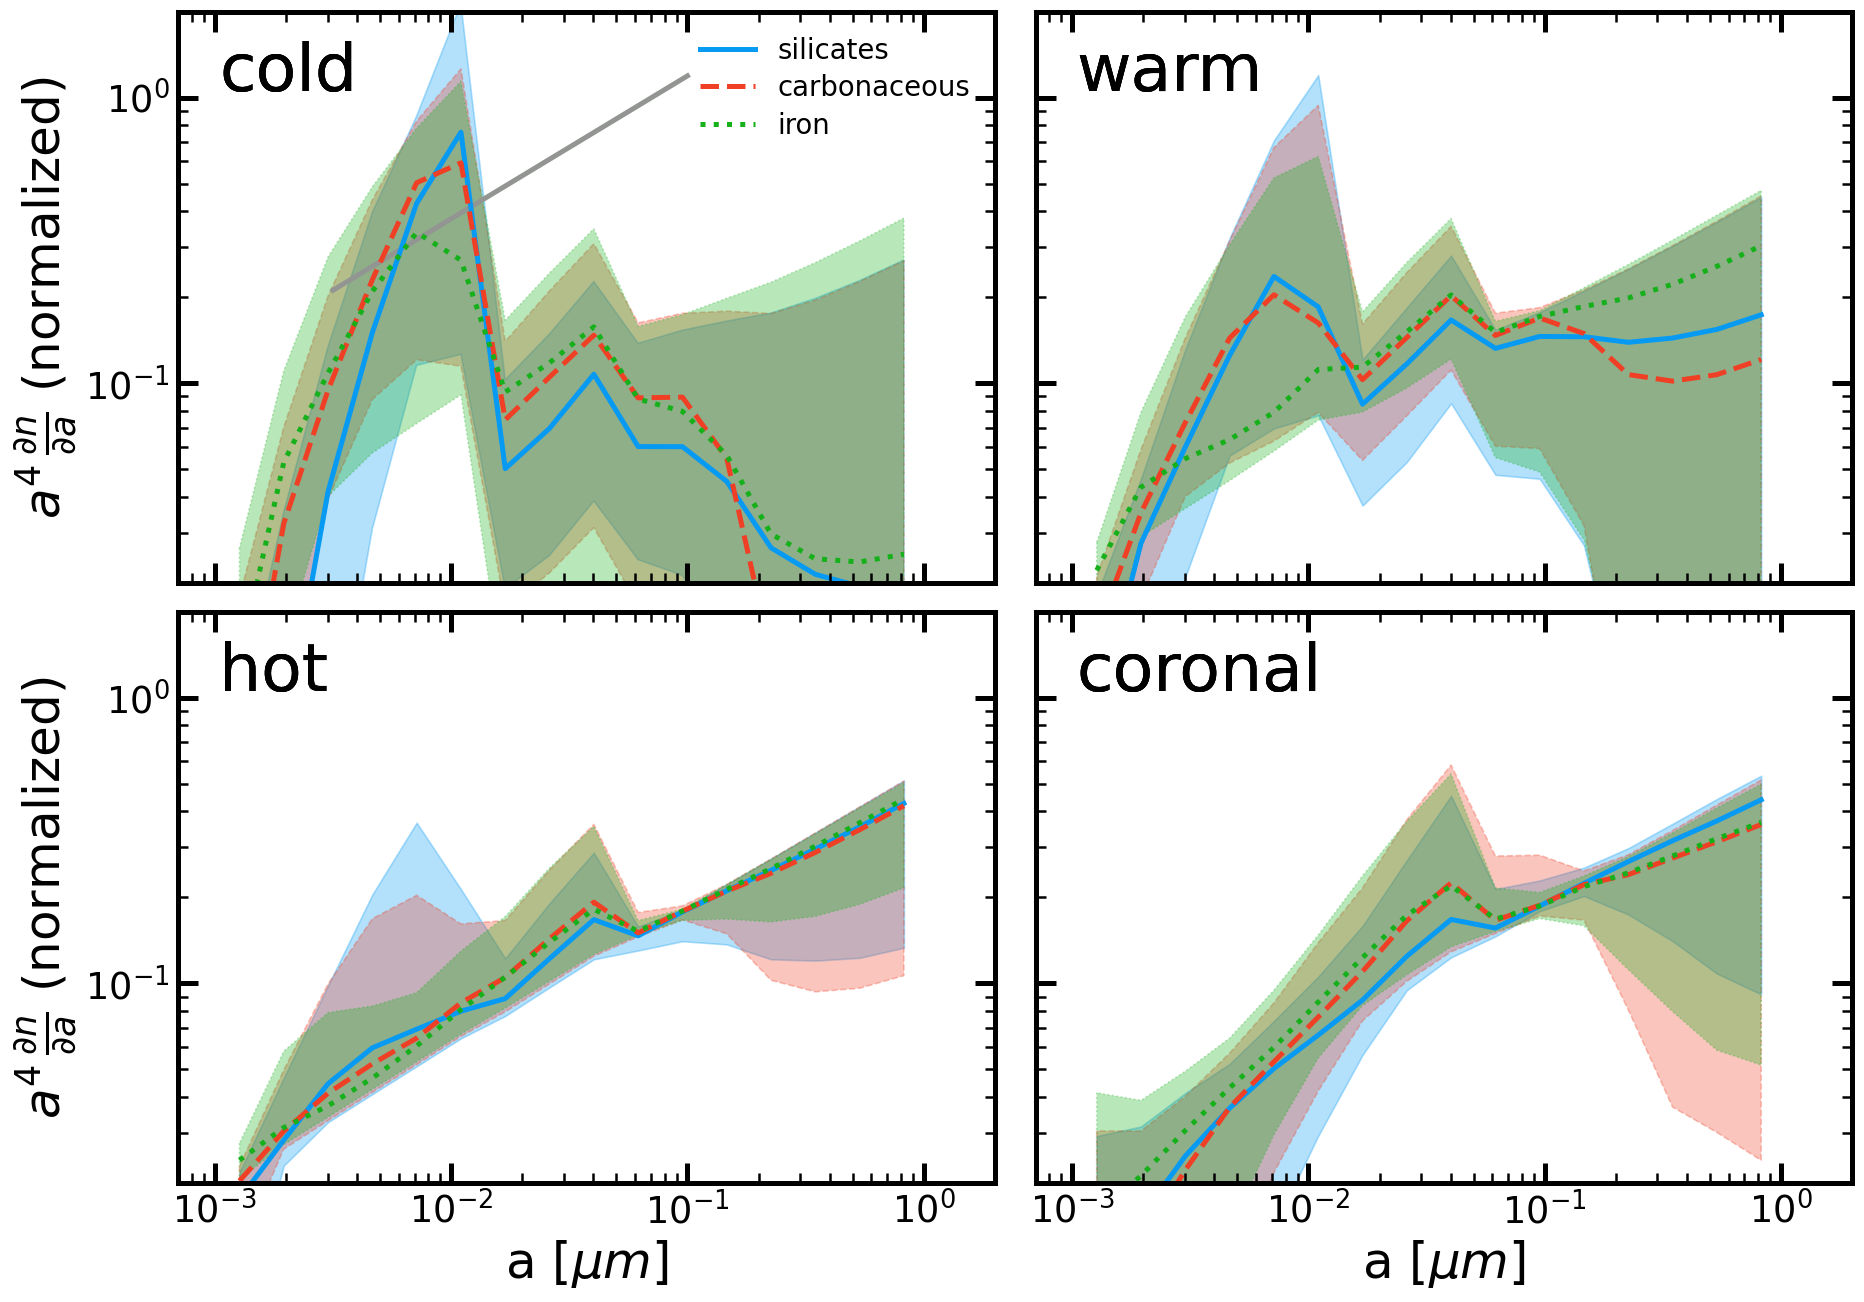

In [527]:

foutname = 'grain_dmdloga_ISM_phases.pdf'


species=['silicates','carbonaceous','iron']
ISM_phases = ['cold','warm','hot','coronal']


# number of points per bin
# Any points_per_bin > 1 will follow the slopes in each bin so it can look odd
points_per_bin=1




for k,sp in enumerate(snaps):
    print(sp.sdir)
    name = sim_names[k]
    G=sp.loadpart(0)
    num_specs = len(species)
    num_phases = len(ISM_phases)


    fig = Figure(num_phases,ncols=2, sharex='col',sharey='row')

    colors = config.LINE_COLORS[:num_specs]
    linestyles = config.LINE_STYLES[:num_specs]
    linewidth = 2*config.BASE_LINEWIDTH

    print("Snapshot time:",sp.time)
    print("Total dust mass sources:",np.sum(G.get_property('M_dust')[:,np.newaxis]*G.get_property('dust_source'),axis=0))


    for i,phase in enumerate(ISM_phases):
        mask = calc.get_particle_mask(0, sp, mask_criteria=phase)
        print("ISM phase:",phase)

        fig.set_axis(i, 'grain_size', 'dm/dloga_norm',y_lim=[2E-2,2E-0])

        if i==0:
            y_offset = 0.4
            dmdloga_norm = quad(grain_size_utils.MRN_dmdloga, sp.Grain_Size_Min, sp.Grain_Size_Max)[0]
            dmdloga_vals = grain_size_utils.MRN_dmdloga(MRN_a_vals)/dmdloga_norm * np.power(10,y_offset)
            fig.plot_line_data(i,MRN_a_vals,dmdloga_vals, color='xkcd:grey',linestyle='-')
            for j, spec in enumerate(species):
                # Lines used for the legend handles. Should not show up in plot
                fig.plot_line_data(0,[-1,-1],[-1,-1], color='xkcd:black',linestyle=linestyles[j],label=spec)
        
 
        for j, spec in enumerate(species):
            
            grain_size_vals, percentile_dnda, percentile_dmdloga = \
                grain_size_utils.get_grain_size_distribution(sp, 
                                                             species=spec, 
                                                             mask=mask, 
                                                             points_per_bin=points_per_bin, 
                                                             std_percentiles = [16, 84])


            fig.plot_line_data(i,grain_size_vals,percentile_dmdloga[0], color=colors[j],linestyle=linestyles[j], label=spec)
            fig.plot_shaded_region(i,grain_size_vals,percentile_dmdloga[1],percentile_dmdloga[2], color=colors[j],linestyle=linestyles[j])
            fig.add_text(i,0.05,0.95,phase,ha='left', va='top',)

    fig.set_all_legends(max_cols=2,rescale_font=0.75)

    fig.save(plot_dir+name+'_'+str(sp.snum)+'_'+foutname)

### Extinction Curves

/N/project/choban_group/cchoban/size_evolution_tests/full_sim//init_dust_output/
Snapshot time: 1.0
Total dust mass sources: [5.7551105e+06 4.9276035e+03 7.9898915e+06 2.6043886e+05]
ISM phase: all


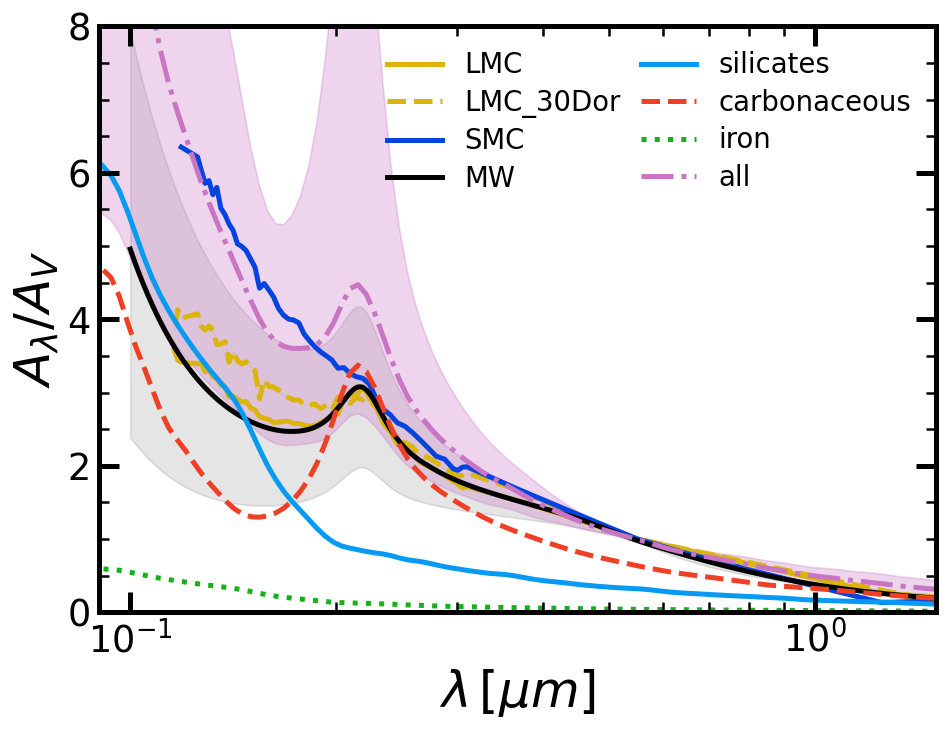

In [574]:

foutname = 'median_extinction_curve.pdf'
ISM_phases = ['all']
species=['silicates','carbonaceous', 'iron','all']



# Number of subsamples for each grain size bin when calculating the extinction curve
# If you set this to 1, it will use the center value of the bin
# Values > 1 are only needed for simulations with a small number of grain size bins
bin_subsamples = 1 

for k,sp in enumerate(snaps):
    if k!=0: continue
    print(sp.sdir)
    name = sim_names[k]
    G=sp.loadpart(0)

    fig = Figure(1)
    num_specs = len(species)
    num_phases = len(ISM_phases)
    colors = config.LINE_COLORS[:num_specs]
    linestyles = config.LINE_STYLES[:num_specs]
    linewidth = 2*config.BASE_LINEWIDTH
    fig.set_axis(0, 'lambda', 'A_lambda', x_lim=[0.09,1.5],y_lim=[0,8])

    print("Snapshot time:",sp.time)
    print("Total dust mass sources:",np.sum(G.get_property('M_dust')[:,np.newaxis]*G.get_property('dust_source'),axis=0))


    # Plot observed extinction curves
    galaxies = ['LMC','LMC_30Dor','SMC','MW',]
    obs_colors = ['xkcd:gold','xkcd:gold','xkcd:blue','xkcd:black']
    obs_linestyles = ['-','--','-','-']
    subsamples = [2,2,2,0]
    for i, galaxy in enumerate(galaxies):
        wavelengths, A_lambda_percentiles = obs.Salim20_compiled_extinction_curve(galaxy, subsample=subsamples[i])
        fig.plot_line_data(0,wavelengths,A_lambda_percentiles[0], y_std=A_lambda_percentiles[[1,2]].T, 
                            color=obs_colors[i],linestyle=obs_linestyles[i], label = galaxy, std_kwargs={'alpha':0.1})

    for i,phase in enumerate(ISM_phases):

        mask = calc.get_particle_mask(0, sp, mask_criteria=phase)
        print("ISM phase:",phase)

        for j, spec in enumerate(species):

            wavelength_points, A_lambda_percentiles = grain_size_utils.calculate_extinction_curve(sp,species=spec, mask=mask, std_percentiles = [16, 84], bin_subsamples=bin_subsamples)

            if spec == 'all':
                fig.plot_line_data(0,wavelength_points,A_lambda_percentiles[0], y_std=A_lambda_percentiles[[1,2]].T, color=colors[j],linestyle=linestyles[j], label = spec)
            else:
                fig.plot_line_data(0,wavelength_points,A_lambda_percentiles[0], color=colors[j],linestyle=linestyles[j], label = spec)


    fig.set_all_legends(max_cols=2,rescale_font=0.75)

    fig.save(plot_dir+name+'_'+str(sp.snum)+'_'+foutname)

/N/project/choban_group/cchoban/size_evolution_tests/full_sim/FIRE3_all_output/
Snapshot time: 1.0000000000000007
Total dust mass sources: [1.2929185e+06 5.2682373e+03 1.3864093e+07 2.7662875e+05]
ISM phase: cold
ISM phase: warm
ISM phase: hot
ISM phase: coronal


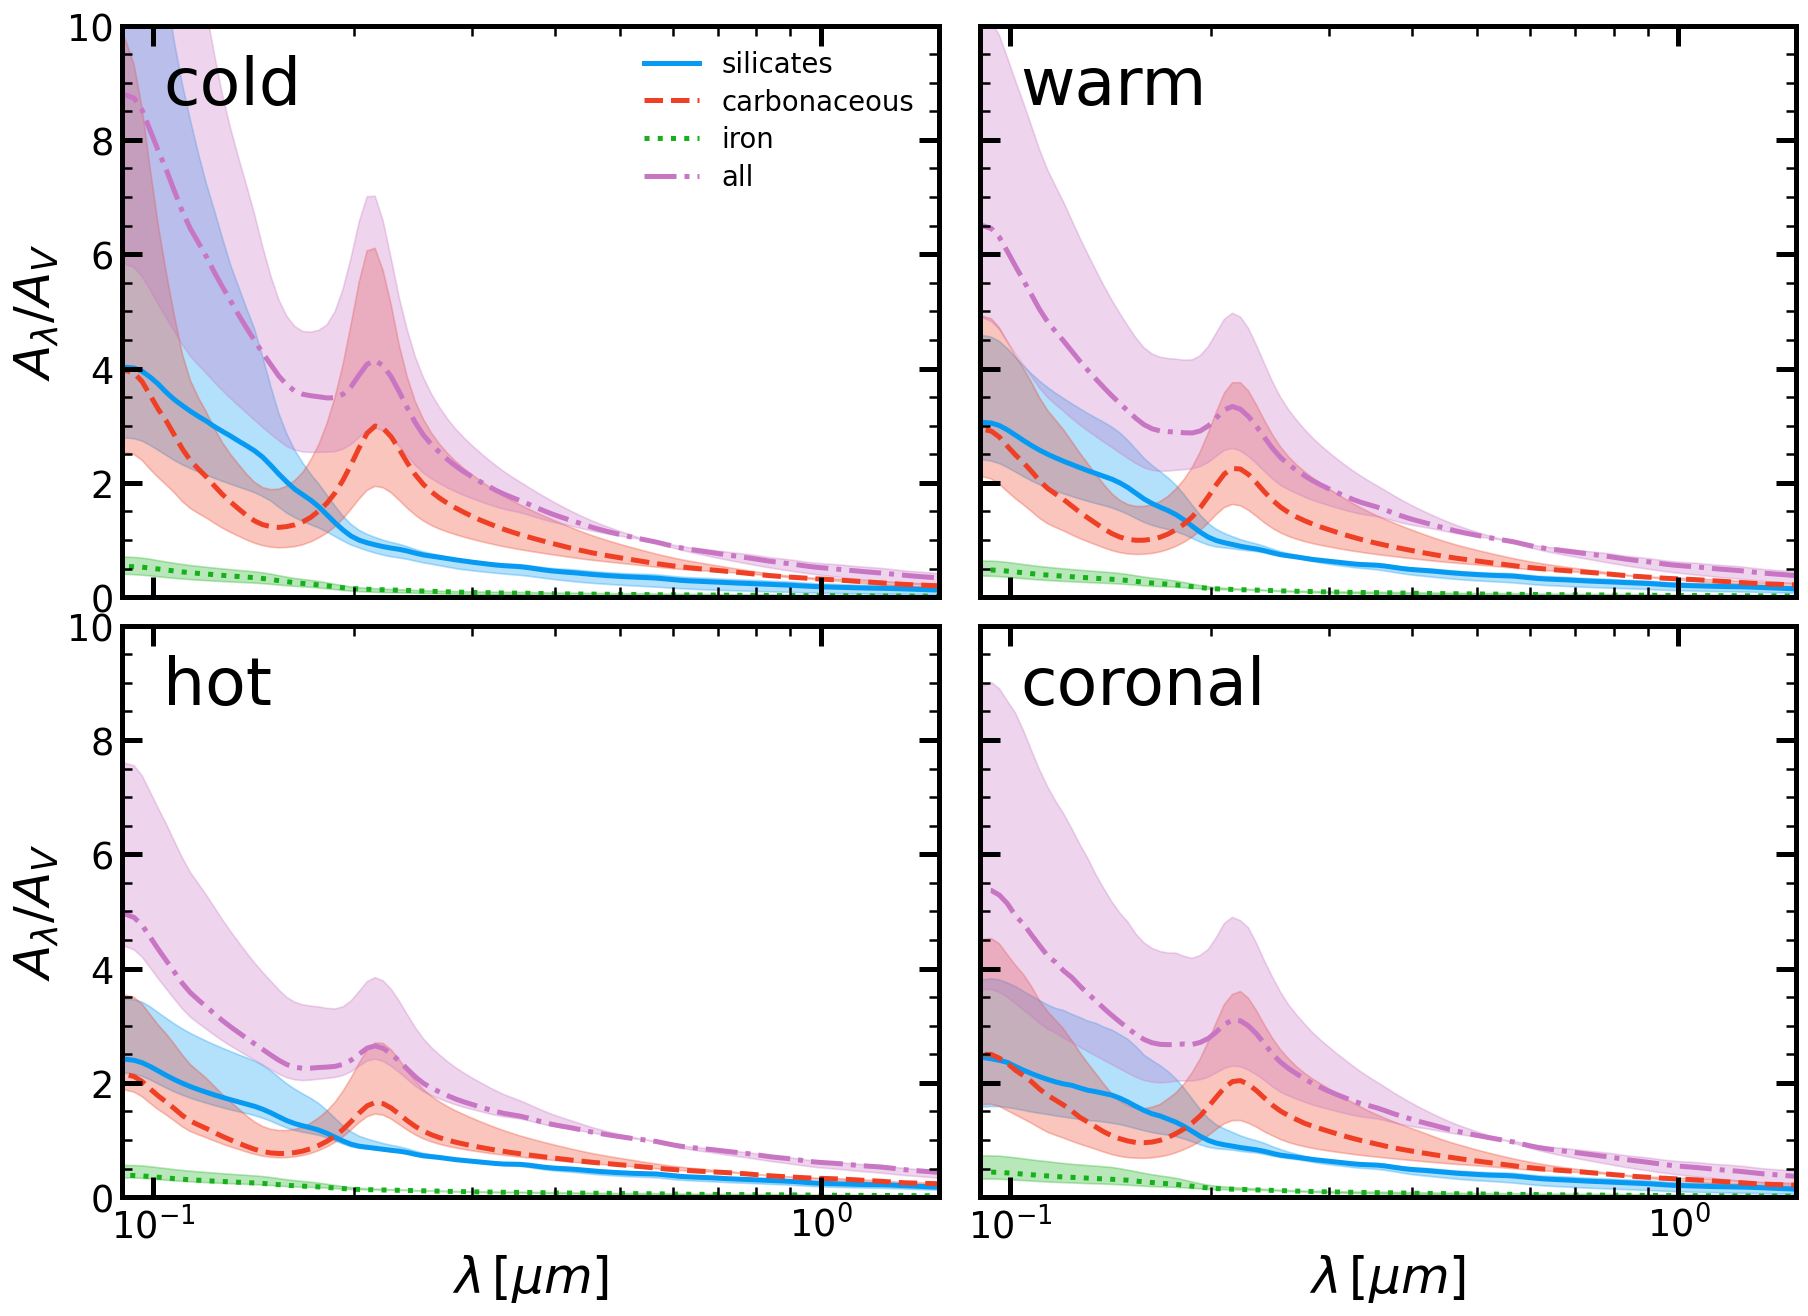

In [307]:

foutname = 'median_extinction_curve_gas_phases.pdf'
ISM_phases = ['cold','warm','hot','coronal']
species=['silicates','carbonaceous', 'iron','all']



# Number of subsamples for each grain size bin when calculating the extinction curve
# If you set this to 1, it will use the center value of the bin
# Values > 1 are only needed for simulations with a small number of grain size bins
bin_subsamples = 1 

for k,sp in enumerate(snaps):
    if k!=0: continue
    print(sp.sdir)
    name = sim_names[k]
    G=sp.loadpart(0)

    num_specs = len(species)
    num_phases = len(ISM_phases)

    colors = config.LINE_COLORS[:num_specs]
    linestyles = config.LINE_STYLES[:num_specs]
    linewidth = 2*config.BASE_LINEWIDTH

    fig = Figure(num_phases, ncols=2, sharex='col',sharey='row')
    

    print("Snapshot time:",sp.time)
    print("Total dust mass sources:",np.sum(G.get_property('M_dust')[:,np.newaxis]*G.get_property('dust_source'),axis=0))


    for i,phase in enumerate(ISM_phases):
        mask = calc.get_particle_mask(0, sp, mask_criteria=phase)
        print("ISM phase:",phase)
        fig.set_axis(i, 'lambda', 'A_lambda', x_lim=[0.09,1.5])

        for j, spec in enumerate(species):

            wavelength_points, A_lambda_percentiles = grain_size_utils.calculate_extinction_curve(sp,species=spec, mask=mask, std_percentiles = [16, 84], bin_subsamples=1)

            fig.plot_line_data(i,wavelength_points,A_lambda_percentiles[0], y_std=A_lambda_percentiles[[1,2]].T, color=colors[j],linestyle=linestyles[j], label = spec)
            
        fig.add_text(i,0.05,0.95,phase,ha='left', va='top',)

fig.set_all_legends(max_cols=2,rescale_font=0.75)

    fig.save(plot_dir+name+'_'+str(sp.snum)+'_'+foutname)

/N/project/choban_group/cchoban/size_evolution_tests/full_sim/FIRE3_all_output/
Snapshot time: 1.0000000000000007
Total dust mass sources: [1.2929185e+06 5.2682373e+03 1.3864093e+07 2.7662875e+05]
ISM phase: cold
ISM phase: warm
ISM phase: hot
ISM phase: coronal


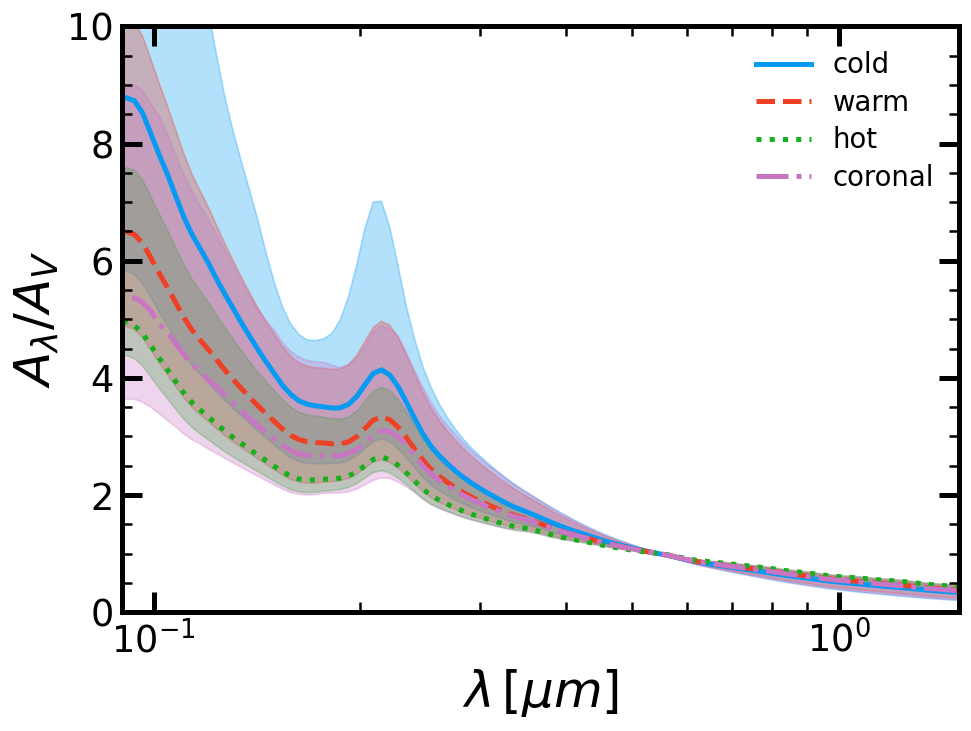

In [289]:
foutname = plot_dir + 'median_extinction_gas_phases.pdf'

ISM_phases = ['cold','warm','hot','coronal']
spec='all'


# Number of subsamples for each grain size bin when calculating the extinction curve
# If you set this to 1, it will use the center value of the bin
# Values > 1 are only needed for simulations with a small number of grain size bins
bin_subsamples = 1 

for k,sp in enumerate(snaps):
    if k!=0: continue
    print(sp.sdir)
    name = sim_names[k]
    G=sp.loadpart(0)

    fig = Figure(1)
    num_specs = len(species)
    num_phases = len(ISM_phases)
    colors = config.LINE_COLORS[:num_specs]
    linestyles = config.LINE_STYLES[:num_specs]
    linewidth = 2*config.BASE_LINEWIDTH
    fig.set_axis(0, 'lambda', 'A_lambda', x_lim=[0.09,1.5])

    print("Snapshot time:",sp.time)
    print("Total dust mass sources:",np.sum(G.get_property('M_dust')[:,np.newaxis]*G.get_property('dust_source'),axis=0))


    for i,phase in enumerate(ISM_phases):
        mask = calc.get_particle_mask(0, sp, mask_criteria=phase)
        print("ISM phase:",phase)

        wavelength_points, A_lambda_percentiles = grain_size_utils.calculate_extinction_curve(sp,species=spec, mask=mask, std_percentiles = [16, 84], bin_subsamples=1)

        fig.plot_line_data(0,wavelength_points,A_lambda_percentiles[0], y_std=A_lambda_percentiles[[1,2]].T, color=colors[i],linestyle=linestyles[i], label = phase)

fig.set_all_legends(max_cols=2,rescale_font=0.75)
fig.save(foutname)

# Mock Hubble Images

## Create Reduced Snapshot Data for SKIRT

In [ ]:
main_dirc = '/N/project/choban_group/cchoban/size_evolution_tests/full_sim/'

# Snapshot to check
snap_num = 0


snap_dirs = [main_dirc+'/init_dust_output/',
             #main_dirc+'/FIRE3_all_output/',
             #main_dirc+'/FIRE2_all_output/',
             ]

# Shorthand names for each sim used in plot legends and file names
sim_names = ['new',
             #'FIRE3_all',
             #'FIRE2_all'
             ]


snap_num = 200

snaps = []


for snap_dir in snap_dirs:
    create_SKIRT_particle_files(snap_dir, snap_num, output_dir, import_dust=False, import_gas_hsml=True, use_halo_file=False, file_prefix=None)

# Time Evolution

## Reduce the data (This takes a long time)
Specify simulations and reduce snapshot data for time evolution of various properties.

In [450]:
main_dirc = '/N/project/choban_group/cchoban/size_evolution_tests/full_sim/'

# Snapshot to load
snap_nums = np.arange(0,200,1)


snap_dirs = [main_dirc+'/init_dust_output/',
             ]

for snap_dir in snap_dirs:
    time_evo_buffer = MultiSnapDataIO(snap_dir, snap_nums)
    time_evo_buffer.set_halo(mode='dense_gas', rout=20, kpc=True,)
    time_evo_buffer.load(increment=2,overwrite=False, verbose=True)

Reduced data already exists for the given halo setup so loading that first....
Loading snap 124 ...
Centering galaxy on median position of gas particles with nH>10 cm^-3.
Took 100.488 secs to load this snap:
Loading snap 125 ...
Centering galaxy on median position of gas particles with nH>10 cm^-3.
Took 104.617 secs to load this snap:
Loading snap 126 ...
Centering galaxy on median position of gas particles with nH>10 cm^-3.
Took 106.894 secs to load this snap:
Loading snap 127 ...
Centering galaxy on median position of gas particles with nH>10 cm^-3.
Took 100.868 secs to load this snap:
Loading snap 128 ...
Centering galaxy on median position of gas particles with nH>10 cm^-3.
Took 103.132 secs to load this snap:
Loading snap 129 ...
Centering galaxy on median position of gas particles with nH>10 cm^-3.
Took 106.792 secs to load this snap:
Loading snap 130 ...
Centering galaxy on median position of gas particles with nH>10 cm^-3.
Took 94.513 secs to load this snap:
Loading snap 131 ..

## Plotting Reduced Data

Reduced data already exists for the given halo setup so loading that first....
All done reducing snapshot data. Please clap.....


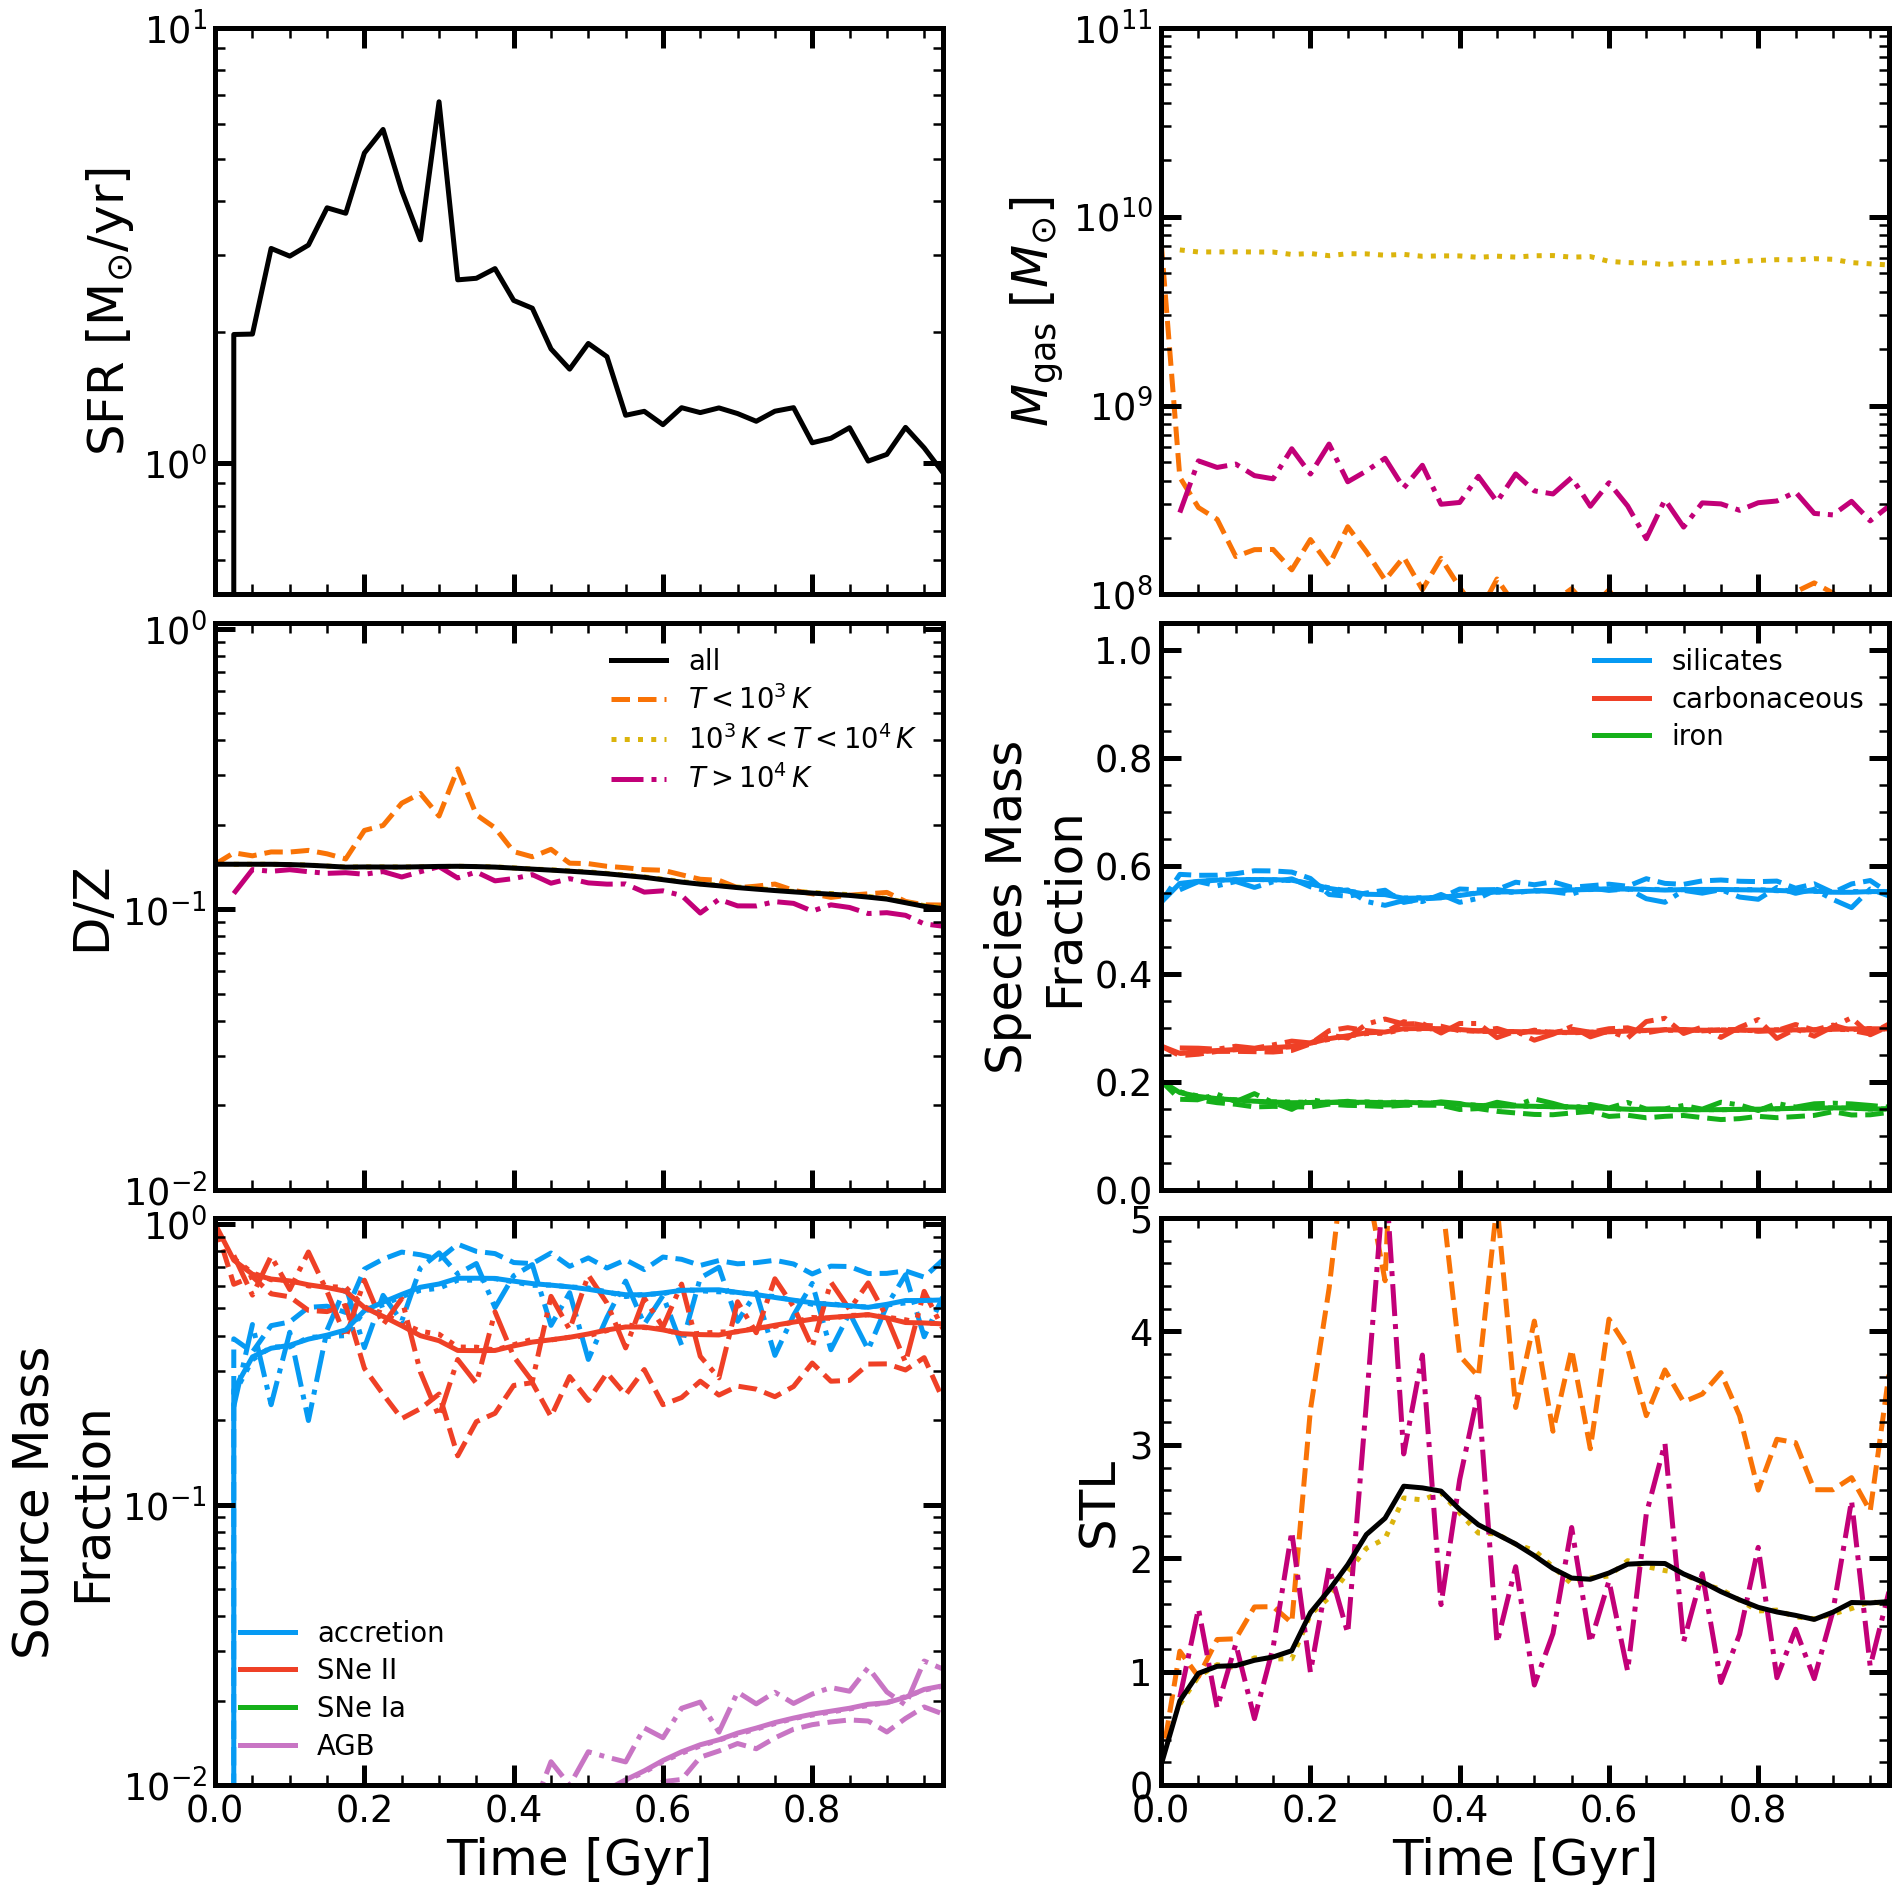

In [501]:

foutname = 'time_evolution.pdf'

linestyles = config.LINE_STYLES
secondary_colors = config.LINE_COLORS
primary_colors = config.MARKER_COLORS

# Which snapshots you want to plot. Sometimes you dont want to plot all snapshots since its noisy and so want to subsample.
snap_nums = np.arange(0,200,5)

for snap_dir in snap_dirs:
    time_evo_buffer = MultiSnapDataIO(snap_dir, snap_nums)
    time_evo_buffer.set_halo(mode='dense_gas', rout=20, kpc=True,)
    time_evo_buffer.load(increment=2,overwrite=False, verbose=True)

    time = time_evo_buffer.get_data('time', snap_nums = snap_nums)
    time_limits = [np.min(time),np.max(time)]

    fig = Figure(6, sharex='col',ncols=2)



    i=0
    subsamples = ['cold','warm','hot']
    sample_labels = [r'$T < 10^3 \, K$',r'$10^3 \, K < T < 10^4 \, K$',r'$T > 10^4 \, K$']


    sfr_10Myr = time_evo_buffer.get_data('sfr_10Myr', subsample='all', snap_nums = snap_nums)
    y_lim = [0.5,10]
    fig.set_axis(i, 'time', 'sfr', x_lim=time_limits,x_log=False, y_lim=y_lim, twin_time_axis=False)
    fig.plot_line_data(i,time,sfr_10Myr, color='xkcd:black',linestyle='-')
    i+=1

    y_lim=None
    fig.set_axis(i, 'time', 'M_gas', x_lim=time_limits,x_log=False, y_lim=y_lim, twin_time_axis=False)
    for j, subsample in enumerate(subsamples):
        M_gas = time_evo_buffer.get_data('M_gas', subsample=subsample, snap_nums = snap_nums)
        fig.plot_line_data(i,time,M_gas, color=primary_colors[j],linestyle=linestyles[j+1], label=subsample, zorder=1)

    i+=1


    fig.set_axis(i, 'time', 'D/Z', x_lim=time_limits,x_log=False,twin_time_axis=False)
    subsample='all'
    DZ = time_evo_buffer.get_data('D/Z', subsample=subsample, snap_nums = snap_nums)
    fig.plot_line_data(i,time,DZ, color='xkcd:black',linestyle=linestyles[0],label=subsample)
    for j, subsample in enumerate(subsamples): 
        DZ = time_evo_buffer.get_data('D/Z', subsample=subsample, snap_nums = snap_nums)
        fig.plot_line_data(i,time,DZ, color=primary_colors[j],linestyle=linestyles[j+1], label=sample_labels[j], zorder=1)

    fig.set_axis_legend(i,loc='upper right',rescale_font=0.75,ncol=1)

    i+=1

    M_dust_total = time_evo_buffer.get_data('M_dust', subsample='all', snap_nums = snap_nums)
    M_dust_sil = time_evo_buffer.get_data('M_sil', subsample='all', snap_nums = snap_nums)
    M_dust_carb = time_evo_buffer.get_data('M_carb', subsample='all', snap_nums = snap_nums)
    M_dust_iron = time_evo_buffer.get_data('M_iron', subsample='all', snap_nums = snap_nums)

    fig.set_axis(i, 'time', 'spec_frac', x_lim=time_limits,x_log=False,twin_time_axis=False)
    fig.plot_line_data(i,time,M_dust_sil/M_dust_total, color=secondary_colors[0],linestyle='-', label='silicates')
    fig.plot_line_data(i,time,M_dust_carb/M_dust_total, color=secondary_colors[1],linestyle='-', label='carbonaceous')
    fig.plot_line_data(i,time,M_dust_iron/M_dust_total, color=secondary_colors[2],linestyle='-', label='iron')
    fig.set_axis_legend(i,loc='upper right',rescale_font=0.75,ncol=1)

    for j, subsample in enumerate(subsamples):
        M_dust_total = time_evo_buffer.get_data('M_dust', subsample=subsample, snap_nums = snap_nums)
        M_dust_sil = time_evo_buffer.get_data('M_sil', subsample=subsample, snap_nums = snap_nums)
        M_dust_carb = time_evo_buffer.get_data('M_carb', subsample=subsample, snap_nums = snap_nums)
        M_dust_iron = time_evo_buffer.get_data('M_iron', subsample=subsample, snap_nums = snap_nums)

        fig.plot_line_data(i,time,M_dust_sil/M_dust_total, color=secondary_colors[0],linestyle=linestyles[j+1], zorder=1)
        fig.plot_line_data(i,time,M_dust_carb/M_dust_total, color=secondary_colors[1],linestyle=linestyles[j+1], zorder=1)
        fig.plot_line_data(i,time,M_dust_iron/M_dust_total, color=secondary_colors[2],linestyle=linestyles[j+1], zorder=1)


    i+=1

    M_dust_total = time_evo_buffer.get_data('M_dust', subsample='all', snap_nums = snap_nums)
    M_dust_acc = time_evo_buffer.get_data('M_acc_dust', subsample='all', snap_nums = snap_nums)
    M_dust_SNeII = time_evo_buffer.get_data('M_SNeII_dust', subsample='all', snap_nums = snap_nums)
    M_dust_SNeIa = time_evo_buffer.get_data('M_SNeIa_dust', subsample='all', snap_nums = snap_nums)
    M_dust_AGB = time_evo_buffer.get_data('M_AGB_dust', subsample='all', snap_nums = snap_nums)
    fig.set_axis(i, 'time', 'source_frac', x_lim=time_limits,x_log=False,twin_time_axis=False)
    fig.plot_line_data(i,time,M_dust_acc/M_dust_total, color=secondary_colors[0],linestyle='-', label='accretion')
    fig.plot_line_data(i,time,M_dust_SNeII/M_dust_total, color=secondary_colors[1],linestyle='-', label='SNe II')
    fig.plot_line_data(i,time,M_dust_SNeIa/M_dust_total, color=secondary_colors[2],linestyle='-', label='SNe Ia')
    fig.plot_line_data(i,time,M_dust_AGB/M_dust_total, color=secondary_colors[3],linestyle='-', label='AGB')

    fig.set_axis_legend(i,loc='upper right',rescale_font=0.75,ncol=1)

    for j, subsample in enumerate(subsamples):
        M_dust_total = time_evo_buffer.get_data('M_dust', subsample=subsample, snap_nums = snap_nums)
        M_dust_acc = time_evo_buffer.get_data('M_acc_dust', subsample=subsample, snap_nums = snap_nums)
        M_dust_SNeII = time_evo_buffer.get_data('M_SNeII_dust', subsample=subsample, snap_nums = snap_nums)
        M_dust_SNeIa = time_evo_buffer.get_data('M_SNeIa_dust', subsample=subsample, snap_nums = snap_nums)
        M_dust_AGB = time_evo_buffer.get_data('M_AGB_dust', subsample=subsample, snap_nums = snap_nums)

        fig.plot_line_data(i,time,M_dust_acc/M_dust_total, color=secondary_colors[0],linestyle=linestyles[j+1], zorder=1)
        fig.plot_line_data(i,time,M_dust_SNeII/M_dust_total, color=secondary_colors[1],linestyle=linestyles[j+1], zorder=1)
        fig.plot_line_data(i,time,M_dust_SNeIa/M_dust_total, color=secondary_colors[2],linestyle=linestyles[j+1], zorder=1)
        fig.plot_line_data(i,time,M_dust_AGB/M_dust_total, color=secondary_colors[3],linestyle=linestyles[j+1], zorder=1)
    
    fig.set_axis_legend(i,loc='lower left',rescale_font=0.75,ncol=1)

    i+=1


    M_grain_small = time_evo_buffer.get_data('M_grain_small', subsample='all', snap_nums = snap_nums)
    M_grain_large = time_evo_buffer.get_data('M_grain_large', subsample='all', snap_nums = snap_nums)
    fig.set_axis(i, 'time', 'f_STL', x_lim=time_limits,x_log=False,y_lim=[0,5], twin_time_axis=False)
    fig.plot_line_data(i,time,M_grain_small/M_grain_large, color='xkcd:black',linestyle='-')

    for j, subsample in enumerate(subsamples):
        M_grain_small = time_evo_buffer.get_data('M_grain_small', subsample=subsample, snap_nums = snap_nums)
        M_grain_large = time_evo_buffer.get_data('M_grain_large', subsample=subsample, snap_nums = snap_nums)
        fig.plot_line_data(i,time,M_grain_small/M_grain_large, color=primary_colors[j],linestyle=linestyles[j+1], label=subsample, zorder=1)


fig.save(plot_dir+foutname)



# Appendix Plots

## Dust size distribution change for various processes
Create some useful plots showing how an MRN size distribtuion will change due to each dust process along with general timescales for each

#### Coagulation

silicates
Need to subcycle for 10 cycle
	 Number fraction changed 0.9383602663795003
	 Mass fraction change 0.028100009486428205
	 Change if we did not subcycle
	 Mass fraction change in given timestep 1.0092163937928003
	 Number fraction change in given timestep 0.0718594959885927
Final changes
Mass fraction moved in given timestep 0.999999999999985
Number fraction changed in given timestep 0.251273211802515
carbonaceous
Need to subcycle for 10 cycle
	 Number fraction changed 0.9897809776068868
	 Mass fraction change 0.07680564002683657
	 Change if we did not subcycle
	 Mass fraction change in given timestep 1.036324406061921
	 Number fraction change in given timestep 0.010829327170074825
Final changes
Mass fraction moved in given timestep 1.0000000000055247
Number fraction changed in given timestep 0.14006306755246423
iron
Need to subcycle for 10 cycle
	 Number fraction changed 0.9732448221969247
	 Mass fraction change 0.081406752264592
	 Change if we did not subcycle
	 Mass fraction

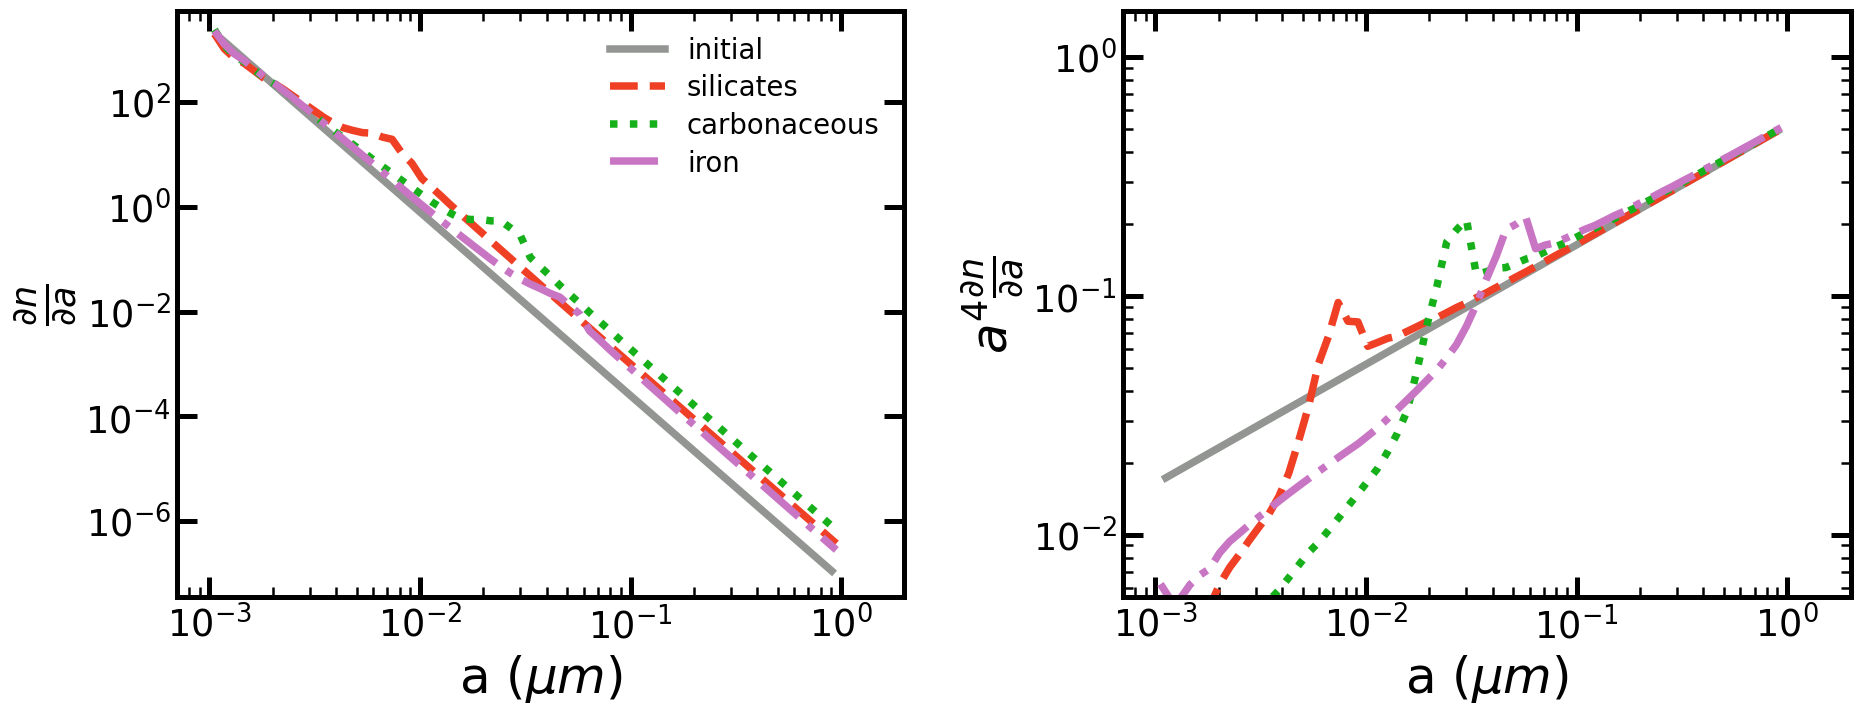

In [203]:
foutname = plot_dir+'analytical_coagulation_pred.pdf'

amin=1E-3; amax=1E0
init_dnda = gse.MRN_dnda
def init_dmda(a):
    return init_dnda(a) * 4 * np.pi / 3 * np.power(a,3)
def init_dmdloga(a):
    return init_dnda(a) * 4 * np.pi / 3 * np.power(a,4)
# Use this to normalize dn/da by total grain number and dm/da by total grain mass
init_dn_norm = 1/quad(init_dnda,amin,amax)[0]
init_dm_norm = 1/quad(init_dmda,amin,amax)[0]
bin_nums=64


fig = Figure(2,ncols=2)
colors = config.LINE_COLORS[:5]
linestyles = config.LINE_STYLES[:5]
linewidth = 2*config.BASE_LINEWIDTH
fig.set_axis(0, 'grain_size', 'dn/da',y_lim=[np.power(10,-0.5)*np.min(init_dnda(a_bins)[init_dnda(a_bins)>0]*init_dn_norm),np.power(10,0.5)*np.max(init_dnda(a_bins)[init_dnda(a_bins)>0]*init_dn_norm)])
fig.set_axis(1, 'grain_size', 'dm/da',y_lim=[np.power(10,-0.5)*np.min(init_dmdloga(a_bins)[init_dmdloga(a_bins)>0]*init_dm_norm),np.power(10,0.5)*np.max(init_dmdloga(a_bins)[init_dmdloga(a_bins)>0]*init_dm_norm)])


fig.plot_line_data(0,a_bins,init_dnda(a_bins)*init_dn_norm, color='xkcd:grey',linestyle=linestyles[0], linewidth=1.5*config.BASE_LINEWIDTH,label="initial", zorder=-2)
fig.plot_line_data(1,a_bins,init_dmdloga(a_bins)*init_dm_norm, color='xkcd:grey',linestyle=linestyles[0], linewidth=1.5*config.BASE_LINEWIDTH,label="initial", zorder=-2)

species = ['silicates','carbonaceous','iron']
ISM_phase = 'MC'
dt = 0.01
subcycle_constraint = 'both'

for i,spec in enumerate(species):
    print(spec)
    a_bins, dnda, dmda  = gse.change_in_grain_distribution_from_shat_coag(dt, amin=amin,amax=amax,bin_num=bin_nums, init_dnda = init_dnda, subcycle_constraints=subcycle_constraint, ISM_phase=ISM_phase, species=spec)
    dmdloga = lambda a: a*dmda(a)

    fig.plot_line_data(0,a_bins,dnda(a_bins), color=colors[i+1],linestyle=linestyles[i+1], linewidth=1.5*config.BASE_LINEWIDTH,label=spec)

    fig.plot_line_data(1,a_bins,dmdloga(a_bins), color=colors[i+1],linestyle=linestyles[i+1], linewidth=1.5*config.BASE_LINEWIDTH,label=spec)

fig.set_all_legends(max_cols=2,rescale_font=0.75)
fig.save(foutname)


#### Shattering
Note the increase at the smallest grain size bin is due to rebinning shattered fragments beyond the minimum grain size back to the smallest bin.

silicates
Final changes
Mass fraction moved in given timestep 0.9936951213965453
Number fraction changed in given timestep 1.281276135903255
carbonaceous
Need to subcycle for 2 cycle
	 Number fraction changed 2.621603429315994e-07
	 Mass fraction change 0.11755970119443643
	 Change if we did not subcycle
	 Mass fraction change in given timestep 0.9878403360591207
	 Number fraction change in given timestep 1.6644661576363555
Final changes
Mass fraction moved in given timestep 0.9867394053558064
Number fraction changed in given timestep 1.6704927240904919
iron
Need to subcycle for 2 cycle
	 Number fraction changed 3.886130188129491e-07
	 Mass fraction change 0.17514679972933267
	 Change if we did not subcycle
	 Mass fraction change in given timestep 0.9861526070062213
	 Number fraction change in given timestep 1.8919336333528078
Final changes
Mass fraction moved in given timestep 0.9841384427106022
Number fraction changed in given timestep 1.9592541445907454


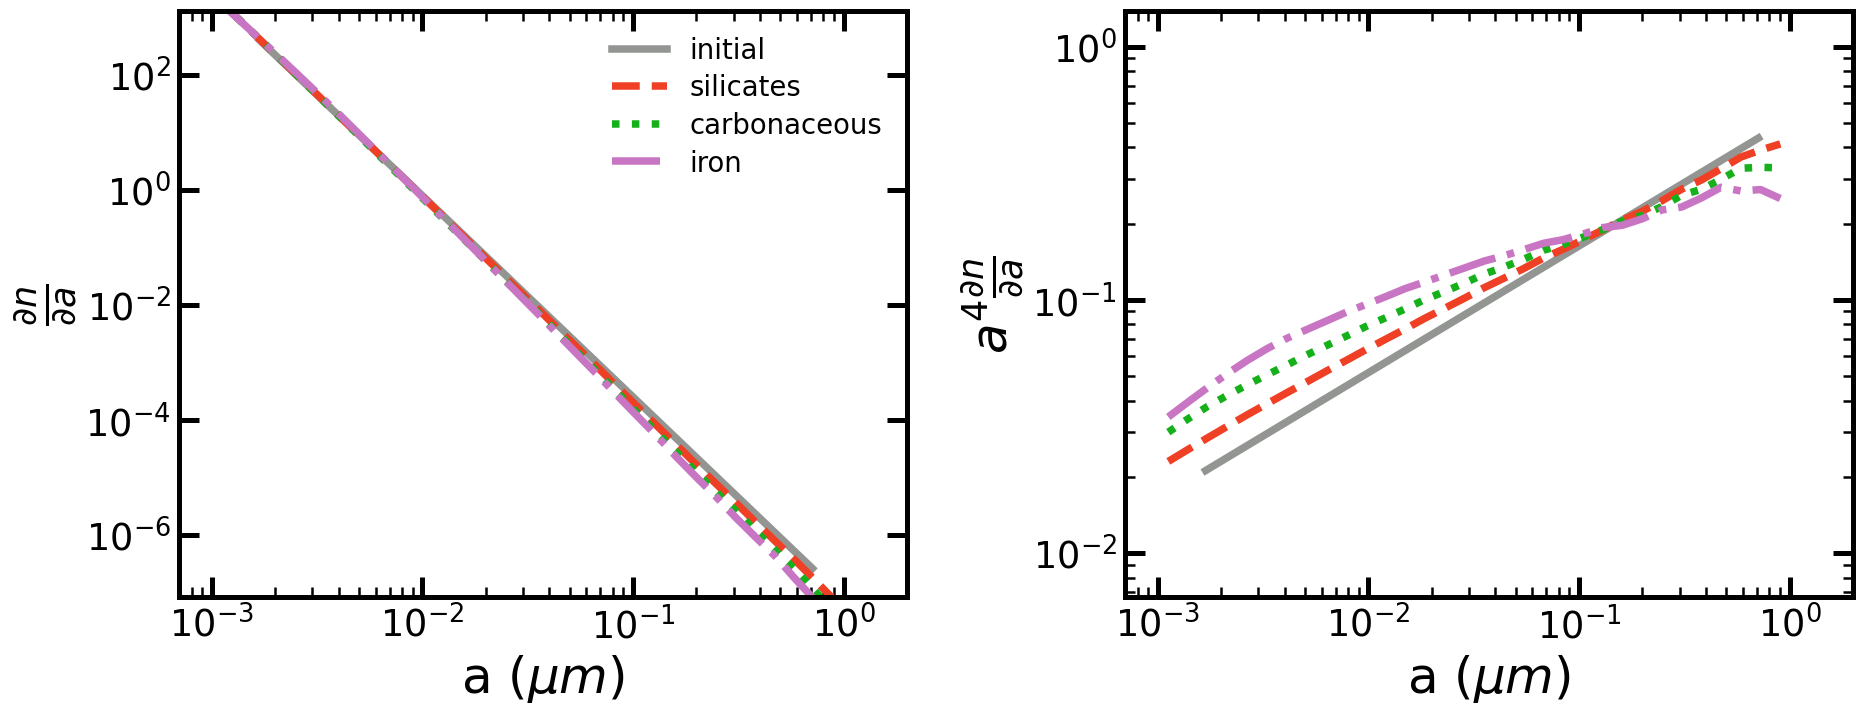

In [448]:
foutname = plot_dir+'analytical_shattering_pred.pdf'

amin=1E-3; amax=1E0
init_dnda = gse.MRN_dnda
def init_dmda(a):
    return init_dnda(a) * 4 * np.pi / 3 * np.power(a,3)
def init_dmdloga(a):
    return init_dnda(a) * 4 * np.pi / 3 * np.power(a,4)
# Use this to normalize dn/da by total grain number and dm/da by total grain mass
init_dn_norm = 1/quad(init_dnda,amin,amax)[0]
init_dm_norm = 1/quad(init_dmda,amin,amax)[0]
bin_nums=32

fig = Figure(2,ncols=2)
colors = config.LINE_COLORS[:5]
linestyles = config.LINE_STYLES[:5]
linewidth = 2*config.BASE_LINEWIDTH
fig.set_axis(0, 'grain_size', 'dn/da',y_lim=[np.power(10,-0.5)*np.min(init_dnda(a_bins)[init_dnda(a_bins)>0]*init_dn_norm),np.power(10,0.5)*np.max(init_dnda(a_bins)[init_dnda(a_bins)>0]*init_dn_norm)])
fig.set_axis(1, 'grain_size', 'dm/da',y_lim=[np.power(10,-0.5)*np.min(init_dmdloga(a_bins)[init_dmdloga(a_bins)>0]*init_dm_norm),np.power(10,0.5)*np.max(init_dmdloga(a_bins)[init_dmdloga(a_bins)>0]*init_dm_norm)])


fig.plot_line_data(0,a_bins,init_dnda(a_bins)*init_dn_norm, color='xkcd:grey',linestyle=linestyles[0], linewidth=1.5*config.BASE_LINEWIDTH,label="initial", zorder=-2)
fig.plot_line_data(1,a_bins,init_dmdloga(a_bins)*init_dm_norm, color='xkcd:grey',linestyle=linestyles[0], linewidth=1.5*config.BASE_LINEWIDTH,label="initial", zorder=-2)

species = ['silicates','carbonaceous','iron']
ISM_phase = 'WIM'
init_depl = 0.2
dt = 0.02
subcycle_constraints='both'

for i,spec in enumerate(species):
    print(spec)
    a_bins, dnda, dmda  = gse.change_in_grain_distribution_from_shat_coag(dt, amin=amin,amax=amax,bin_num=bin_nums, init_dnda = init_dnda, depl_frac=init_depl, subcycle_constraints=subcycle_constraints, ISM_phase=ISM_phase, species=spec)
    dmdloga = lambda a: a*dmda(a)

    fig.plot_line_data(0,a_bins,dnda(a_bins), color=colors[i+1],linestyle=linestyles[i+1], linewidth=1.5*config.BASE_LINEWIDTH,label=spec)

    fig.plot_line_data(1,a_bins,dmdloga(a_bins), color=colors[i+1],linestyle=linestyles[i+1], linewidth=1.5*config.BASE_LINEWIDTH,label=spec)

fig.set_all_legends(max_cols=2,rescale_font=0.75)
fig.save(foutname)


silicates
3649082.9614223703 3.0629677742466127e-14 2.1816518201271992e+83
3649082.9614223703 1.852320532051236e-13 2.1816518201271992e+83
3649082.9614223703 3.3901283486055174e-13 2.1816518201271992e+83
3649082.9614223703 6.204633604796034e-13 2.1816518201271992e+83
3649082.9614223703 1.1355758310920478e-12 2.1816518201271992e+83
3649082.9614223703 2.1451715334058844e-12 2.1816518201271992e+83
3649082.9614223703 2.5329374053808925e-13 2.1816518201271992e+83
3649082.9614223703 0 2.1816518201271992e+83
Final changes
Mass fraction moved in given timestep 0.9996487935033016
Number fraction changed in given timestep 2235.117918864531
carbonaceous
3093875.4574438063 2.1852578674197855e-14 2.03363673087085e+83
3093875.4574438063 1.3423906253826087e-13 2.03363673087085e+83
3093875.4574438063 2.4568515196299685e-13 2.03363673087085e+83
3093875.4574438063 4.496544653526365e-13 2.03363673087085e+83
3093875.4574438063 8.229603482184284e-13 2.03363673087085e+83
3093875.4574438063 1.518715391847732

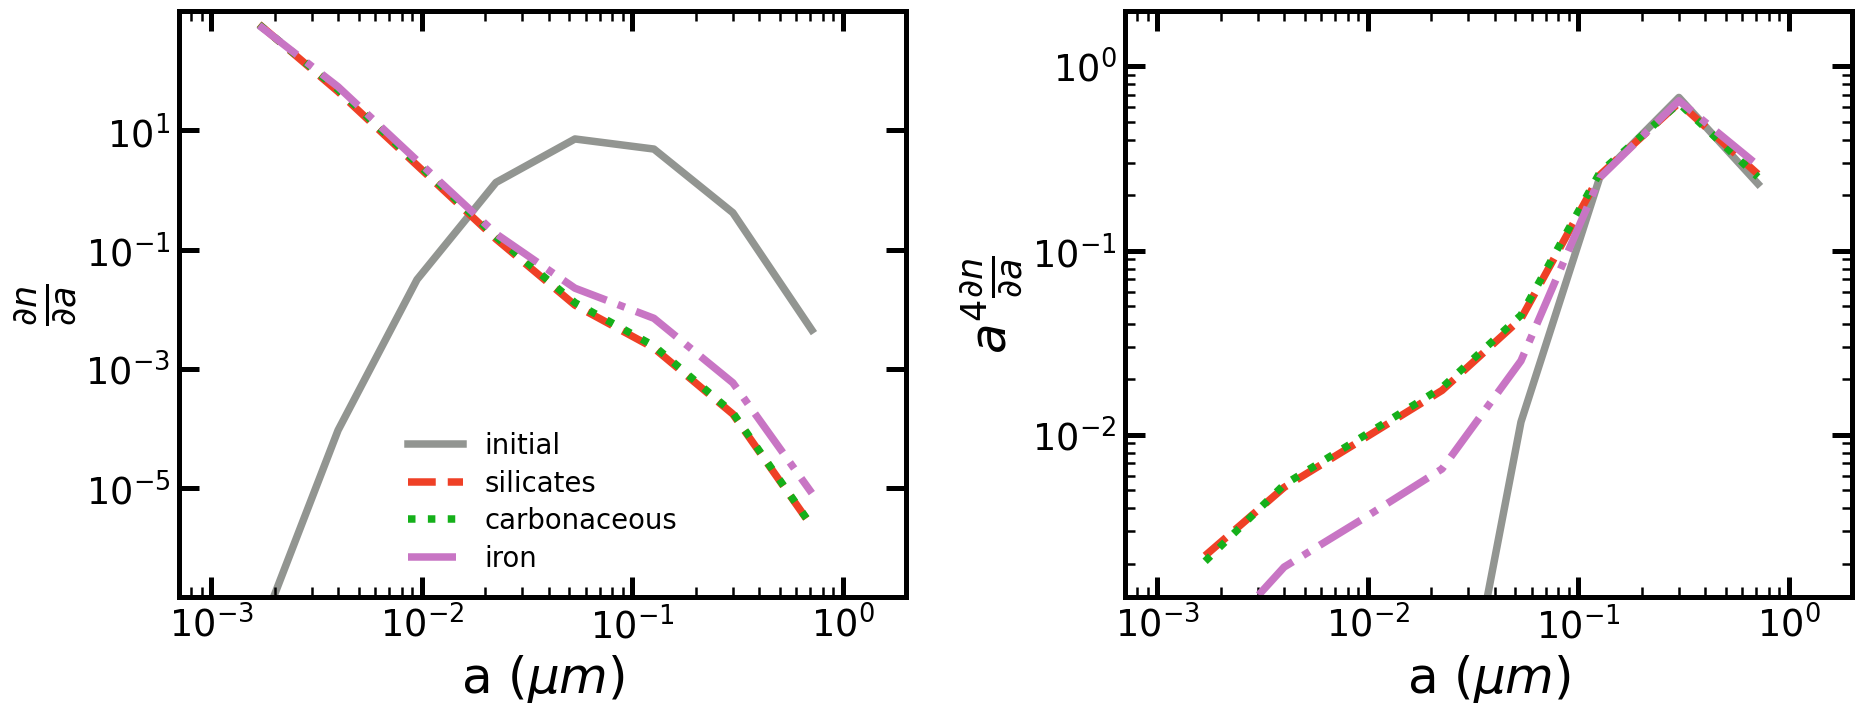

In [447]:
foutname = plot_dir+'analytical_shattering_pred_lognorm.pdf'

amin=1E-3; amax=1E0
init_dnda = gse.lognorm_dnda
def init_dmda(a, a_norm=0.1*config.um_to_cm, sigma_a=0.6):
    return init_dnda(a, a_norm=a_norm, sigma_a=sigma_a) * 4 * np.pi / 3 * np.power(a,3)
def init_dmdloga(a, a_norm=0.1*config.um_to_cm, sigma_a=0.6):
    return init_dnda(a, a_norm=a_norm, sigma_a=sigma_a) * 4 * np.pi / 3 * np.power(a,4)
# Use this to normalize dn/da by total grain number and dm/da by total grain mass
init_dn_norm = 1/quad(init_dnda,amin,amax, args=(0.1,0.6))[0]
init_dm_norm = 1/quad(init_dmda,amin,amax, args=(0.1,0.6))[0]
bin_nums=8


fig = Figure(2,ncols=2)
colors = config.LINE_COLORS[:5]
linestyles = config.LINE_STYLES[:5]
linewidth = 2*config.BASE_LINEWIDTH


fig.plot_line_data(0,a_bins,init_dnda(a_bins,a_norm=0.1)*init_dn_norm, color='xkcd:grey',linestyle=linestyles[0], linewidth=1.5*config.BASE_LINEWIDTH,label="initial", zorder=-2)
fig.plot_line_data(1,a_bins,init_dmdloga(a_bins,a_norm=0.1)*init_dm_norm, color='xkcd:grey',linestyle=linestyles[0], linewidth=1.5*config.BASE_LINEWIDTH,label="initial", zorder=-2)

fig.set_axis(0, 'grain_size', 'dn/da',y_lim=[np.power(10,-0.5)*np.min(new_dnda(a_bins)[new_dnda(a_bins)>0]),np.power(10,0.5)*np.max(new_dnda(a_bins)[new_dnda(a_bins)>0])])
fig.set_axis(1, 'grain_size', 'dm/da',y_lim=[np.power(10,-0.5)*np.min(new_dmdloga(a_bins)[new_dmdloga(a_bins)>0]),np.power(10,0.5)*np.max(new_dmdloga(a_bins)[new_dmda(a_bins)>0])])


species = ['silicates','carbonaceous','iron']
ISM_phase = 'WIM'
init_depl = 0.5
dt = 0.005
subcycle_constraints='both'

for i,spec in enumerate(species):
    print(spec)
    a_bins, dnda, dmda  = gse.change_in_grain_distribution_from_shat_coag(dt, amin=amin,amax=amax,bin_num=bin_nums, init_dnda = init_dnda, depl_frac=init_depl, subcycle_constraints=subcycle_constraints, ISM_phase=ISM_phase, species=spec)
    dmdloga = lambda a: a*dmda(a)

    fig.plot_line_data(0,a_bins,dnda(a_bins), color=colors[i+1],linestyle=linestyles[i+1], linewidth=1.5*config.BASE_LINEWIDTH,label=spec)

    fig.plot_line_data(1,a_bins,dmdloga(a_bins), color=colors[i+1],linestyle=linestyles[i+1], linewidth=1.5*config.BASE_LINEWIDTH,label=spec)

fig.set_all_legends(max_cols=2,rescale_font=0.75)
fig.save(foutname)


#### Accretion

silicates
Clumping factor 3.2496792135519685
Coulomb_enhancement [9.96756221 9.96756221 9.96756221 9.96756221 9.96756221 9.96756221
 9.96756221 9.96756221 9.96756221 9.96756221 9.96756221 9.96756221
 9.96756221 9.96756221 9.96756221 9.96756221 9.96756221 9.96756221
 9.96756221 9.96756221 9.96756221 0.5018021  0.5018021  0.5018021
 0.5018021  0.5018021  0.5018021  0.5018021  0.5018021  0.5018021
 0.5018021  0.5018021  0.5018021  0.5018021  0.5018021  0.5018021
 0.5018021  0.5018021  0.5018021  0.5018021  0.5018021  0.5018021
 0.5018021  0.5018021  0.5018021  0.5018021  0.5018021  0.5018021
 0.5018021  0.5018021  0.5018021  0.5018021  0.5018021  0.5018021
 0.5018021  0.5018021  0.5018021  0.5018021  0.5018021  0.5018021
 0.5018021  0.5018021  0.5018021  0.5018021 ]
n_key 0.000684469130527665
factor 0.005933526046677333
Predicted dadt (um/Gyr): [2.03891815 2.03891815 2.03891815 2.03891815 2.03891815 2.03891815
 2.03891815 2.03891815 2.03891815 2.03891815 2.03891815 2.03891815
 2.03891815 

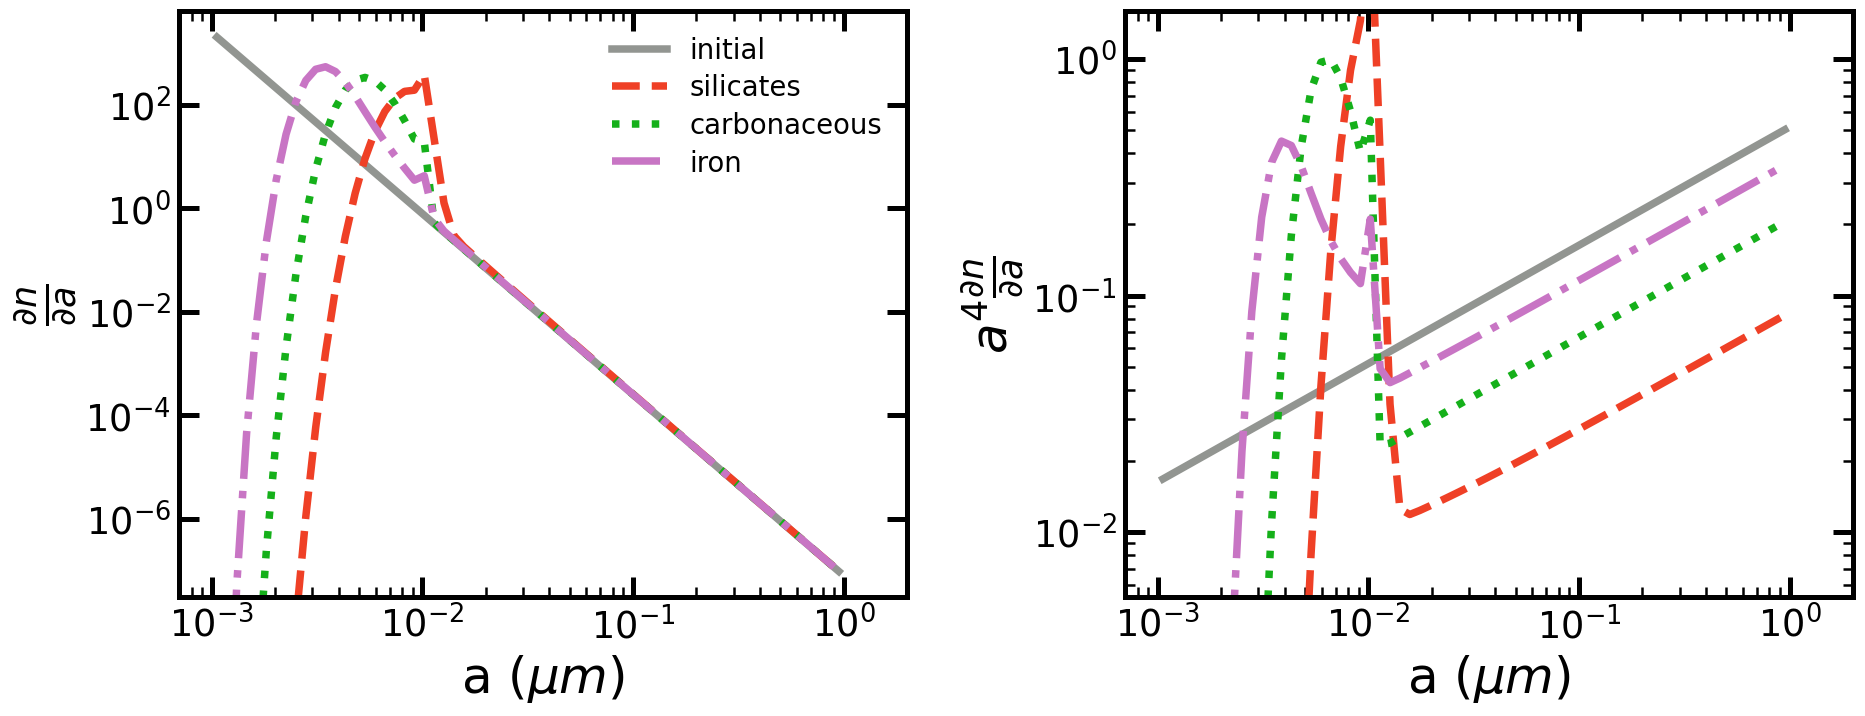

In [226]:
foutname = plot_dir+'analytical_accretion_pred_enh.pdf'

amin=1E-3; amax=1E0
init_dnda = gse.MRN_dnda
def init_dmda(a):
    return init_dnda(a) * 4 * np.pi / 3 * np.power(a,3)
def init_dmdloga(a):
    return init_dnda(a) * 4 * np.pi / 3 * np.power(a,4)
# Use this to normalize dn/da by total grain number and dm/da by total grain mass
init_dn_norm = 1/quad(init_dnda,amin,amax)[0]
init_dm_norm = 1/quad(init_dmda,amin,amax)[0]
bin_nums=64


fig = Figure(2,ncols=2)
colors = config.LINE_COLORS[:5]
linestyles = config.LINE_STYLES[:5]
linewidth = 2*config.BASE_LINEWIDTH
fig.set_axis(0, 'grain_size', 'dn/da',y_lim=[np.power(10,-0.5)*np.min(init_dnda(a_bins)[init_dnda(a_bins)>0]*init_dn_norm),np.power(10,0.5)*np.max(init_dnda(a_bins)[init_dnda(a_bins)>0]*init_dn_norm)])
fig.set_axis(1, 'grain_size', 'dm/da',y_lim=[np.power(10,-0.5)*np.min(init_dmdloga(a_bins)[init_dmdloga(a_bins)>0]*init_dm_norm),np.power(10,0.5)*np.max(init_dmdloga(a_bins)[init_dmdloga(a_bins)>0]*init_dm_norm)])


fig.plot_line_data(0,a_bins,init_dnda(a_bins)*init_dn_norm, color='xkcd:grey',linestyle=linestyles[0], linewidth=1.5*config.BASE_LINEWIDTH,label="initial", zorder=-2)
fig.plot_line_data(1,a_bins,init_dmdloga(a_bins)*init_dm_norm, color='xkcd:grey',linestyle=linestyles[0], linewidth=1.5*config.BASE_LINEWIDTH,label="initial", zorder=-2)

species = ['silicates','carbonaceous','iron']
ISM_phase = 'CNM'
dt = 0.005
init_depl = 0.1 # initial depletion of key element for dust species
subcycle_constraints='min_bin'

for i,spec in enumerate(species):
    print(spec)
    a_bins, dnda, dmda  = gse.change_in_grain_distribution_from_acc_sput(dt, amin=amin,amax=amax,bin_num=bin_nums, init_dnda = init_dnda, ISM_phase=ISM_phase, subcycle_constraints=subcycle_constraints, species=spec, depl_frac=init_depl)

    fig.plot_line_data(0,a_bins,dnda(a_bins), color=colors[i+1],linestyle=linestyles[i+1], linewidth=1.5*config.BASE_LINEWIDTH,label=spec)

    fig.plot_line_data(1,a_bins,dmda(a_bins)*a_bins, color=colors[i+1],linestyle=linestyles[i+1], linewidth=1.5*config.BASE_LINEWIDTH,label=spec)

fig.set_all_legends(max_cols=2,rescale_font=0.75)
fig.save(foutname)


Testing different subcycling prescriptions.
Decided on using the minimum bin.

none
Total cycles needed 1 Subcycle timestep 0.001
Change in total grain number 0.999999999950777
Change in total grain mass 1.0886402476238488
Initial and final depletion fraction 0.1 0.10886402476238488
size
Total cycles needed 1 Subcycle timestep 0.001
Change in total grain number 0.999999999950777
Change in total grain mass 1.0886402476238488
Initial and final depletion fraction 0.1 0.10886402476238488
min_bin
0.00024093776075171964
Total cycles needed 6.0 Subcycle timestep 0.00016666666666666666
Change in total grain number 0.9999999999510447
Change in total grain mass 1.104806641333839
Initial and final depletion fraction 0.1 0.11048066413338391


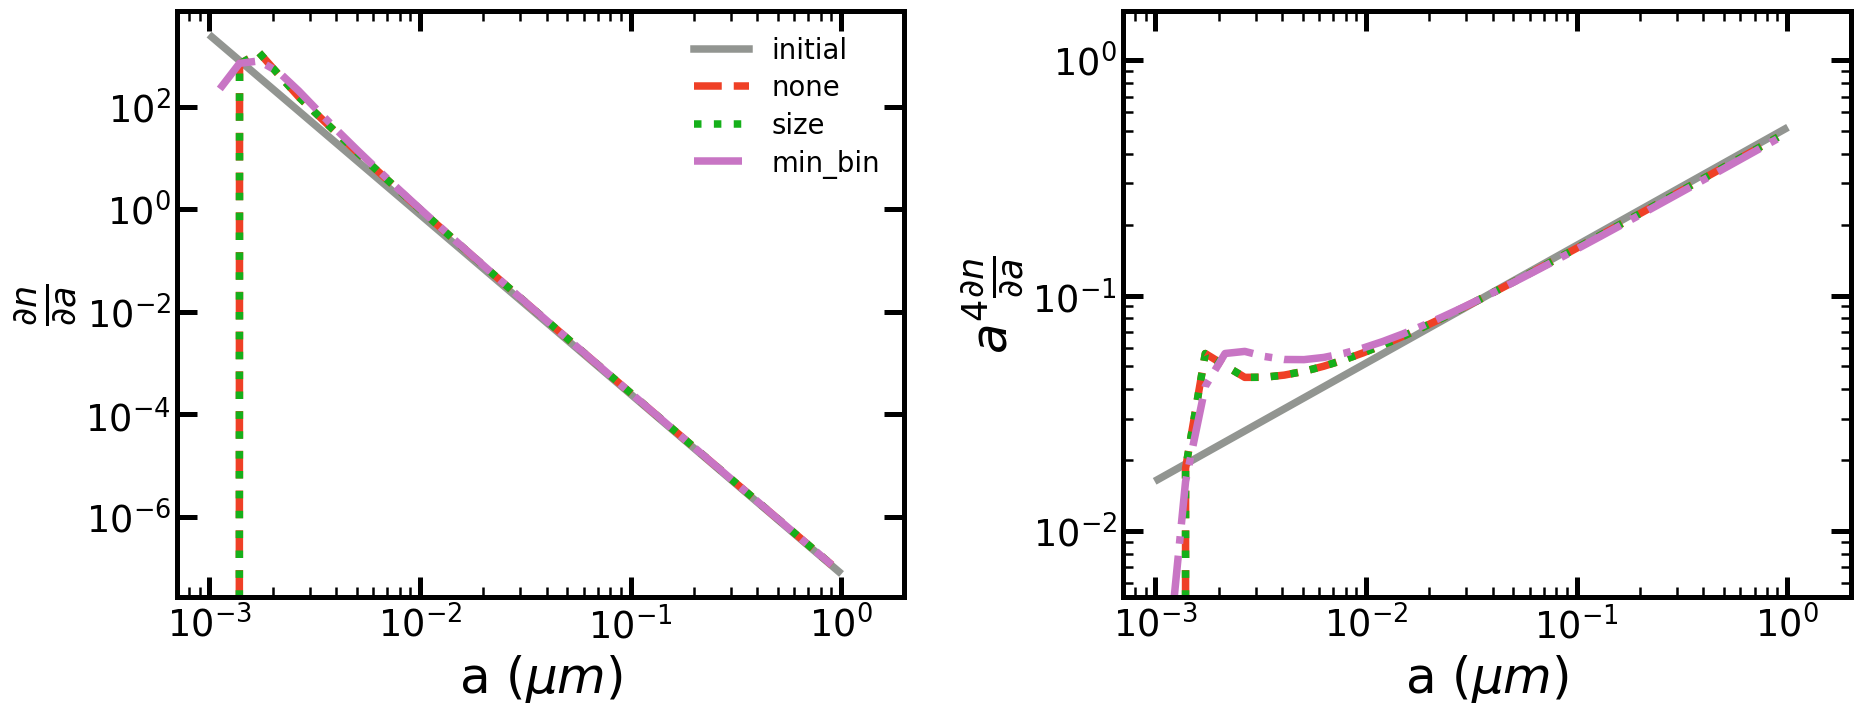

In [174]:
foutname = 'analytical_acretion_pred_subcycling_comparisons.pdf'

amin=1E-3; amax=1E0
init_dnda = gse.MRN_dnda
def init_dmda(a):
    return init_dnda(a) * 4 * np.pi / 3 * np.power(a,3)
def init_dmdloga(a):
    return init_dnda(a) * 4 * np.pi / 3 * np.power(a,4)
# Use this to normalize dn/da by total grain number and dm/da by total grain mass
init_dn_norm = 1/quad(init_dnda,amin,amax)[0]
init_dm_norm = 1/quad(init_dmda,amin,amax)[0]
bin_nums=32


fig = Figure(2,ncols=2)
colors = config.LINE_COLORS[:5]
linestyles = config.LINE_STYLES[:5]
linewidth = 2*config.BASE_LINEWIDTH
fig.set_axis(0, 'grain_size', 'dn/da',y_lim=[np.power(10,-0.5)*np.min(init_dnda(a_bins)[init_dnda(a_bins)>0]*init_dn_norm),np.power(10,0.5)*np.max(init_dnda(a_bins)[init_dnda(a_bins)>0]*init_dn_norm)])
fig.set_axis(1, 'grain_size', 'dm/da',y_lim=[np.power(10,-0.5)*np.min(init_dmdloga(a_bins)[init_dmdloga(a_bins)>0]*init_dm_norm),np.power(10,0.5)*np.max(init_dmdloga(a_bins)[init_dmdloga(a_bins)>0]*init_dm_norm)])


fig.plot_line_data(0,a_bins,init_dnda(a_bins)*init_dn_norm, color='xkcd:grey',linestyle=linestyles[0], linewidth=1.5*config.BASE_LINEWIDTH,label="initial", zorder=-2)
fig.plot_line_data(1,a_bins,init_dmdloga(a_bins)*init_dm_norm, color='xkcd:grey',linestyle=linestyles[0], linewidth=1.5*config.BASE_LINEWIDTH,label="initial", zorder=-2)

spec = 'silicates'
ISM_phase = 'CNM'
dt = 0.001
init_depl = 0.1 # initial depletion of key element for dust species
subcycle_constraints=['none','size','min_bin']

for i,subcycle in enumerate(subcycle_constraints):
    print(subcycle)
    a_bins, dnda, dmda  = gse.change_in_grain_distribution_from_acc_sput(dt, amin=amin,amax=amax,bin_num=bin_nums, init_dnda = init_dnda, ISM_phase=ISM_phase, subcycle_constraints=subcycle, species=spec, depl_frac=init_depl)

    fig.plot_line_data(0,a_bins,dnda(a_bins), color=colors[i+1],linestyle=linestyles[i+1], linewidth=1.5*config.BASE_LINEWIDTH,label=subcycle)

    fig.plot_line_data(1,a_bins,dmdloga(a_bins), color=colors[i+1],linestyle=linestyles[i+1], linewidth=1.5*config.BASE_LINEWIDTH,label=subcycle)

fig.set_all_legends(max_cols=2,rescale_font=0.75)
fig.save(foutname)


#### Thermal Sputtering

silicates
Predicted dadt (um/Gyr): -0.9199920004722989
Min bin width used for subcyling 0.00011397385999480242
Total cycles needed 2691.0 Subcycle timestep 3.716090672612412e-05
Change in total grain number 1.5126259679420442e-05
Change in total grain mass 0.35256246297961885
Initial and final depletion fraction 0.1 0.035256246297961855
carbonaceous
Predicted dadt (um/Gyr): -0.45783220029913224
Min bin width used for subcyling 0.00011397385999480242
Total cycles needed 1339.0 Subcycle timestep 7.468259895444362e-05
Change in total grain number 8.428418972989833e-05
Change in total grain mass 0.5079015169690576
Initial and final depletion fraction 0.1 0.05079015169690579
iron
Predicted dadt (um/Gyr): -0.43646272260277963
Min bin width used for subcyling 0.00011397385999480242
Total cycles needed 1277.0 Subcycle timestep 7.830853563038371e-05
Change in total grain number 9.472373982720711e-05
Change in total grain mass 0.5178300341299557
Initial and final depletion fraction 0.1 0.0517830

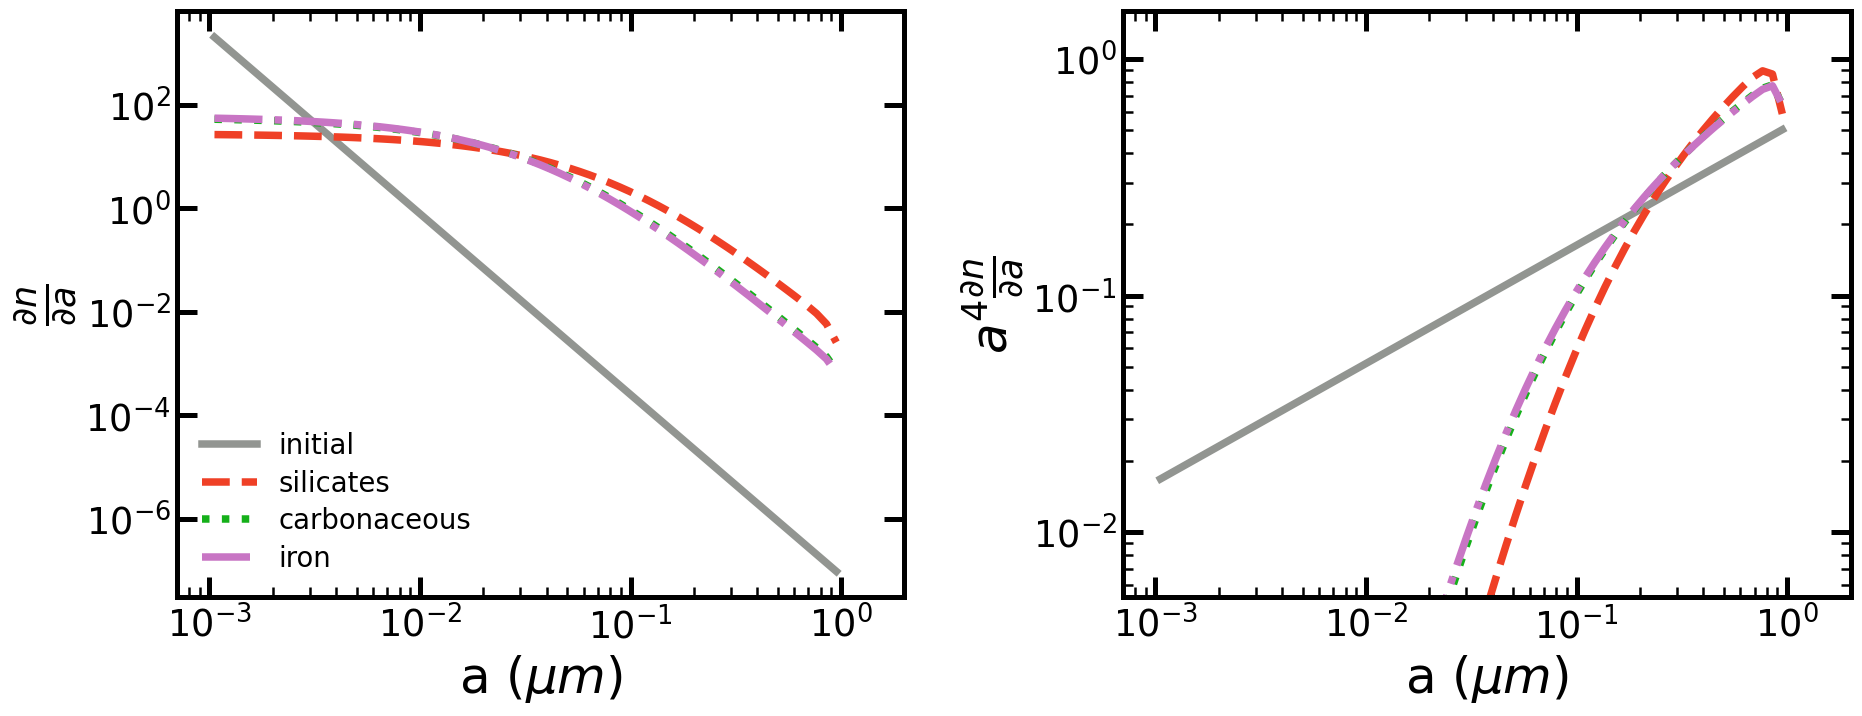

In [201]:
foutname = plot_dir+'analytical_sputtering_pred.pdf'

amin=1E-3; amax=1E0
init_dnda = gse.MRN_dnda
def init_dmda(a):
    return init_dnda(a) * 4 * np.pi / 3 * np.power(a,3)
def init_dmdloga(a):
    return init_dnda(a) * 4 * np.pi / 3 * np.power(a,4)
# Use this to normalize dn/da by total grain number and dm/da by total grain mass
init_dn_norm = 1/quad(init_dnda,amin,amax)[0]
init_dm_norm = 1/quad(init_dmda,amin,amax)[0]
bin_nums=64


fig = Figure(2,ncols=2)
colors = config.LINE_COLORS[:5]
linestyles = config.LINE_STYLES[:5]
linewidth = 2*config.BASE_LINEWIDTH
fig.set_axis(0, 'grain_size', 'dn/da',y_lim=[np.power(10,-0.5)*np.min(init_dnda(a_bins)[init_dnda(a_bins)>0]*init_dn_norm),np.power(10,0.5)*np.max(init_dnda(a_bins)[init_dnda(a_bins)>0]*init_dn_norm)])
fig.set_axis(1, 'grain_size', 'dm/da',y_lim=[np.power(10,-0.5)*np.min(init_dmdloga(a_bins)[init_dmdloga(a_bins)>0]*init_dm_norm),np.power(10,0.5)*np.max(init_dmdloga(a_bins)[init_dmdloga(a_bins)>0]*init_dm_norm)])


fig.plot_line_data(0,a_bins,init_dnda(a_bins)*init_dn_norm, color='xkcd:grey',linestyle=linestyles[0], linewidth=1.5*config.BASE_LINEWIDTH,label="initial", zorder=-2)
fig.plot_line_data(1,a_bins,init_dmdloga(a_bins)*init_dm_norm, color='xkcd:grey',linestyle=linestyles[0], linewidth=1.5*config.BASE_LINEWIDTH,label="initial", zorder=-2)

species = ['silicates','carbonaceous','iron']
ISM_phase = 'HIM'
dt = 0.1
init_depl = 0.1 # initial depletion of key element for dust species
subcycle_constraints='min_bin'

for i,spec in enumerate(species):
    print(spec)
    a_bins, dnda, dmda  = gse.change_in_grain_distribution_from_acc_sput(dt, amin=amin,amax=amax,bin_num=bin_nums, init_dnda = init_dnda, ISM_phase=ISM_phase, subcycle_constraints=subcycle_constraints, species=spec, depl_frac=init_depl)

    fig.plot_line_data(0,a_bins,dnda(a_bins), color=colors[i+1],linestyle=linestyles[i+1], linewidth=1.5*config.BASE_LINEWIDTH,label=spec)

    fig.plot_line_data(1,a_bins,dmdloga(a_bins), color=colors[i+1],linestyle=linestyles[i+1], linewidth=1.5*config.BASE_LINEWIDTH,label=spec)

fig.set_all_legends(max_cols=2,rescale_font=0.75)
fig.save(foutname)


#### Simple visualizations for dust processes diagram

This are parameters every diagram uses.

In [6]:
amin=1E-3; amax=1E0
init_dnda = gse.MRN_dnda
def init_dmda(a):
    return init_dnda(a) * 4 * np.pi / 3 * np.power(a,3)
def init_dmdloga(a):
    return init_dnda(a) * 4 * np.pi / 3 * np.power(a,4)
# Use this to normalize dn/da by total grain number and dm/da by total grain mass
init_dn_norm = 1/quad(init_dnda,amin,amax)[0]
init_dm_norm = 1/quad(init_dmda,amin,amax)[0]
# Normalize by the total mass
def init_dmdloga_normed(a):
    return init_dmdloga(a)*init_dm_norm

a_vals = np.logspace(np.log10(amin),np.log10(amax),num=100)
dmdloga_limits = [np.power(10,-0.5)*np.min(init_dmdloga_normed(a_vals)),np.power(10,0.5)*np.max(init_dmdloga_normed(a_vals))]


colors = ["xkcd:dark royal blue","xkcd:forest green","xkcd:indian red",]
colors = ["xkcd:red","xkcd:green","xkcd:blue",]
linestyles = config.LINE_STYLES[:5]
linestyles = ['-','--','-.',':']
linewidth = 3.75*config.BASE_LINEWIDTH

species = ['silicates','carbonaceous','iron']
init_depl = 0.3 # initial depletion of key element for dust species


##### Accretion

silicates
Clumping factor 3.7209810129834526
Predicted dadt (um/Gyr): 0.1702188521068979
Min bin width used for subcyling 0.00011397385999480242
Total cycles needed 50.0 Subcycle timestep 0.0002
Change in total grain number 0.9999999998465511
Change in total grain mass 1.3318645692103412
Initial and final depletion fraction 0.3 0.39955937076310244
carbonaceous
Clumping factor 3.3863283482060633
Predicted dadt (um/Gyr): 0.22871617118284024
Min bin width used for subcyling 0.00011397385999480242
Total cycles needed 67.0 Subcycle timestep 0.00014925373134328358
Change in total grain number 0.9999999998000392
Change in total grain mass 1.5054957508119744
Initial and final depletion fraction 0.3 0.45164872524359245
iron
Clumping factor 3.7209810129834526
Predicted dadt (um/Gyr): 0.018197970689643943
Min bin width used for subcyling 0.00011397385999480242
Total cycles needed 6.0 Subcycle timestep 0.0016666666666666668
Change in total grain number 0.9999999999826968
Change in total grain mass

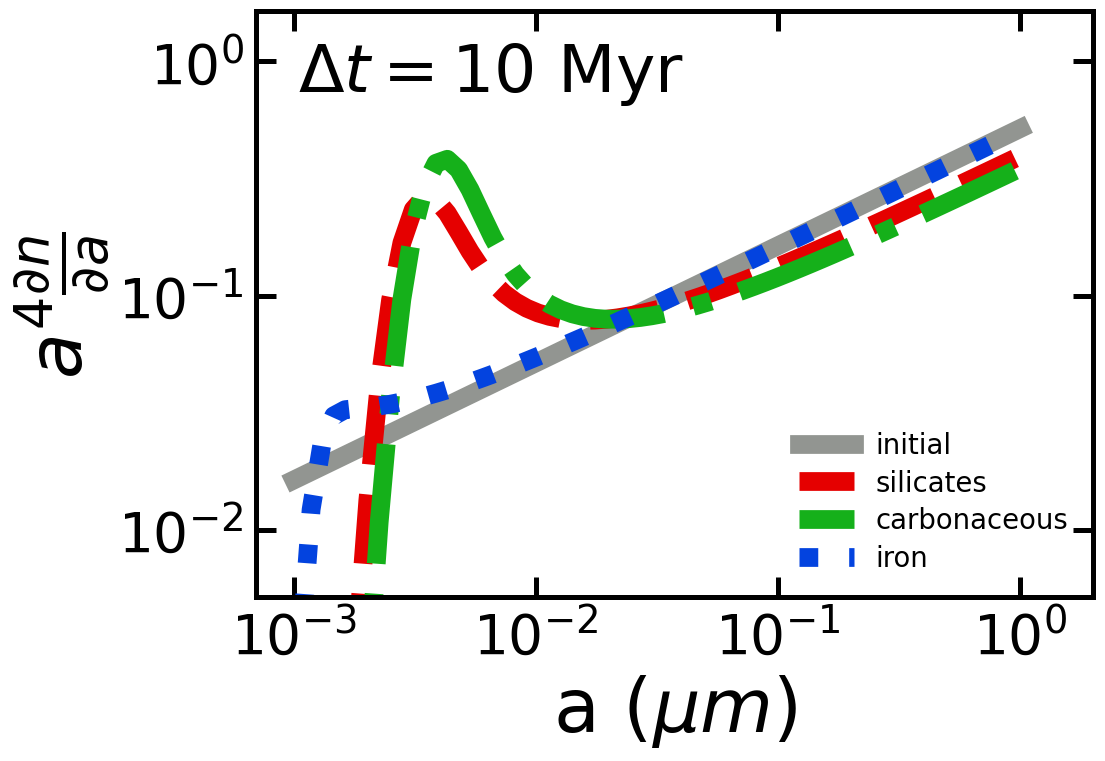

In [47]:
foutname = plot_dir+'grain_size_accretion_diagram.pdf'
ISM_phase = 'CNM'
dt = 0.01
subcycle_constraints='min_bin'
bin_nums=64

fig = Figure(1,ncols=2)

fig.set_axis(0, 'grain_size', 'dm/da',y_lim=dmdloga_limits, rescale_font=1.5, no_minor_ticks=True)

fig.plot_line_data(0,a_vals,init_dmdloga_normed(a_vals), color='xkcd:grey',linestyle=linestyles[0], linewidth=linewidth,label="initial", zorder=-2)

for i,spec in enumerate(species):
    print(spec)
    a_bins, dnda, dmda  = gse.change_in_grain_distribution_from_acc_sput(dt, amin=amin,amax=amax,bin_num=bin_nums, init_dnda = init_dnda, ISM_phase=ISM_phase, subcycle_constraints=subcycle_constraints, species=spec, depl_frac=init_depl)

    fig.plot_line_data(0,a_bins,dmda(a_bins)*a_bins, color=colors[i],linestyle=linestyles[i+1], linewidth=linewidth,label=spec)

text = r'$\Delta t = %2.0f $ Myr'%(dt*1E3)
fig.add_text(0,0.05,0.95,text,rescale_font=1, ha='left', va='top')

fig.set_all_legends(max_cols=2,rescale_font=0.75)
fig.save(foutname)

##### Sputtering

silicates
Predicted dadt (um/Gyr): -0.3999458668299783
Min bin width used for subcyling 0.00011397385999480242
Total cycles needed 11698.0 Subcycle timestep 8.548469823901521e-05
Change in total grain number 3.616217766730903e-07
Change in total grain mass 0.05503461306428209
Initial and final depletion fraction 0.3 0.016510383919284635
carbonaceous
Predicted dadt (um/Gyr): -0.25318688931168276
Min bin width used for subcyling 0.00011397385999480242
Total cycles needed 7405.0 Subcycle timestep 0.0001350438892640108
Change in total grain number 1.196947880813695e-06
Change in total grain mass 0.12847748236562478
Initial and final depletion fraction 0.3 0.03854324470968745
iron
Predicted dadt (um/Gyr): -0.16307178047565776
Min bin width used for subcyling 0.00011397385999480242
Total cycles needed 4770.0 Subcycle timestep 0.00020964360587002095
Change in total grain number 3.637457282033052e-06
Change in total grain mass 0.22043673795033863
Initial and final depletion fraction 0.3 0.0661

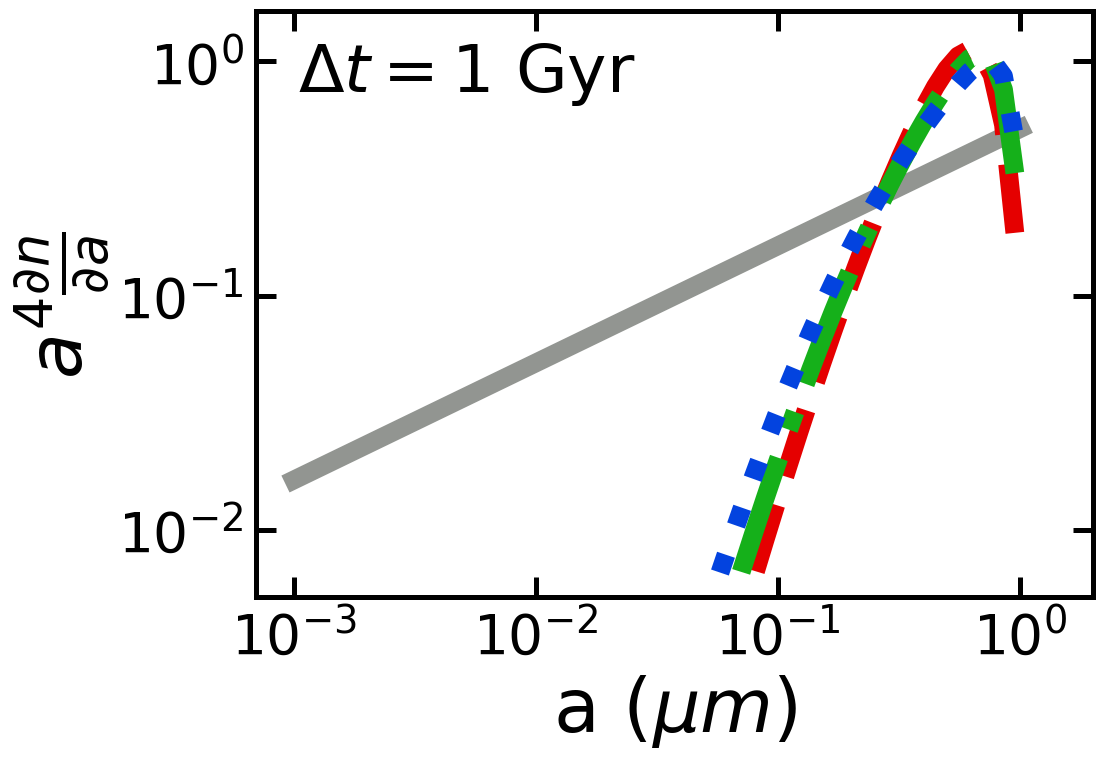

In [58]:
foutname = plot_dir+'grain_size_sputtering_diagram.pdf'

ISM_phase = 'HIM'
dt = 1
subcycle_constraints='min_bin'
bin_nums=64

fig = Figure(1,ncols=2)

fig.set_axis(0, 'grain_size', 'dm/da',y_lim=dmdloga_limits, rescale_font=1.5, no_minor_ticks=True)

fig.plot_line_data(0,a_vals,init_dmdloga_normed(a_vals), color='xkcd:grey',linestyle=linestyles[0], linewidth=linewidth,label="initial", zorder=-2)

for i,spec in enumerate(species):
    print(spec)
    a_bins, dnda, dmda = gse.change_in_grain_distribution_from_acc_sput(dt, amin=amin,amax=amax,bin_num=bin_nums, init_dnda = init_dnda, ISM_phase=ISM_phase, subcycle_constraints=subcycle_constraints, species=spec, depl_frac=init_depl)
    

    fig.plot_line_data(0,a_bins,dmda(a_bins)*a_bins, color=colors[i],linestyle=linestyles[i+1], linewidth=linewidth,label=spec)

text = r'$\Delta t = %1.0f $ Gyr'%(dt)
fig.add_text(0,0.05,0.95,text,rescale_font=1, ha='left', va='top')

#fig.set_all_legends(max_cols=2,rescale_font=0.75)
fig.save(foutname)


##### Shattering

silicates
Final changes
Mass fraction moved in given timestep 0.999794229119144
Number fraction changed in given timestep 0.9813066778513
carbonaceous
Final changes
Mass fraction moved in given timestep 0.9994783166731281
Number fraction changed in given timestep 0.995479833286628
iron
Final changes
Mass fraction moved in given timestep 0.9994177885675597
Number fraction changed in given timestep 1.0029775349209649


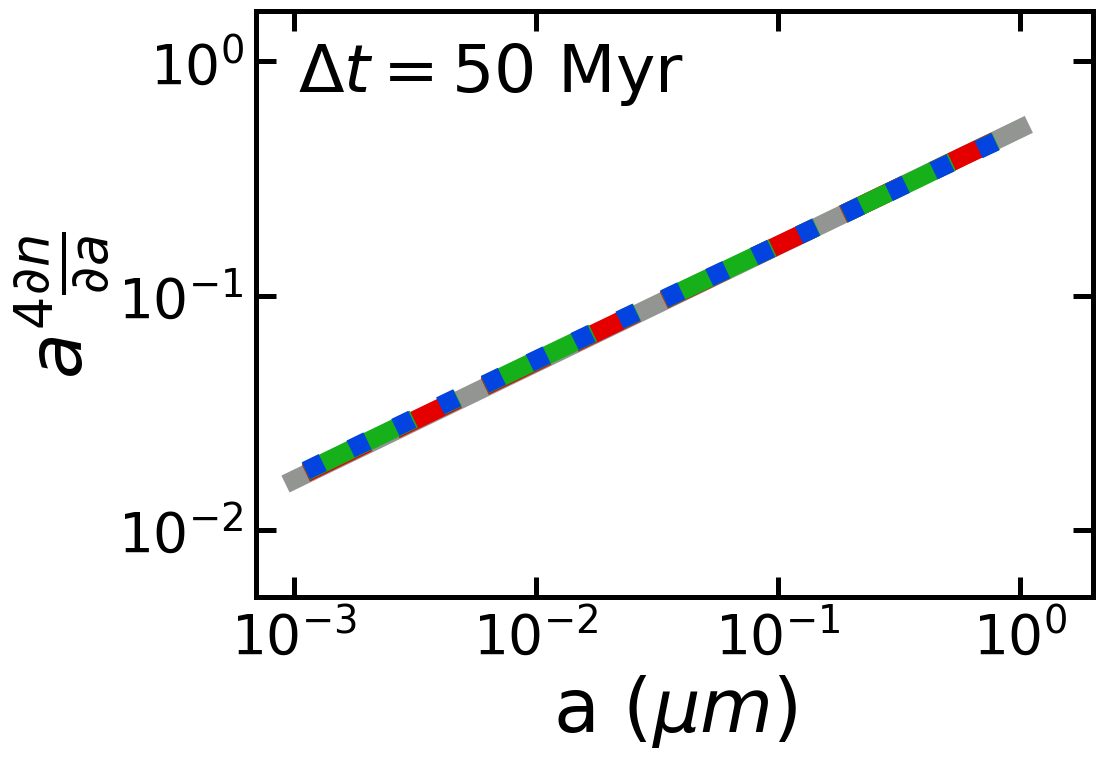

In [10]:
foutname = plot_dir+'grain_size_shattering_diagram.pdf'

ISM_phase = 'WIM'
dt = 0.05
subcycle_constraints='both'
bin_nums=32

fig = Figure(1,ncols=2)

fig.set_axis(0, 'grain_size', 'dm/da',y_lim=dmdloga_limits, rescale_font=1.5, no_minor_ticks=True)

fig.plot_line_data(0,a_vals,init_dmdloga_normed(a_vals), color='xkcd:grey',linestyle=linestyles[0], linewidth=linewidth,label="initial", zorder=-2)

for i,spec in enumerate(species):
    print(spec)
    a_bins, dnda, dmda  = gse.change_in_grain_distribution_from_shat_coag(dt, amin=amin,amax=amax,bin_num=bin_nums, init_dnda = init_dnda, ISM_phase=ISM_phase, subcycle_constraints=subcycle_constraints, species=spec, depl_frac=init_depl)

    fig.plot_line_data(0,a_bins,dmda(a_bins)*a_bins, color=colors[i],linestyle=linestyles[i+1], linewidth=linewidth,label=spec)

text = r'$\Delta t = %3.0f $ Myr'%(dt*1E3)
fig.add_text(0,0.05,0.95,text,rescale_font=1, ha='left', va='top')

#fig.set_all_legends(max_cols=2,rescale_font=0.75)
fig.save(foutname)


##### Coagulation

silicates
Need to subcycle for 7 cycle
	 Number fraction changed 0.6412697480469052
	 Mass fraction change 0.007867926670583869
	 Change if we did not subcycle
	 Mass fraction change in given timestep 1.0466560222971852
	 Number fraction change in given timestep 1.9839140710091911
Final changes
Mass fraction moved in given timestep 1.002764696226154
Number fraction changed in given timestep 0.7242197294554884
carbonaceous
Need to subcycle for 10 cycle
	 Number fraction changed 0.933239243175185
	 Mass fraction change 0.02974756296005999
	 Change if we did not subcycle
	 Mass fraction change in given timestep 1.463851979346105
	 Number fraction change in given timestep 0.324361694798028
Final changes
Mass fraction moved in given timestep 1.0345004311133266
Number fraction changed in given timestep 0.05687018568180319
iron
Need to subcycle for 10 cycle
	 Number fraction changed 0.9638061498753283
	 Mass fraction change 0.053608735149634545
	 Change if we did not subcycle
	 Mass fraction 

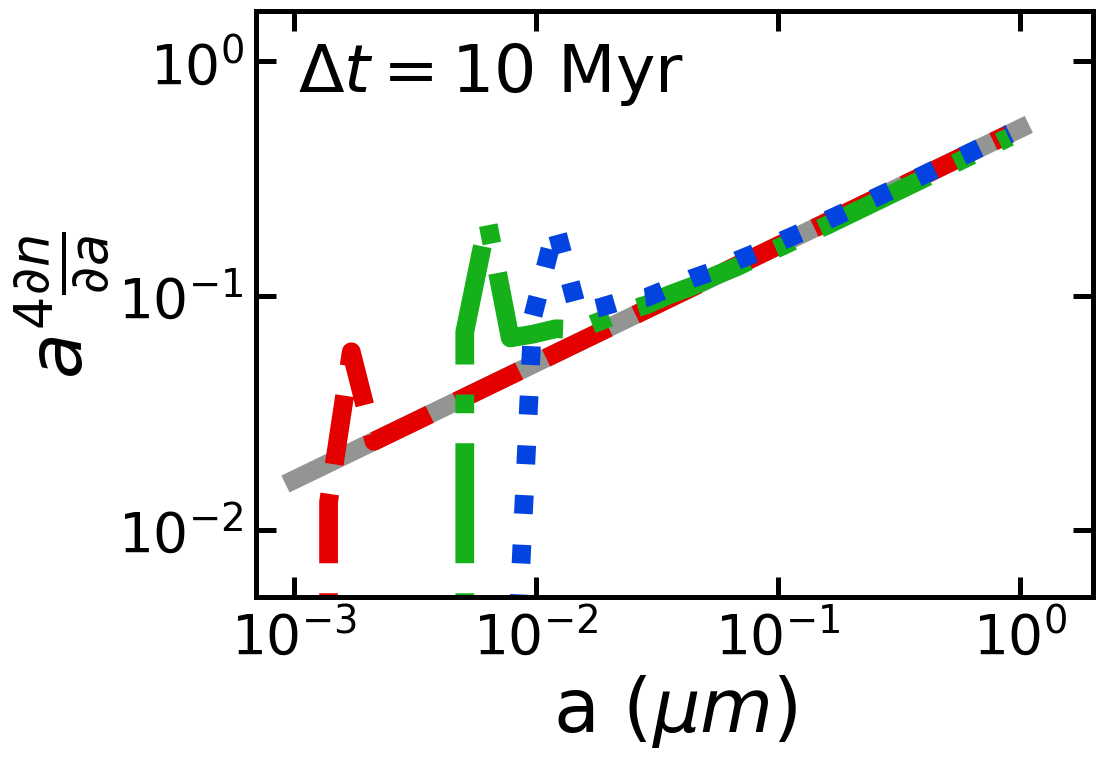

In [82]:
foutname = plot_dir+'grain_size_coagulation_diagram.pdf'

ISM_phase = 'MC'
dt = 0.01
subcycle_constraints='both'
bin_nums=32

fig = Figure(1,ncols=2)

fig.set_axis(0, 'grain_size', 'dm/da',y_lim=dmdloga_limits, rescale_font=1.5, no_minor_ticks=True)

fig.plot_line_data(0,a_vals,init_dmdloga_normed(a_vals), color='xkcd:grey',linestyle=linestyles[0], linewidth=linewidth,label="initial", zorder=-2)

for i,spec in enumerate(species):
    print(spec)
    a_bins, dnda, dmda  = gse.change_in_grain_distribution_from_shat_coag(dt, amin=amin,amax=amax,bin_num=bin_nums, init_dnda = init_dnda, ISM_phase=ISM_phase, subcycle_constraints=subcycle_constraints, species=spec, depl_frac=init_depl)

    fig.plot_line_data(0,a_bins,dmda(a_bins)*a_bins, color=colors[i],linestyle=linestyles[i+1], linewidth=linewidth,label=spec)

text = r'$\Delta t = %3.0f $ Myr'%(dt*1E3)
fig.add_text(0,0.05,0.95,text,rescale_font=1, ha='left', va='top')

#fig.set_all_legends(max_cols=2,rescale_font=0.75)
fig.save(foutname)

##### SNe Shocks

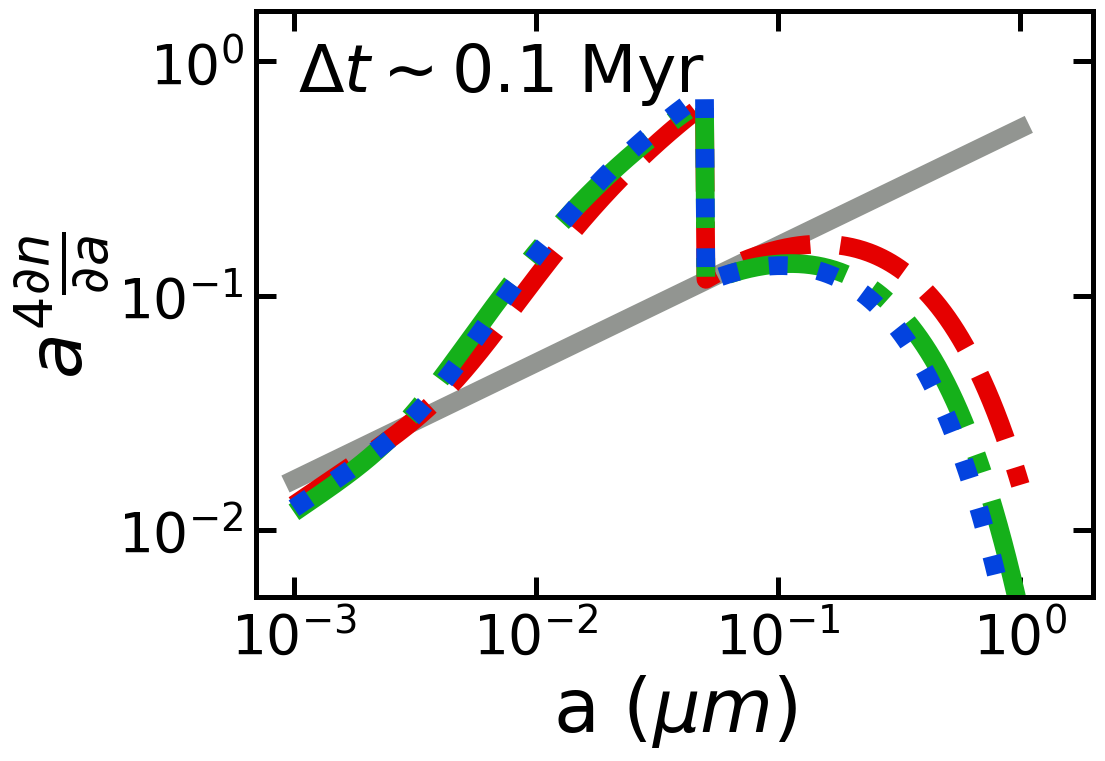

In [56]:

foutname = plot_dir+'grain_size_SNe_shock_diagram.pdf'

# Set limits for size distribution

bins=500
a_bins = np.logspace(np.log10(amin),np.log10(amax), bins)

dt = 0.0001
approx='shat_sput_shat'

fig = Figure(1,ncols=2)

fig.set_axis(0, 'grain_size', 'dm/da',y_lim=dmdloga_limits, rescale_font=1.5, no_minor_ticks=True)

fig.plot_line_data(0,a_vals,init_dmdloga_normed(a_vals), color='xkcd:grey',linestyle=linestyles[0], linewidth=linewidth,label="initial", zorder=-2)

SNe_proc = gse.SNe_Dust_Processing(init_dnda,[amin,amax], bins=bins)

for i, spec in enumerate(species):
    f_SNe,dnda_SNe,dmda_SNe = SNe_proc.get_SNe_processed_dnda(approx='shat_sput_shat', species=spec)
    # Renorm dmda to 1/total_mass/fSNe
    total_mass = quad(dmda_SNe,amin,amax)[0]
    fig.plot_line_data(0,a_bins,dmda_SNe(a_bins)*a_bins/(total_mass), color=colors[i],linestyle=linestyles[i+1], linewidth=linewidth,label=spec)

text = r'$\Delta t \sim %1.1f $ Myr'%(dt*1E3)
fig.add_text(0,0.05,0.95,text,rescale_font=1, ha='left', va='top')

#fig.set_all_legends(max_cols=2,rescale_font=0.75)
fig.save(foutname)

## Thermal Erosion Rate Comparison

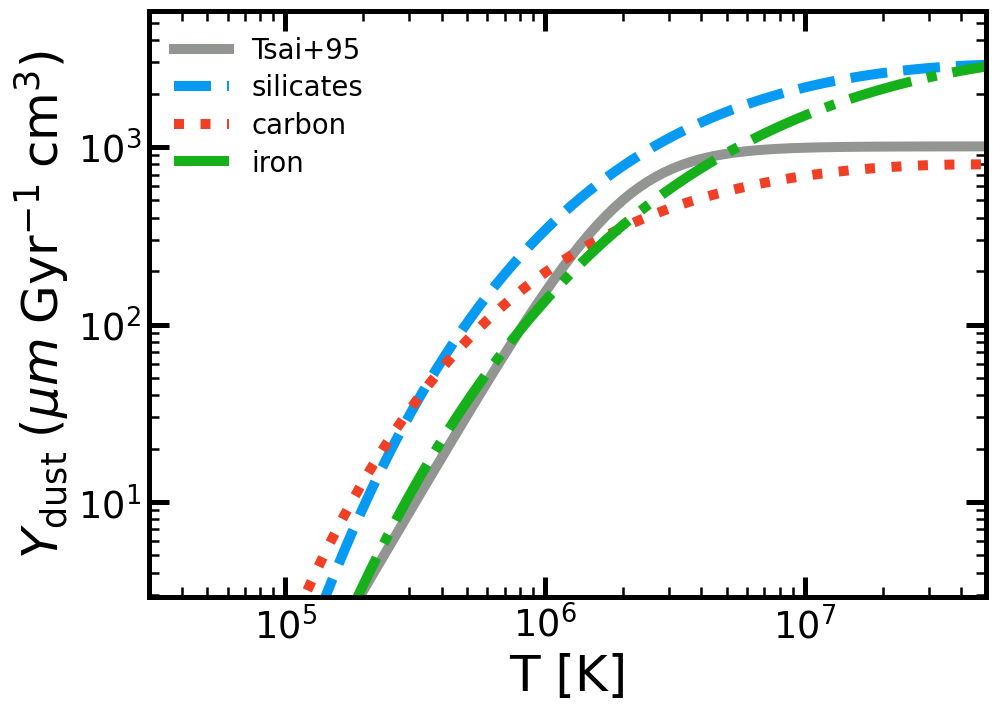

In [339]:

Tsput = 2E6; 
T_limits = [3E4,5E7]
T = np.logspace(np.log10(T_limits[0]), np.log10(T_limits[1]), 100)
Y_Tsai = 3.2E-18 / (np.power((Tsput/T),2.5) + 1) * config.cm_to_um / config.sec_to_Gyr;

x = np.log10(T)
Y_carb = np.power(10,-226.85176513236104 + 133.44188274964907*x - 32.57239140566398*np.power(x,2) + 4.005662246063896*np.power(x,3) - 0.247470977981441*np.power(x,4) + 0.0061211887939359045*np.power(x,5)) / 1E-9
Y_sil = np.power(10,-226.94973608304852 + 127.94268281713853*x - 29.91964844780188*np.power(x,2) + 3.5354022742488267*np.power(x,3) - 0.21055294512995676*np.power(x,4) + 0.0050362487746130735*np.power(x,5)) / 1E-9
Y_Fe = np.power(10,-156.87812803401695 + 82.10982096578688*x - 18.237504267725893*np.power(x,2) + 2.0691984369187524*np.power(x,3) - 0.11933080830511887*np.power(x,4) + 0.00277875641831501*np.power(x,5)) / 1E-9
N=5
colors = config.LINE_COLORS[:N]
linestyles = config.LINE_STYLES[:N]
linewidth = 2*config.BASE_LINEWIDTH

y_label = r'$Y_{\rm dust}\;(\mu m \; {\rm Gyr}^{-1} \;{\rm cm^{3}})$'
fig = Figure(1)
fig.set_axis(0, 'T', 'erosion_rate', x_lim=T_limits, x_log=True, y_label=y_label, y_lim=[np.max(Y_sil)*1E-3, 2*np.max(Y_sil)], y_log=True)

fig.plot_line_data(0, T, Y_Tsai, color='xkcd:grey', linestyle=linestyles[0], linewidth=2*config.BASE_LINEWIDTH, label='Tsai+95')
i=0
fig.plot_line_data(0, T, Y_sil, color=colors[i], linestyle=linestyles[i+1], linewidth=2*config.BASE_LINEWIDTH, label='silicates')
i=1
fig.plot_line_data(0, T, Y_carb, color=colors[i], linestyle=linestyles[i+1], linewidth=2*config.BASE_LINEWIDTH, label='carbon')
i=2
fig.plot_line_data(0, T, Y_Fe, color=colors[i], linestyle=linestyles[i+1], linewidth=2*config.BASE_LINEWIDTH, label='iron')

fig.set_all_legends(max_cols=2,rescale_font=0.75)
fig.save(plot_dir+'dust_erosion_rate.pdf')

## Sub-Resolved Gas Clumping

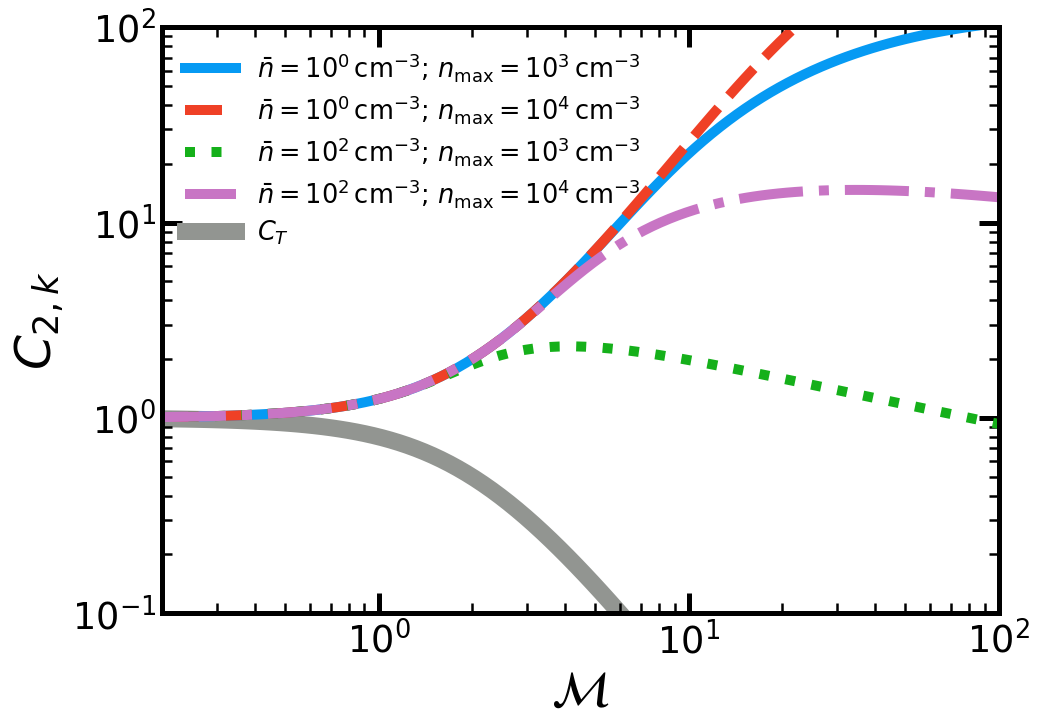

In [ ]:
from scipy.special import erfc,erf

foutname = 'clumping_factor.pdf'

M_limits = [0.2,100]
C_limits = [0.1,100]
nmaxs = [1E3,1E4,1E3,1E4]
ns=[1E0,1E0,1E2,1E2]


M = np.logspace(np.log10(M_limits[0]),np.log10(M_limits[1]),100)
b = 0.5 # ratio of solenoidal to compressive turbulence
sigma = np.sqrt(np.log(1+b*b*M*M))

N = len(nmaxs)

colors = config.LINE_COLORS[:N]
linestyles = config.LINE_STYLES[:N]
linewidth = 2*config.BASE_LINEWIDTH

x_label = r'$\mathcal{M}$'
y_label = r'$C_{2,k}$'
fig = Figure(1)
fig.set_axis(0, 'M', 'clumping_factor', x_lim=M_limits, x_log=True, x_label=x_label, y_label=y_label, y_lim=C_limits, y_log=True)



for i in range(N):
    nmax=nmaxs[i]
    n=ns[i]
    clumping_factor = np.exp(sigma*sigma)/2 * erfc((3/2*sigma*sigma-np.log(nmax/n)) / (np.sqrt(2)*sigma))
    label = r'$\bar{n}=10^{%i}\,{\rm cm^{-3}}$; $ n_{\rm max}=10^{%i}\,{\rm cm^{-3}}$'%(np.log10(n),np.log10(nmax))
    fig.plot_line_data(0,M,clumping_factor,label=label,linestyle=linestyles[i],color=colors[i], linewidth=linewidth)
    
    if i == N-1:
        T_clumping_factor = 1/(np.exp(sigma*sigma)/2 * (1 + erf((3/2*sigma*sigma + np.log(nmax/n)) / (np.sqrt(2)*sigma))))
        label = r'$C_T$'
        fig.plot_line_data(0,M,T_clumping_factor,label=label,linestyle='-',color='xkcd:grey', linewidth=1.7*linewidth,zorder=-3)

fig.set_all_legends(rescale_font=0.7,max_cols=1)

fig.save(plot_dir+foutname)

## Turbulence Driven Grain Velocity

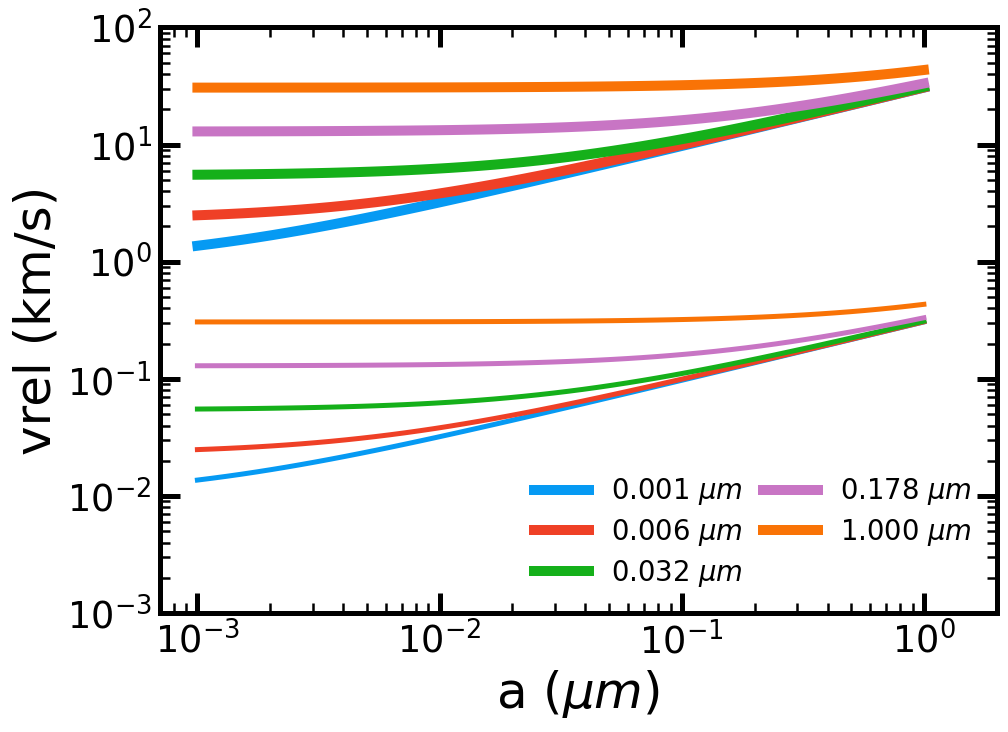

In [14]:

foutname = plot_dir+'HA19_relative_grain_velocity_WIM_MC.pdf'

N=5
amin=1E-3*config.um_to_cm; amax=1E0*config.um_to_cm
a1s = np.logspace(np.log10(amin),np.log10(amax))
a2s = np.logspace(np.log10(amin),np.log10(amax),num=N)

fig = Figure(1,ncols=2)
colors = config.LINE_COLORS[:N]
linestyles = config.LINE_STYLES[:N]
linewidth = 2*config.BASE_LINEWIDTH

fig.set_axis(0, 'grain_size', 'velocity', y_lim=[0.001,100], y_label='vrel (km/s)',y_log=True)


spec= 'silicates'

spec_props = gse.dust_species_properties(spec)
rho_c = spec_props['rho_c']


for i,a2 in enumerate(a2s):
    vrel = np.zeros(len(a1s))
    for j,a1 in enumerate(a1s):
        vrel[j] = gse.grain_relative_velocity(a1, a2, rho_c, 'WIM', scheme='HA19')*1E-5
    


    fig.plot_line_data(0,a1s*config.cm_to_um,vrel, color=colors[i], label='%1.3f '%(a2*config.cm_to_um) + r'$\mu m$', linewidth=linewidth)

for i,a2 in enumerate(a2s):
    vrel = np.zeros(len(a1s))
    for j,a1 in enumerate(a1s):
        vrel[j] = gse.grain_relative_velocity(a1, a2, rho_c,'MC', scheme='HA19')*1E-5
    


    fig.plot_line_data(0,a1s*config.cm_to_um,vrel, color=colors[i], linewidth=0.5*linewidth)

fig.set_all_legends(rescale_font=0.75)
fig.save(foutname)

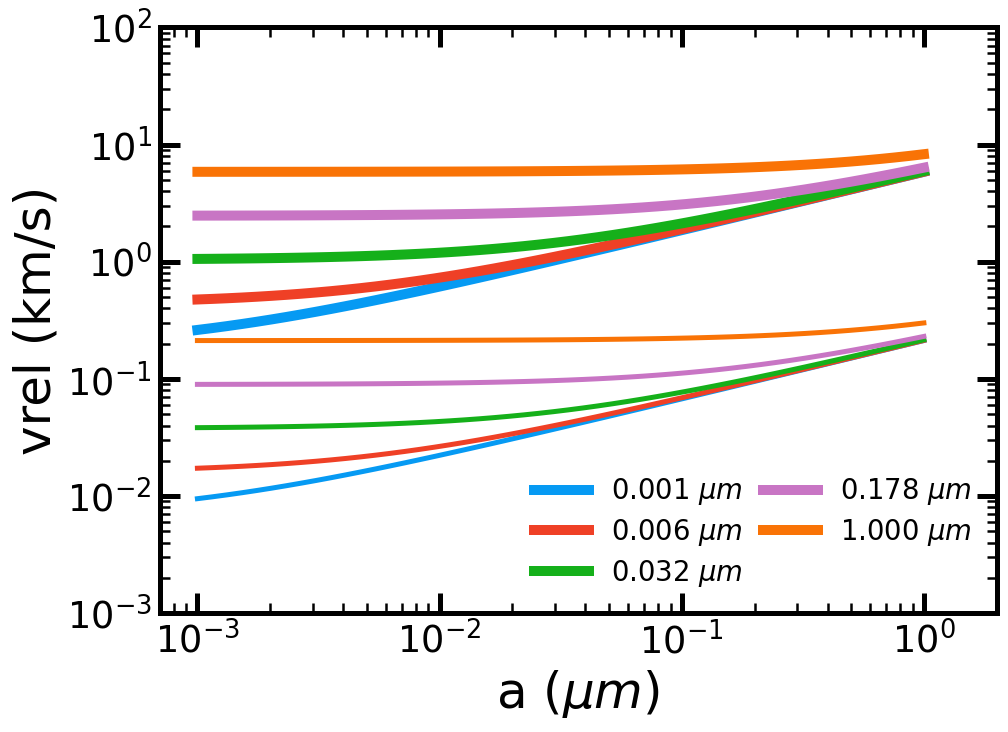

In [13]:

foutname = plot_dir+'HC23_relative_grain_velocity_WIM_MC.pdf'

N=5
amin=1E-3*config.um_to_cm; amax=1E0*config.um_to_cm
a1s = np.logspace(np.log10(amin),np.log10(amax))
a2s = np.logspace(np.log10(amin),np.log10(amax),num=N)

fig = Figure(1,ncols=2)
colors = config.LINE_COLORS[:N]
linestyles = config.LINE_STYLES[:N]
linewidth = 2*config.BASE_LINEWIDTH

fig.set_axis(0, 'grain_size', 'velocity', y_lim=[0.001,100], y_label='vrel (km/s)',y_log=True)


spec= 'silicates'

spec_props = gse.dust_species_properties(spec)
rho_c = spec_props['rho_c']


for i,a2 in enumerate(a2s):
    vrel = np.zeros(len(a1s))
    for j,a1 in enumerate(a1s):
        vrel[j] = gse.grain_relative_velocity(a1, a2, rho_c, 'WIM', scheme='HC23')*1E-5
    


    fig.plot_line_data(0,a1s*config.cm_to_um,vrel, color=colors[i], label='%1.3f '%(a2*config.cm_to_um) + r'$\mu m$', linewidth=linewidth)

for i,a2 in enumerate(a2s):
    vrel = np.zeros(len(a1s))
    for j,a1 in enumerate(a1s):
        vrel[j] = gse.grain_relative_velocity(a1, a2, rho_c,'MC', scheme='HC23')*1E-5
    


    fig.plot_line_data(0,a1s*config.cm_to_um,vrel, color=colors[i], linewidth=0.5*linewidth)

fig.set_all_legends(rescale_font=0.75)
fig.save(foutname)

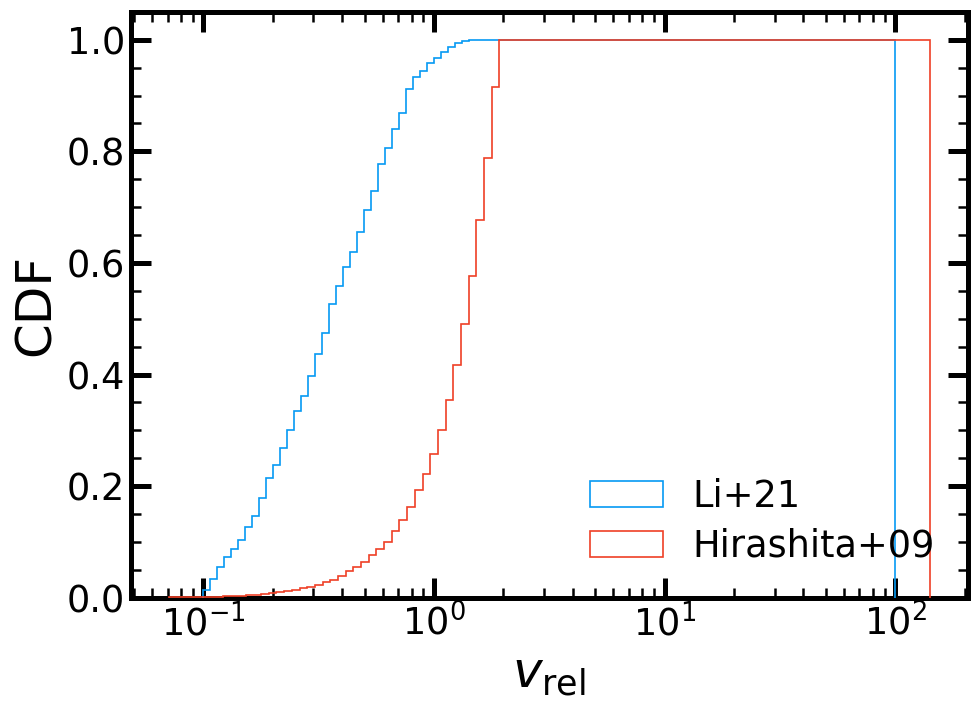

In [ ]:
v1 = 1
v2 = 1

N=10000


xlim= [0.1,100]
ylim = [0,1]

colors = config.LINE_COLORS[:2]
linestyles = config.LINE_STYLES[:2]
linewidth = 2*config.BASE_LINEWIDTH

labels = ['Li+21','Hirashita+09']

y_label = 'CDF'
x_label = r'$v_{\rm rel}$'
fig = Figure(1)
fig.set_axis(0, 'vrel', 'prob', x_lim=xlim, x_log=True, x_label=x_label, y_label=y_label, y_lim=ylim, y_log=False)

# Determine relative velocities by taking the difference of x, y, and z components
vrel = np.zeros(N)
for i in range(3):
    v1i=np.random.normal(0,v1*v1/3,1000)
    v2i=np.random.normal(0,v2*v2/3,1000)
    vrel = np.power(v1i-v2i,2)
vrel=np.sqrt(vrel)

#fig.plot_1Dhistogram(0,vrel,bin_log=True)
fig.plot_1Dhistogram(0,vrel,bin_log=True,cumulative=True,label=labels[0])


impact_angle = np.random.uniform(-1,1,N)
vrel = np.sqrt(v1*v1 + v2*v2 - 2*v1*v2*impact_angle)
fig.plot_1Dhistogram(0,vrel,bin_log=True,cumulative=True,label=labels[1])

fig.set_all_legends()



## Coagulation Velocity

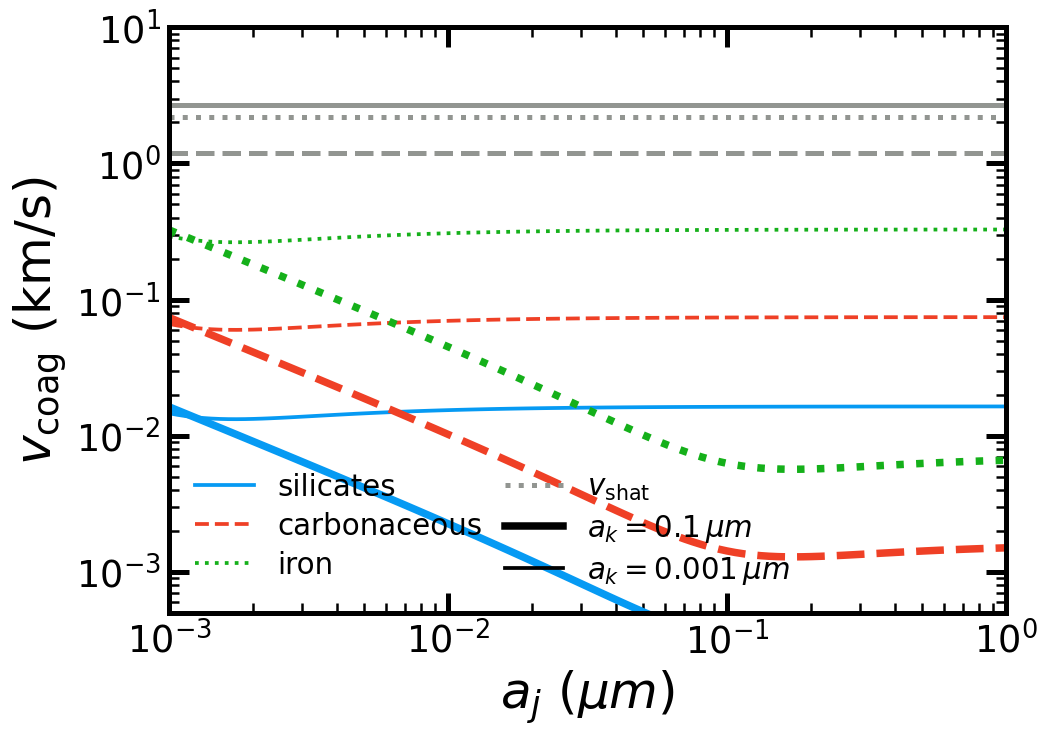

In [74]:
foutname=plot_dir+'coagulation_velocity.pdf'

alim= [0.001,1]
a_vals = np.logspace(np.log10(alim[0]),np.log10(alim[1]),100)*1E-4
ylim = [5E-4,1E1]

colors = config.LINE_COLORS[:3]
linestyles = config.LINE_STYLES[:3]
linewidth = config.LINE_WIDTHS[[0,3]]


y_label = r'$v_{\rm coag}$ (km/s)'
x_label = r'$a_j$ ($\mu m$)'

fig = Figure(1)
fig.set_axis(0, 'vcoag', 'aj', x_lim=alim, x_log=True, x_label=x_label, y_label=y_label, y_lim=ylim, y_log=True)

species = ['silicates','carbonaceous','iron']
# The grain sizes for the target grain
aks = np.array([0.1,0.001])*1E-4 # cm

for i in range(len(species)):
    
    # Get species properties
    spec_props = gse.dust_species_properties(species[i])
    dust_atomic_weight = spec_props['dust_atomic_weight']
    key_mass = spec_props['key_mass']
    key_abundance = spec_props['key_abundance']
    key_num_atoms = spec_props['key_num_atoms'] 
    P1 = spec_props['P1']
    v_shat = spec_props['v_shat']/1E5 # km/s
    poisson = spec_props['poisson']
    youngs = spec_props['youngs']
    gamma = spec_props['gamma']
    rho_c = spec_props['rho_c']

    for j, ak in enumerate(aks):
        v_coag = gse.v_coagulation(ak,a_vals,rho_c, poisson, youngs, gamma)/1E5 # km/s

        fig.plot_line_data(0,a_vals/1E-4,v_coag,label=species[i],linestyle=linestyles[i],color=colors[i], linewidth=linewidth[j])

        if j==0:
            if i == len(species)-1: vshat_label=r'$v_{\rm shat}$'
            else: vshat_label=None
            vshat_line = mlines.Line2D(alim,[v_shat,v_shat], c='xkcd:grey',label=vshat_label,linewidth=config.BASE_LINEWIDTH,linestyle=linestyles[i],zorder=-3)
            fig.add_artist(0,vshat_line)
        
        if i == len(species)-1:
            new_label=r'$a_k=%g \, \mu m$'%(ak*1E4)
            fig.plot_line_data(0,[config.EPSILON],[config.EPSILON],label=new_label,linestyle='-',color='xkcd:black', linewidth=linewidth[j])



fig.set_all_legends(rescale_font=1/1.25,ncols=2,loc='lower left')

fig.save(foutname)

# Analytical Testing

## SNe Dust Destruction

### Sputtering and shattering efficiency functions

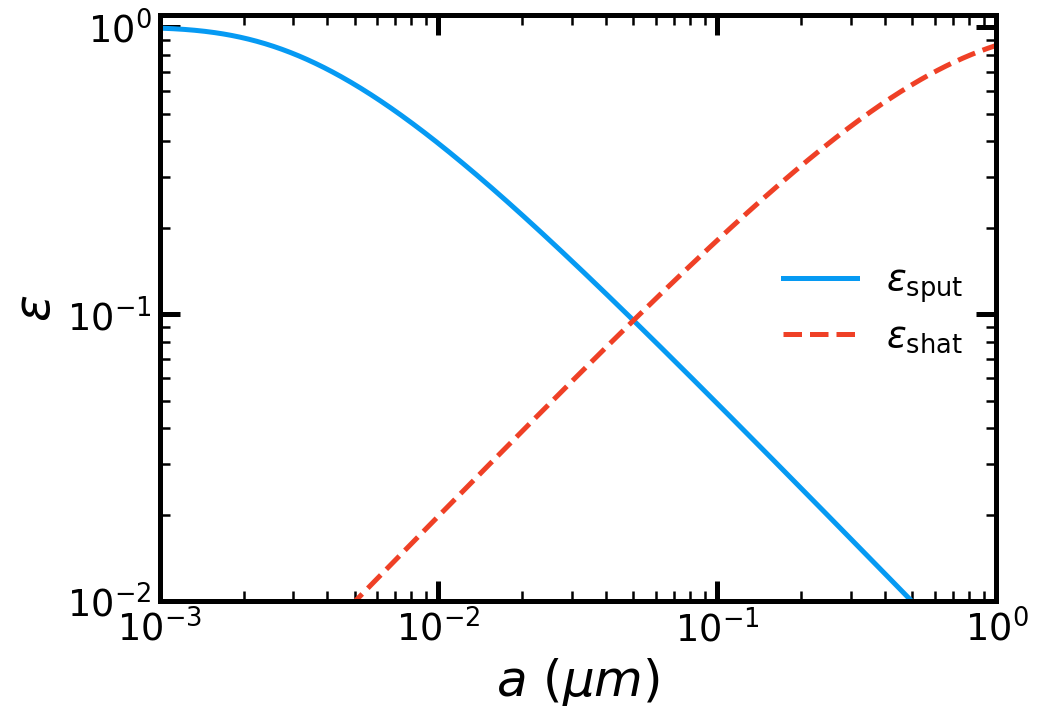

In [297]:
N = 5

colors = config.LINE_COLORS[:N]
linestyles = config.LINE_STYLES[:N]
linewidth = 2*config.BASE_LINEWIDTH


a_sput = 0.05; # microns
a_shat = 0.05;
delta_sput = 0.1;
delta_shat = 0.1;
a_limit = [1E-3,1E0]
a = np.logspace(np.log10(a_limit[0]),np.log10(a_limit[1]),500)


y_label = r'$ \epsilon $'
x_label = r'$a$ ($\mu m$)'
eff_limits = [1E-2,1.1]
fig = Figure(1)
fig.set_axis(0, 'a', 'eff', x_lim=a_limit, x_log=True, x_label=x_label, y_label=y_label, y_lim=eff_limits, y_log=True)


def eff_sput(a):
        return (1 - np.exp(-(delta_sput / (a/a_sput))))
def eff_shat(a):
        return (1 - np.exp(-(delta_shat * (a/a_shat))))

i=0
fig.plot_line_data(0,a,eff_sput(a),label=r'$\epsilon_{\rm sput}$',color=colors[i], linestyle=linestyles[i])
i=1
fig.plot_line_data(0,a,eff_shat(a),label=r'$\epsilon_{\rm shat}$',color=colors[i], linestyle=linestyles[i])
fig.set_all_legends()

### Total dust destruction fraction
This tests the shattering+sputtering and shattering+sputting+shattering routines for varying sputtering and shattering efficiencies

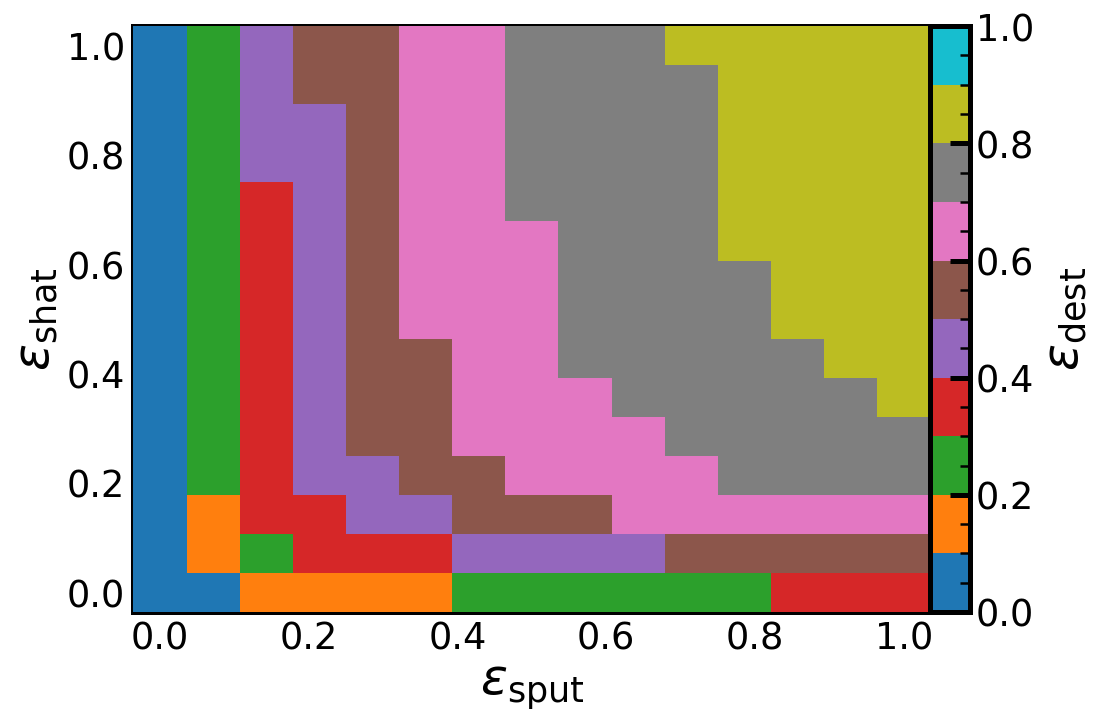

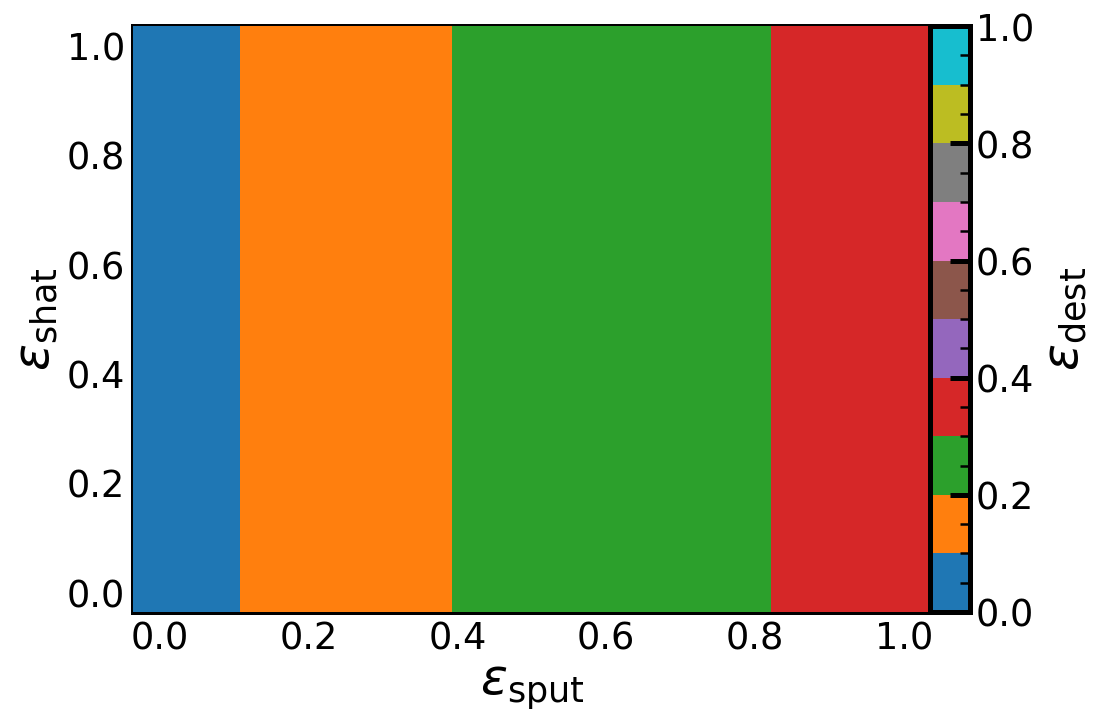

In [342]:
# Set limits for size distribution
amin = 1E-3
amax=1E0
bins=500
a_bins = np.logspace(np.log10(amin),np.log10(amax), bins)

a_sput = 0.05; # microns
a_shat = 0.05;
a_frag_max = a_shat

init_dnda=gse.MRN_dnda

N=15
eff_shats = np.linspace(0,1,N)
eff_sputs = eff_shats
f_dest = np.zeros((N,N))

color_N = 5
colors = config.LINE_COLORS[:color_N]
linestyles = config.LINE_STYLES[:color_N]
linewidths = config.LINE_WIDTHS[[0,color_N]]

fig = Figure(1)
x_label = r'$\epsilon_{\rm sput}$'
y_label = r'$\epsilon_{\rm shat}$'
fig.set_axis(0, 'sput', 'shat', x_lim=[0,1], x_log=False, x_label=x_label, y_label=y_label, y_lim=[0,1], y_log=False)



color_N = 5
colors = config.LINE_COLORS[:color_N]
linestyles = config.LINE_STYLES[:color_N]
linewidths = config.LINE_WIDTHS[[0,color_N]]

approx='shat_sput_shat'

SNe_proc = gse.SNe_Dust_Processing(init_dnda,[amin,amax], bins=bins)

for i,eff_sh in enumerate(eff_shats):
    for j,eff_sp in enumerate(eff_sputs):
        f_dest[i,j],_,_= SNe_proc.get_SNe_processed_dnda(approx=approx, delta_sput = eff_sp, delta_shat = eff_sh, a_sput=a_sput, a_shat=a_shat, a_frag_max=a_frag_max)

fig.plot_2Dhistogram(0, 'M_survival', eff_sputs, eff_shats, f_dest, cmap='tab10', z_lim=[0,1], z_log=False,rescale_font=1)
fig.add_colorbar(0, cbar_label=r'$\epsilon_{\rm dest}$', invert_axis=False, no_minor_ticks=False, side='right', rescale_font=1,)

fig = Figure(1)
x_label = r'$\epsilon_{\rm sput}$'
y_label = r'$\epsilon_{\rm shat}$'
fig.set_axis(0, 'sput', 'shat', x_lim=[0,1], x_log=False, x_label=x_label, y_label=y_label, y_lim=[0,1], y_log=False)

approx='sput'

for i,eff_sh in enumerate(eff_shats):
    for j,eff_sp in enumerate(eff_sputs):
        f_dest[i,j],_,_= SNe_proc.get_SNe_processed_dnda(approx=approx, delta_sput = eff_sp,a_sput=a_sput)

fig.plot_2Dhistogram(0, 'M_survival', eff_sputs, eff_shats, f_dest, cmap='tab10', z_lim=[0,1], z_log=False,rescale_font=1)
fig.add_colorbar(0, cbar_label=r'$\epsilon_{\rm dest}$', invert_axis=False, no_minor_ticks=False, side='right', rescale_font=1,)


### Comparing SNe grain size destruction models

Initial MRN
Sh+Sp+Sh Dest Frac 1: 0.5525349749905237
Sh+Sp+Sh Dest Frac 2: 0.42997707848797695
Sp Only Dest Frac: 0.583818220234015
Nozawa+06 Dest Frac: 0.5757067902072475


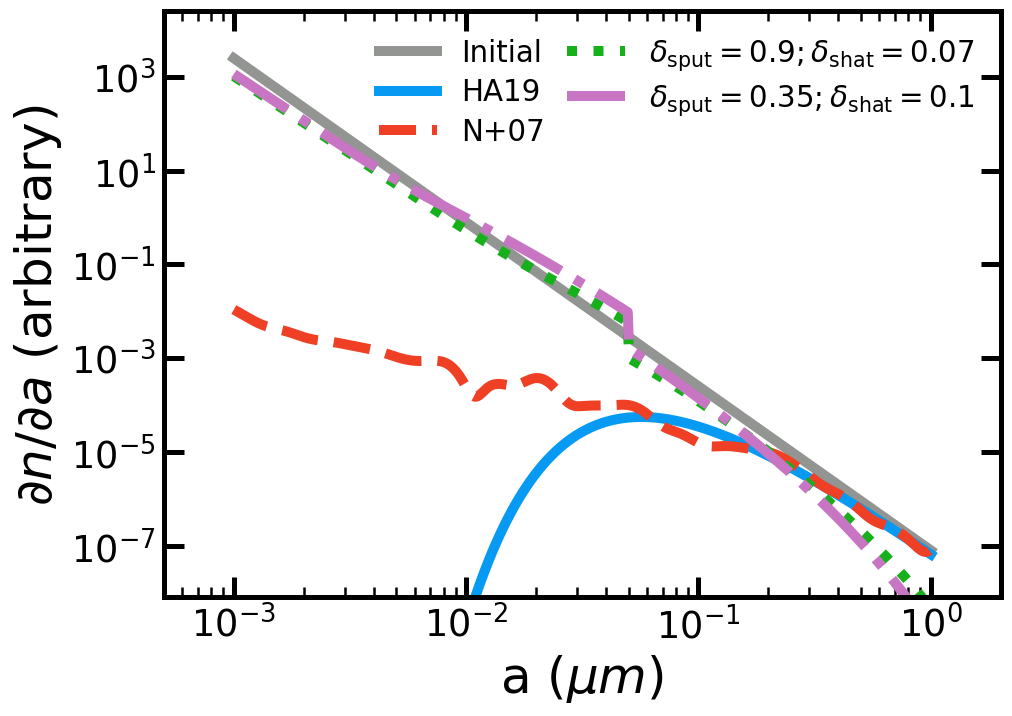

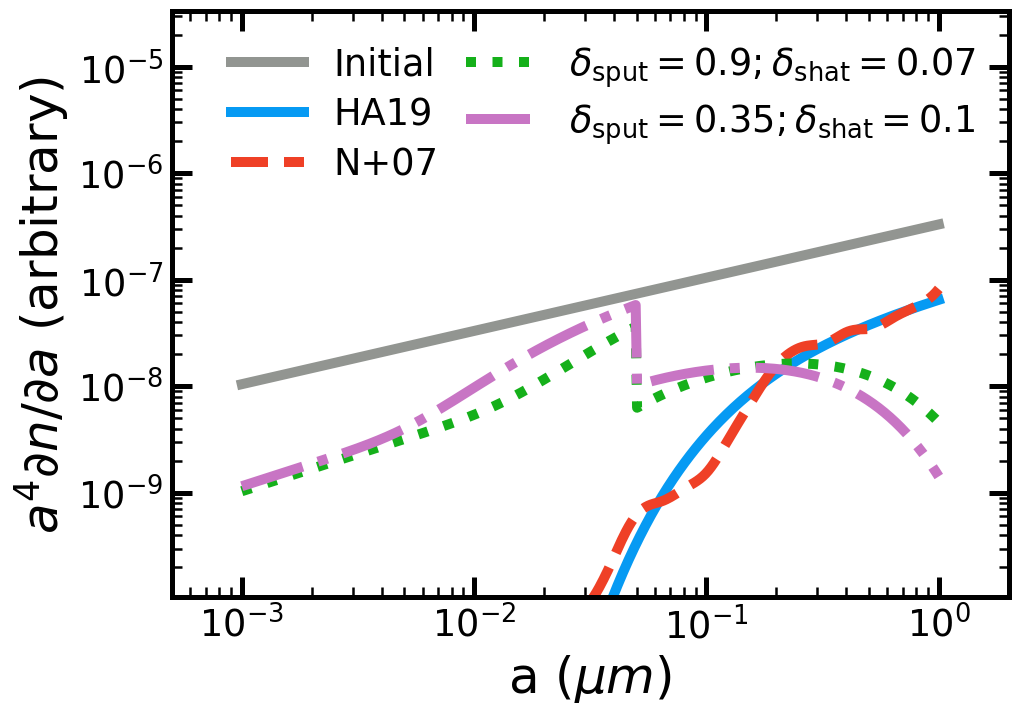

In [6]:

color_N = 5
colors = config.LINE_COLORS[:color_N]
linestyles = config.LINE_STYLES[:color_N]
linewidth = 2*config.BASE_LINEWIDTH

# Set limits for size distribution
amin=1E-3
amax=1E0
a_limit = [amin,amax]
bins=500
a_bins = np.logspace(np.log10(a_limit[0]),np.log10(a_limit[1]),bins)



init_dnda=gse.MRN_dnda
init_dmda=gse.MRN_dmda
norm = 1/quad(init_dnda,amin,amax)[0]
normed_init_dnda = lambda a: init_dnda(a)*norm
normed_init_dmda = lambda a: init_dmda(a)*norm

SNe_proc = gse.SNe_Dust_Processing(init_dnda,[amin,amax], bins=bins)

a_sput = 0.05; # microns
a_shat = 0.05;
delta_sput = 0.9;
delta_shat = 0.07;
a_frag_max = a_shat

f_shspsh1,dnda_shspsh1,dmda_shspsh1 = SNe_proc.get_SNe_processed_dnda(approx='shat_sput_shat', delta_sput = delta_sput, delta_shat = delta_shat, a_sput=a_sput, a_shat=a_shat, a_frag_max=a_frag_max)
label1 = r'$\delta_{\rm sput}=%0.1f ; \delta_{\rm shat}=%0.2f$'%(delta_sput,delta_shat)

delta_sput = 0.35;
delta_shat = 0.1;


f_shspsh2,dnda_shspsh2,dmda_shspsh2 = SNe_proc.get_SNe_processed_dnda(approx='shat_sput_shat', delta_sput = delta_sput, delta_shat = delta_shat, a_sput=a_sput, a_shat=a_shat, a_frag_max=a_frag_max)
label2 = r'$\delta_{\rm sput}=%0.2f ; \delta_{\rm shat}=%0.1f$'%(delta_sput,delta_shat)

f_sp,dnda_sp,dmda_sp=SNe_proc.get_SNe_processed_dnda(approx='sput', delta_sput = 0.99, a_sput=0.2)

f_noz,dnda_noz, dmda_noz = SNe_proc.get_SNe_processed_dnda(approx='nozawa')


print("Initial MRN")
print("Sh+Sp+Sh Dest Frac 1:",f_shspsh1)
print("Sh+Sp+Sh Dest Frac 2:",f_shspsh2)
print("Sp Only Dest Frac:",f_sp)
print("Nozawa+06 Dest Frac:",f_noz)

y_limit = [np.min(normed_init_dnda(a_bins))*1E-1,np.max(normed_init_dnda(a_bins))*1E1]
x_limit=[a_limit[0]*0.5,a_limit[1]*2]
x_label = r'a ($\mu m$)'
y_label = r'$\partial n/\partial a$ (arbitrary)'
fig = Figure(1)
fig.set_axis(0, 'a', 'number_survival_frac', x_lim=x_limit, x_log=True, x_label=x_label, y_label=y_label, y_lim=y_limit, y_log=True)

fig.plot_line_data(0,a_bins,normed_init_dnda(a_bins),label='Initial',color='xkcd:grey', linestyle=linestyles[0], linewidth=2*config.BASE_LINEWIDTH)
i=0
fig.plot_line_data(0,a_bins,dnda_sp(a_bins),label='HA19',color=colors[i], linestyle=linestyles[i],linewidth=linewidth)
i+=1
fig.plot_line_data(0,a_bins,dnda_noz(a_bins),label='N+07',color=colors[i], linestyle=linestyles[i],linewidth=linewidth)
i+=1
fig.plot_line_data(0,a_bins,dnda_shspsh1(a_bins),label=label1,color=colors[i], linestyle=linestyles[i],linewidth=linewidth)
i+=1
fig.plot_line_data(0,a_bins,dnda_shspsh2(a_bins),label=label2,color=colors[i], linestyle=linestyles[i],linewidth=linewidth)
fig.set_all_legends(rescale_font=0.8)
fig.save(plot_dir+'MRN_dnda_SNe_comparison.pdf')

y_limit = [np.min(normed_init_dmda(a_bins)*a_bins)*1E-2,np.max(normed_init_dmda(a_bins)*a_bins)*1E2]
x_limit=[a_limit[0]*0.5,a_limit[1]*2]
y_label = r'$a^4 \partial n/\partial a$ (arbitrary)'
fig = Figure(1)
fig.set_axis(0, 'a', 'number_survival_frac', x_lim=x_limit, x_log=True, x_label=x_label, y_label=y_label, y_lim=y_limit, y_log=True)


fig.plot_line_data(0,a_bins,normed_init_dmda(a_bins)*a_bins,label='Initial',color='xkcd:grey', linestyle=linestyles[0], linewidth=2*config.BASE_LINEWIDTH)
i=0
fig.plot_line_data(0,a_bins,dmda_sp(a_bins)*a_bins,label='HA19',color=colors[i], linestyle=linestyles[i],linewidth=linewidth)
i+=1
fig.plot_line_data(0,a_bins,dmda_noz(a_bins)*a_bins,label='N+07',color=colors[i], linestyle=linestyles[i],linewidth=linewidth)
i+=1
fig.plot_line_data(0,a_bins,dmda_shspsh1(a_bins)*a_bins,label=label1,color=colors[i], linestyle=linestyles[i],linewidth=linewidth)
i+=1
fig.plot_line_data(0,a_bins,dmda_shspsh2(a_bins)*a_bins,label=label2,color=colors[i], linestyle=linestyles[i],linewidth=linewidth)
fig.set_all_legends()
fig.save(plot_dir+'MRN_dmda_SNe_comparison.pdf')

silicates dest frac: 0.400703
carbonaceous dest frac: 0.354476
iron dest frac: 0.407336


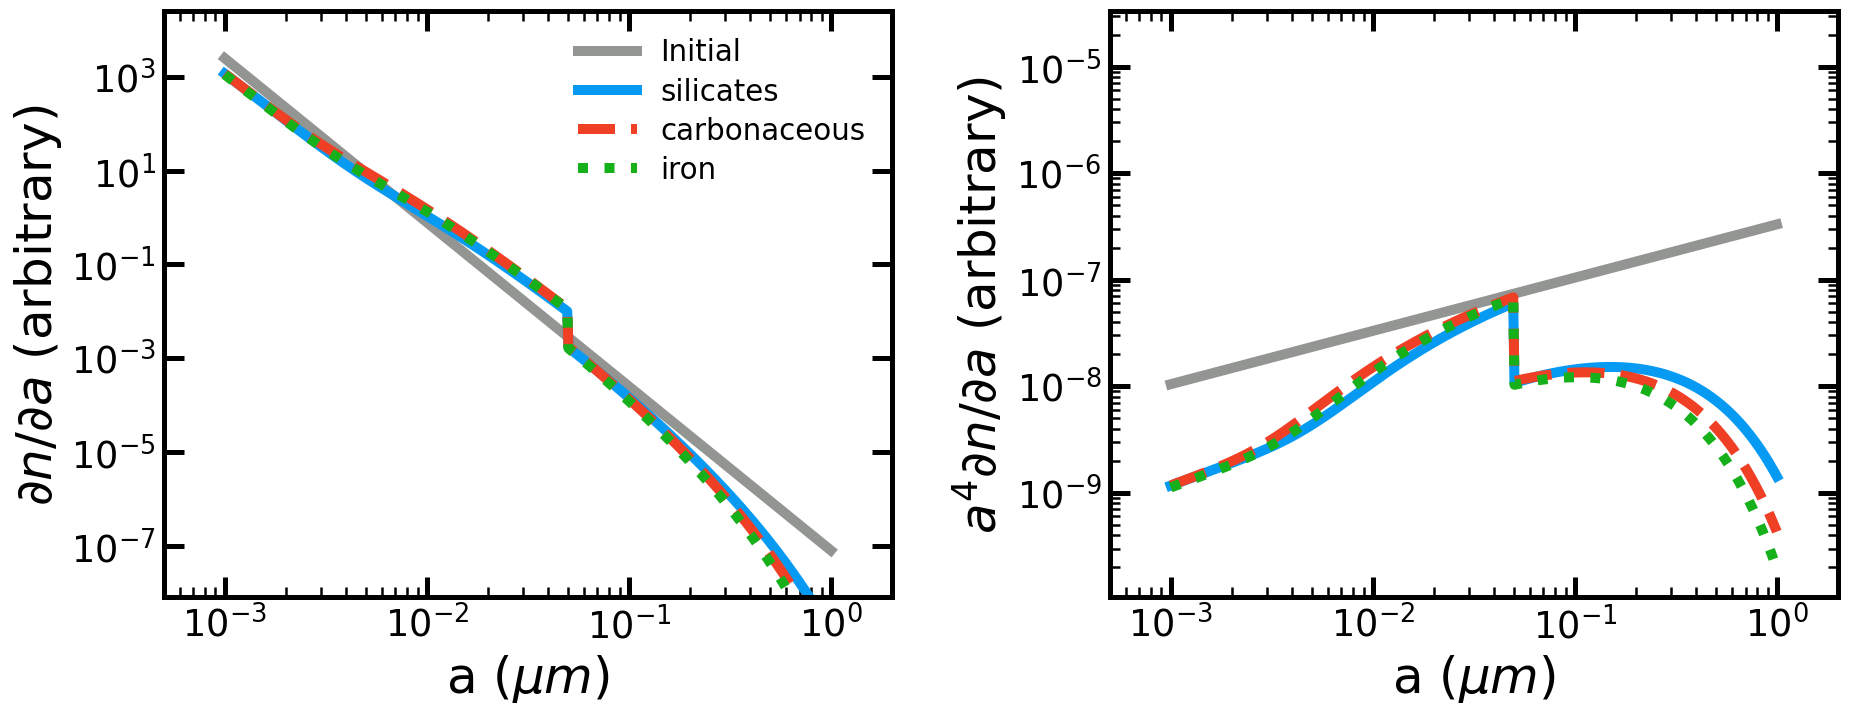

In [8]:

color_N = 5
colors = config.LINE_COLORS[:color_N]
linestyles = config.LINE_STYLES[:color_N]
linewidth = 2*config.BASE_LINEWIDTH

# Set limits for size distribution
amin=1E-3
amax=1E0
a_limit = [amin,amax]
bins=500
a_bins = np.logspace(np.log10(a_limit[0]),np.log10(a_limit[1]),bins)



init_dnda=gse.MRN_dnda
init_dmda=gse.MRN_dmda
norm = 1/quad(init_dnda,amin,amax)[0]
normed_init_dnda = lambda a: init_dnda(a)*norm
normed_init_dmda = lambda a: init_dmda(a)*norm



y_limit = [np.min(normed_init_dnda(a_bins))*1E-1,np.max(normed_init_dnda(a_bins))*1E1]
x_limit=[a_limit[0]*0.5,a_limit[1]*2]
x_label = r'a ($\mu m$)'
y_label = r'$\partial n/\partial a$ (arbitrary)'
fig = Figure(2)
fig.set_axis(0, 'a', 'number_survival_frac', x_lim=x_limit, x_log=True, x_label=x_label, y_label=y_label, y_lim=y_limit, y_log=True)

y_limit = [np.min(normed_init_dmda(a_bins)*a_bins)*1E-2,np.max(normed_init_dmda(a_bins)*a_bins)*1E2]
y_label = r'$a^4 \partial n/\partial a$ (arbitrary)'
fig.set_axis(1, 'a', 'number_survival_frac', x_lim=x_limit, x_log=True, x_label=x_label, y_label=y_label, y_lim=y_limit, y_log=True)

fig.plot_line_data(0,a_bins,normed_init_dnda(a_bins),label='Initial',color='xkcd:grey', linestyle=linestyles[0], linewidth=2*config.BASE_LINEWIDTH)
fig.plot_line_data(1,a_bins,normed_init_dmda(a_bins)*a_bins,label='Initial',color='xkcd:grey', linestyle=linestyles[0], linewidth=2*config.BASE_LINEWIDTH)

SNe_proc = gse.SNe_Dust_Processing(init_dnda,[amin,amax], bins=bins)

species=['silicates','carbonaceous','iron']
for i,spec in enumerate(species):
    f_shspsh,dnda_shspsh,dmda_shspsh = SNe_proc.get_SNe_processed_dnda(approx='shat_sput_shat',species=spec)

    print("%s dest frac: %f"%(spec,f_shspsh))

    fig.plot_line_data(0,a_bins,dnda_shspsh(a_bins),label=spec,color=colors[i], linestyle=linestyles[i],linewidth=linewidth)
    fig.plot_line_data(1,a_bins,dmda_shspsh(a_bins)*a_bins,label=spec,color=colors[i], linestyle=linestyles[i],linewidth=linewidth)

fig.set_all_legends(rescale_font=0.8)
fig.save(plot_dir+'SNe_dest_species_comparison.pdf')
